In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


#### Load Data
- Each function dataset has input dimensions (x1, x2, ..., x8) and output 'y'. (10 Data Points)



In [2]:
import os

try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# Dictionary to store all function datasets
functions_data = {}

for i in range(1, 9):

    # Build file paths
    function_folder = os.path.join(base_dir, f"function_{i}")
    inputs_path = os.path.join(function_folder, "initial_inputs.npy")
    outputs_path = os.path.join(function_folder, "initial_outputs.npy")

    # Load .npy arrays
    inputs = np.load(inputs_path)
    outputs = np.load(outputs_path)


    # Reshape to 2D if needed
    if inputs.ndim == 1:
        inputs = inputs.reshape(-1, 1)
    if outputs.ndim == 1:
        outputs = outputs.reshape(-1, 1)

    # Create column names (temporary)
    input_cols = [f"input_{j}" for j in range(inputs.shape[1])]
    output_cols = [f"output_{j}" for j in range(outputs.shape[1])]
    
    # Concatenate inputs + outputs
    combined = np.concatenate([inputs, outputs], axis=1)
    df_combined = pd.DataFrame(combined, columns=input_cols + output_cols)


    # Rename columns in-place
    new_input_names = {col: f"X{j+1}" for j, col in enumerate(input_cols)}
    new_output_names = {col: f"y{j+1}" for j, col in enumerate(output_cols)}
    df_combined.rename(columns={**new_input_names, **new_output_names}, inplace=True)


    # Store in dictionary
    functions_data[f"f{i}"] = df_combined

    print(f"Loaded function {i}: shape = {df_combined.shape}, columns = {df_combined.columns.tolist()}")


Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 1: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 2: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 3: shape = (15, 4), columns = ['X1', 'X2', 'X3', 'y1']
Loaded function 4: shape = (30, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 5: shape = (20, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 6: shape = (20, 6), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'y1']
Loaded function 7: shape = (30, 7), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'y1']
Loaded function 8: shape = (40, 9), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'y1']


In [3]:
# Manually define Week 1 submission results
week1_results = {
    "f1": ([0.793600, 0.666269], 1.4034986520274933e-21),
    "f2": ([0.554975, 0.999446], -0.07640833812988071),
    "f3": ([0.389233, 0.386084, 0.558916], -0.04116779016532328),
    "f4": ([0.439369, 0.276427, 0.360198, 0.470119], -1.8014266350928305),
    "f5": ([0.037069, 0.974641, 0.864911, 0.019169], 684.5607486761136),
    "f6": ([0.363643, 0.001300, 0.920810, 0.821416, 0.136085], -0.6872415681590064),
    "f7": ([0.799542, 0.949047, 0.887638, 0.265662, 0.631518, 0.349925], 0.026543407526137847),
    "f8": ([0.311992, 0.966526, 0.355002, 0.358409, 0.551500, 0.690176, 0.717450, 0.542367], 8.4452078666581),
}

In [4]:
week2_results = {
    "f1": ([0.800601, 0.002800], 9.069108791316283e-223),
    "f2": ([0.999500, 0.001800], -0.07975546223482953),
    "f3": ([0.967200, 0.029200, 0.723300], -0.20496612752890705),
    "f4": ([0.542100, 0.336200, 0.419500, 0.404000], -2.041748838194795),
    "f5": ([0.624000, 0.735500, 0.976700, 0.994100], 2434.328593289806),
    "f6": ([0.666300, 0.229100, 0.516000, 0.821600, 0.201500], -0.5648568336407203),
    "f7": ([0.008500, 0.278800, 0.231600, 0.099300, 0.323000, 0.980800], 0.7653612109103147),
    "f8": ([0.293300, 0.174300, 0.080500, 0.056000, 0.429100, 0.492300, 0.221400, 0.410200], 9.835131961),
}

In [5]:
week3_results = {
    "f1": ([0.729726, 0.729276], 5.31459276351908e-15),
    "f2": ([0.727681, 0.187140], 0.5037032225936308),
    "f3": ([0.437962, 0.715305, 0.000876], -0.1117676821078815),
    "f4": ([0.402906, 0.437778, 0.329101, 0.424377], 0.07045398603133579),
    "f5": ([0.898795, 0.963833, 1.000000, 0.791851], 4171.124196806389),
    "f6": ([0.416408, 0.263572, 0.345102, 1.000000, 0.000000], -0.7670334120297669),
    "f7": ([0.000000, 0.189754, 0.123991, 0.253411, 0.406355, 0.251864], 0.4981320924641522),
    "f8": ([0.190768, 0.209525, 0.202591, 0.198246, 0.813824, 0.387519, 0.200772, 0.663670], 9.948688972661),
}

In [6]:
week4_results = {
    "f1": ([0.732162, 0.364472], 5.473776123300507e-57),
    "f2": ([0.715483, 0.563901], 0.5661662506769448),
    "f3": ([0.387933, 0.405240, 0.580181], -0.041279121306865105),
    "f4": ([0.351926, 0.442039, 0.451511, 0.443953], -0.27637133038944084),
    "f5": ([0.072013, 0.315203, 0.125702, 0.883341], 15.250051561683966),
    "f6": (	[0.494472, 0.050000, 0.451934, 0.152883, 0.386469], -1.421729209627387),
    "f7": ([0.097366, 0.334928, 0.369818, 0.382418, 0.464971, 0.750762], 1.5985145628892428),
}

In [7]:
week5_results = {
    "f1": ([0.812650, 0.143347], -1.0629331180647184e-161),
    "f2": ([0.678746, 0.850809], 0.6824523528240423),
    "f3": ([0.688252, 0.924125, 0.842251], -0.05314656740717209),
    "f4": ([0.342113, 0.430851, 0.327587, 0.458906], -0.49820890718197175),
    "f5": ([0.260034, 0.558879, 0.984293, 0.063132], 225.88673947929044),
    "f6": ([0.666300, 0.229100, 0.516000, 0.789473, 0.315789], -0.7791148650103992),
    "f7": ([0.053955, 0.757891, 0.608290, 0.473788, 0.364363, 0.971498], 0.32752252967109274),
    "f8": ([0.325520, 0.209525, 0.057274, 0.198246, 0.813824, 0.387519, 0.169663, 0.663670], 9.861549762954),
}

In [8]:
week6_results = {
    "f1": ([0.079265, 0.909848], 2.6078826238924974e-248),
    "f2": ([0.653993, 0.981188], 0.3798198130144502),
    "f3": ([0.788392, 0.913423, 0.403090], -0.03637482131814577),
    "f4": ([0.378009, 0.410452, 0.389136, 0.370426], 0.34655132659709453),
    "f5": ([0.000000, 0.856410, 1.000000, 0.433460], 849.8436606636637),
    "f6": ([0.537637, 0.403865, 0.951610, 0.943059, 0.050967], -0.6814591029200937),
    "f7": ([0.069772, 0.319669, 0.577421, 0.210909, 0.386068, 0.707262], 2.448290856114691),
    "f8": ([0.924338, 0.001471, 0.948665, 0.928797, 0.142329, 0.071686, 0.034416, 0.347751], 5.5407934131584),
}

In [9]:
week7_results = {
    "f1": ([0.525569, 0.987823], 2.2360328065267756e-98),
    "f2": ([0.000128, 0.346419], 0.005940965665866974),
    "f3": ([0.110343, 0.915465, 0.655916], -0.12413097550625916),
    "f4": ([0.402435, 0.485938, 0.405691, 0.380615], -1.5762466920468117),
    "f5": ([0.998891, 0.926298, 0.985415, 0.964459], 6575.295982756673),
    "f6": ([0.212341, 0.007631, 0.955851, 0.999487, 0.763435], -1.8381389462062772),
    "f7": ([0.064462, 0.412641, 0.669514, 0.193009, 0.502173, 0.667338], 1.3516399930526517),
    "f8": ([0.088856, 0.892449, 0.024530, 0.962260, 0.982699, 0.389537, 0.966989, 0.307254], 7.5413772236639005),
}

In [10]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
}

for week, results in weekly_results.items():
    for func, (inputs, output) in results.items():
        # Convert inputs and outputs to DataFrame
        inputs = np.array(inputs).reshape(1, -1)
        output = np.array([output]).reshape(1, -1)
        
        # Dynamically generate input column names
        df_inputs = pd.DataFrame(inputs, columns=[f"X{i+1}" for i in range(inputs.shape[1])])
        # Use existing output column names from the function
        output_cols = [col for col in functions_data[func].columns if col.startswith("y")]
        df_outputs = pd.DataFrame(output, columns=output_cols)
        
        # Combine
        df_week = pd.concat([df_inputs, df_outputs], axis=1)
        
        # Append only rows that are not already in the DataFrame
        functions_data[func] = pd.concat([functions_data[func], df_week], ignore_index=True)
        functions_data[func] = functions_data[func].drop_duplicates(ignore_index=True)

# Optional: check updated shapes
for func, df in functions_data.items():
    print(f"{func} updated shape: {df.shape}")


f1 updated shape: (17, 3)
f2 updated shape: (17, 3)
f3 updated shape: (22, 4)
f4 updated shape: (37, 5)
f5 updated shape: (27, 5)
f6 updated shape: (27, 6)
f7 updated shape: (37, 7)
f8 updated shape: (46, 9)


In [11]:
for name, df in functions_data.items():
    print(df)

          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15
13  0.732162  0.364472   5.473776e-57
14  0.812650  0.143347 -1.062933e-161
15  0.079265  0.909848  2.607883e-248
16  0.525569  0.987823   2.236033e-98
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213

In [12]:
for name, df in functions_data.items():
    print(f"\n{name} Summary Statistics")
    
    # Display numeric summary statistics
    display(df.describe().T)  # Transposed for easier reading (features as rows)





f1 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,17.0,0.585985,0.257546,0.079265,4.104371e-01,6.834182e-01,7.936000e-01,8.838898e-01
X2,17.0,0.541119,0.321558,0.002800,2.647316e-01,6.662690e-01,7.629594e-01,9.878230e-01
y1,17.0,-0.000212,0.000875,-0.003606,2.607883e-248,3.606771e-81,1.033078e-46,5.314593e-15



f2 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,17.0,0.571508,0.261074,0.000128,0.438166,0.653993,0.715483,0.999500
X2,17.0,0.518235,0.344295,0.001800,0.213867,0.563901,0.778628,0.999446
y1,17.0,0.252274,0.268628,-0.079755,0.005941,0.244619,0.503703,0.682452



f3 Summary Statistics


...

,count,mean,std,min,25%,50%,75%,max
X1,27.0,0.530089,0.272511,0.021735,0.311274,0.537637,0.743558,0.957740
X2,27.0,0.460591,0.308236,0.001300,0.232384,0.355831,0.770892,0.931871
X3,27.0,0.518579,0.311114,0.016523,0.343461,0.516000,0.771980,0.978806
X4,27.0,0.600614,0.300612,0.045613,0.372389,0.680515,0.821508,1.000000
X5,27.0,0.382561,0.291648,0.000000,0.111529,0.328835,0.606489,0.892819
y1,27.0,-1.357310,0.513853,-2.571170,-1.698451,-1.309116,-0.882497,-0.564857



f7 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,37.0,0.443761,0.328412,0.000000,0.097366,0.476823,0.764919,0.942451
X2,37.0,0.408562,0.255342,0.011813,0.204450,0.377440,0.548168,0.949047
X3,37.0,0.409636,0.305076,0.003635,0.123991,0.360096,0.669514,0.924571
X4,37.0,0.466570,0.300673,0.073659,0.218079,0.382418,0.756292,0.961017
X5,37.0,0.462013,0.285848,0.014944,0.259049,0.420428,0.691568,0.998655
X6,37.0,0.519475,0.277300,0.051100,0.343133,0.619082,0.728141,0.980800
y1,37.0,0.367681,0.540099,0.002701,0.021343,0.095411,0.516457,2.448291



f8 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,46.0,0.511285,0.311254,0.009077,0.217805,0.493637,0.788620,0.985945
X2,46.0,0.463908,0.319962,0.001471,0.183106,0.503188,0.738236,0.973980
X3,46.0,0.484942,0.298877,0.022929,0.261036,0.418842,0.729167,0.998885
X4,46.0,0.433042,0.276911,0.009043,0.184673,0.438626,0.666931,0.962260
X5,46.0,0.488941,0.286214,0.009649,0.242101,0.454860,0.733288,0.986902
X6,46.0,0.452690,0.267431,0.022113,0.247226,0.399431,0.681274,0.990244
X7,46.0,0.553881,0.277688,0.034416,0.284759,0.591723,0.764873,0.992914
X8,46.0,0.504429,0.267157,0.041956,0.308861,0.525116,0.705659,0.988755
y1,46.0,7.908342,1.094737,5.540793,7.302627,7.940817,8.590025,9.948689


#### Pearson Correlation


f1 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,-0.136366,-0.064166
X2,-0.136366,1.000000,-0.112521
y1,-0.064166,-0.112521,1.000000


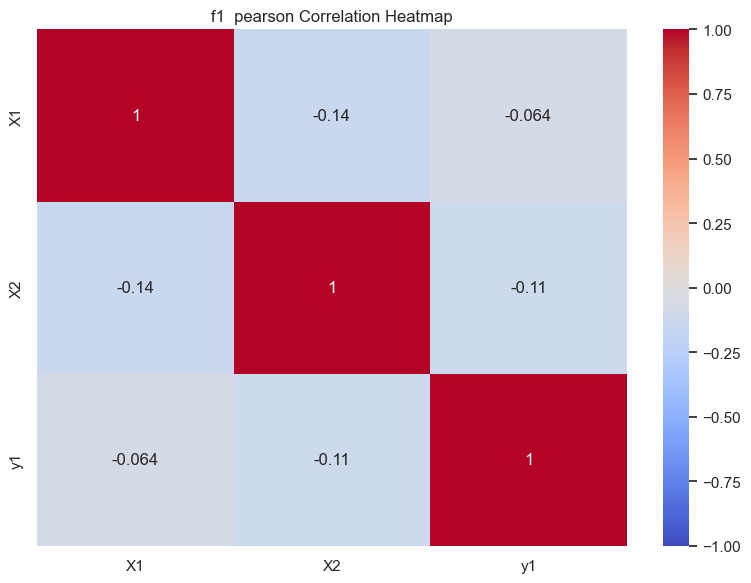


f2 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,0.214647,0.475505
X2,0.214647,1.000000,0.312626
y1,0.475505,0.312626,1.000000


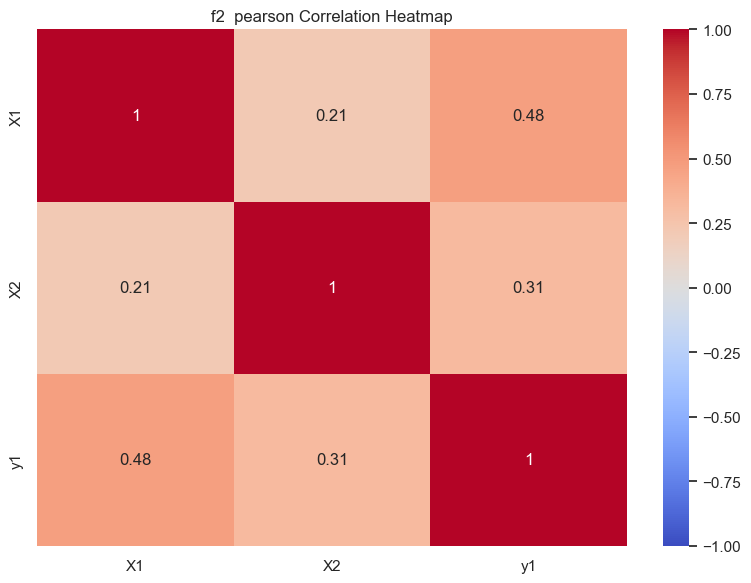


f3 Pearson Correlation Matrix


,X1,X2,X3,y1
X1,1.000000,0.131689,0.013795,0.145972
X2,0.131689,1.000000,-0.193742,0.255844
X3,0.013795,-0.193742,1.000000,-0.411108
y1,0.145972,0.255844,-0.411108,1.000000


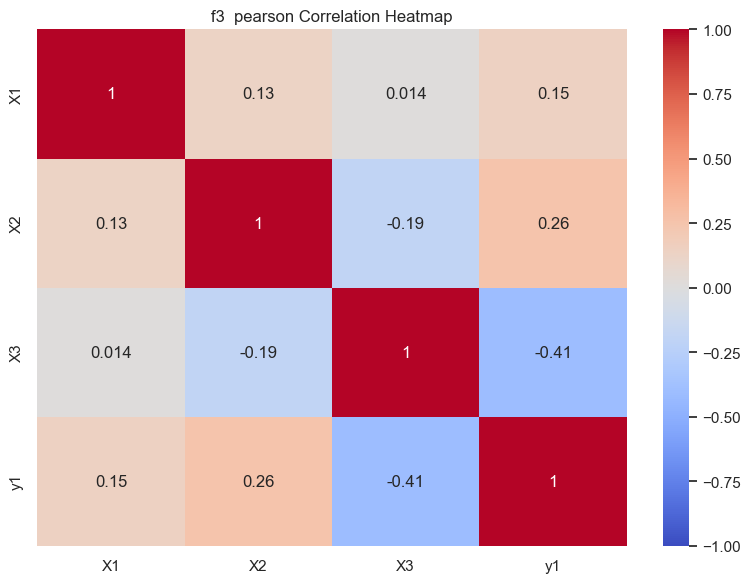


f4 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,0.254656,0.269139,0.198982,-0.512401
X2,0.254656,1.000000,-0.062985,0.190771,-0.408476
X3,0.269139,-0.062985,1.000000,-0.142776,-0.157469
X4,0.198982,0.190771,-0.142776,1.000000,-0.427314
y1,-0.512401,-0.408476,-0.157469,-0.427314,1.000000


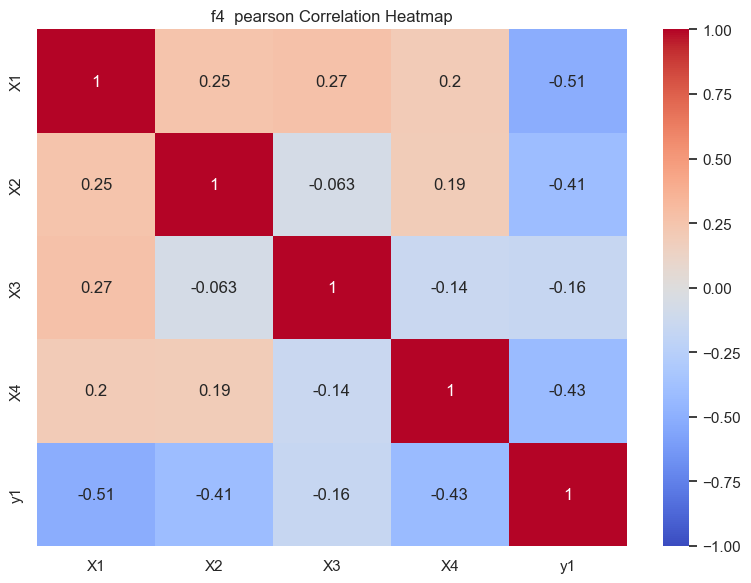


f5 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,-0.026452,0.017119,0.297821,0.453752
X2,-0.026452,1.000000,0.294671,0.178274,0.473266
X3,0.017119,0.294671,1.000000,-0.078307,0.522715
X4,0.297821,0.178274,-0.078307,1.000000,0.421626
y1,0.453752,0.473266,0.522715,0.421626,1.000000


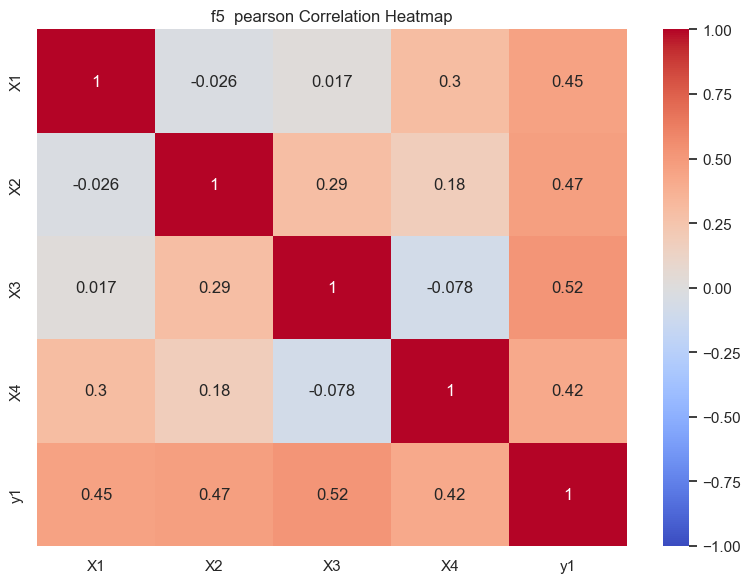


f6 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.108545,-0.129528,0.056965,-0.395518,0.102304
X2,-0.108545,1.000000,0.035443,-0.267086,0.222550,-0.397600
X3,-0.129528,0.035443,1.000000,0.309824,-0.107310,0.266050
X4,0.056965,-0.267086,0.309824,1.000000,-0.266071,0.551664
X5,-0.395518,0.222550,-0.107310,-0.266071,1.000000,-0.670730
y1,0.102304,-0.397600,0.266050,0.551664,-0.670730,1.000000


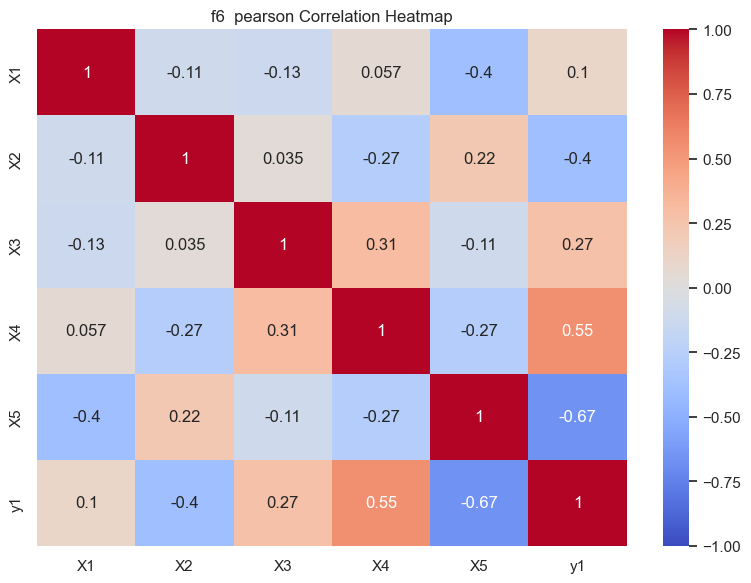


f7 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,0.015141,-0.138404,0.013670,0.030167,-0.503365,-0.492065
X2,0.015141,1.000000,0.098938,0.131117,0.316507,0.172089,-0.077544
X3,-0.138404,0.098938,1.000000,0.153892,-0.246274,0.090492,0.145297
X4,0.013670,0.131117,0.153892,1.000000,0.071020,-0.025301,-0.244090
X5,0.030167,0.316507,-0.246274,0.071020,1.000000,0.043685,-0.236483
X6,-0.503365,0.172089,0.090492,-0.025301,0.043685,1.000000,0.352592
y1,-0.492065,-0.077544,0.145297,-0.244090,-0.236483,0.352592,1.000000


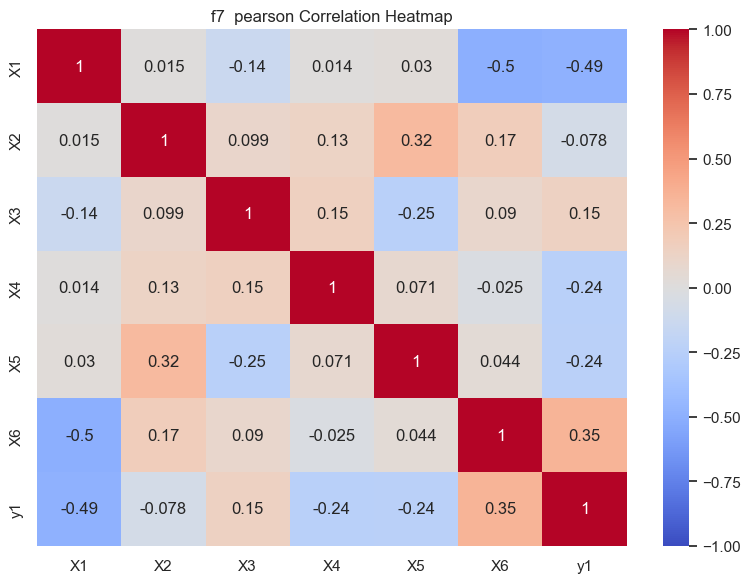


f8 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.075336,0.191815,0.134513,0.108925,0.111736,0.093152,0.108902,-0.634273
X2,0.075336,1.000000,0.028374,-0.123307,0.121037,0.058607,0.035352,-0.260979,-0.198142
X3,0.191815,0.028374,1.000000,0.104881,-0.192933,-0.209916,-0.156823,-0.011611,-0.671345
X4,0.134513,-0.123307,0.104881,1.000000,-0.047506,-0.162134,-0.012488,0.268689,-0.276505
X5,0.108925,0.121037,-0.192933,-0.047506,1.000000,0.094921,0.200551,0.068009,0.010462
X6,0.111736,0.058607,-0.209916,-0.162134,0.094921,1.000000,0.049151,0.074777,0.116778
X7,0.093152,0.035352,-0.156823,-0.012488,0.200551,0.049151,1.000000,-0.144240,-0.279971
X8,0.108902,-0.260979,-0.011611,0.268689,0.068009,0.074777,-0.144240,1.000000,0.111868
y1,-0.634273,-0.198142,-0.671345,-0.276505,0.010462,0.116778,-0.279971,0.111868,1.000000


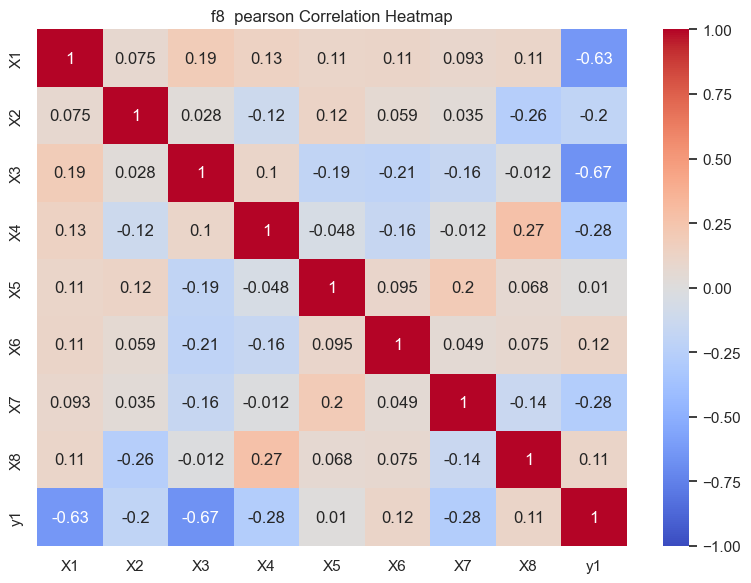

In [13]:
for name, df in functions_data.items():

    print(f"\n{name} Pearson Correlation Matrix")
    
    # Compute correlation matrix
    corr = df.corr()

    # Display numeric correlation table
    display(corr)

    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1
    )
    plt.title(f"{name}  pearson Correlation Heatmap")
    plt.tight_layout()
    plt.show()

#### Spearman Correlation


f1 — Spearman Correlation


,X1,X2,y1
X1,1.000000,-0.367647,0.272059
X2,-0.367647,1.000000,0.431373
y1,0.272059,0.431373,1.000000


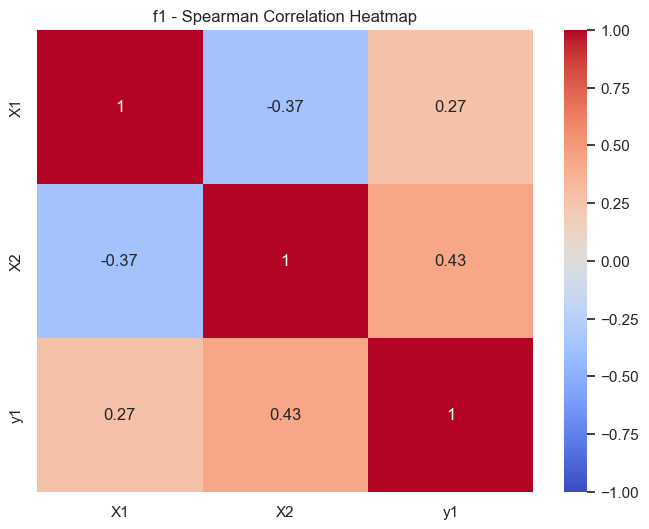


f2 — Spearman Correlation


,X1,X2,y1
X1,1.000000,0.100490,0.448529
X2,0.100490,1.000000,0.269608
y1,0.448529,0.269608,1.000000


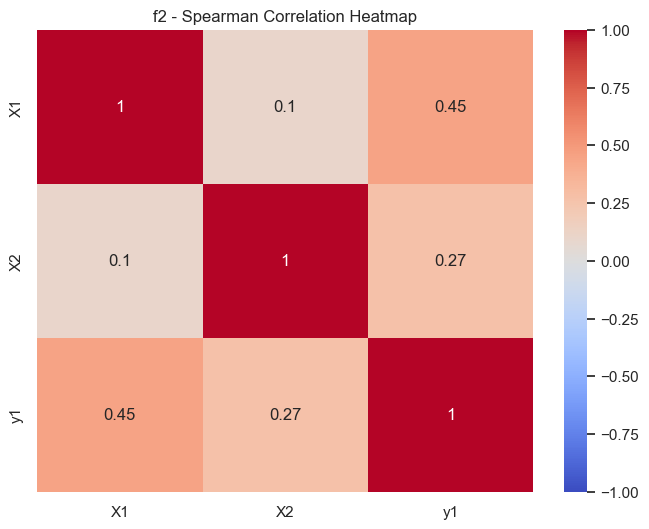


f3 — Spearman Correlation


,X1,X2,X3,y1
X1,1.000000,0.155280,-0.073970,0.153021
X2,0.155280,1.000000,-0.155280,0.262564
X3,-0.073970,-0.155280,1.000000,-0.208357
y1,0.153021,0.262564,-0.208357,1.000000


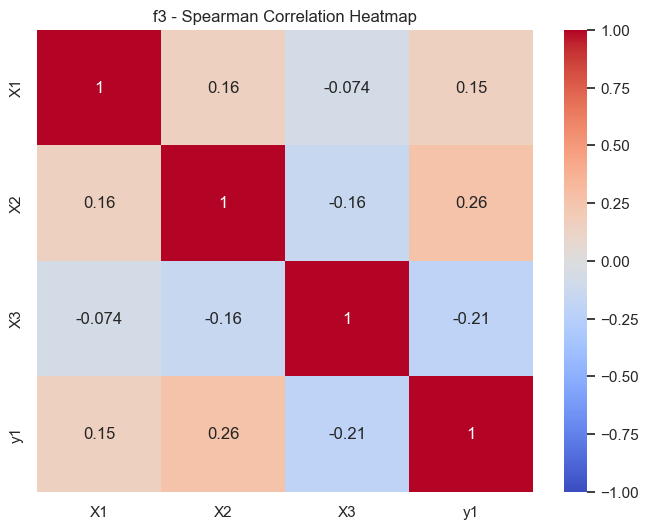


f4 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.267662,0.263395,0.193694,-0.495021
X2,0.267662,1.000000,-0.008298,0.169749,-0.431484
X3,0.263395,-0.008298,1.000000,-0.184211,-0.162873
X4,0.193694,0.169749,-0.184211,1.000000,-0.370318
y1,-0.495021,-0.431484,-0.162873,-0.370318,1.000000


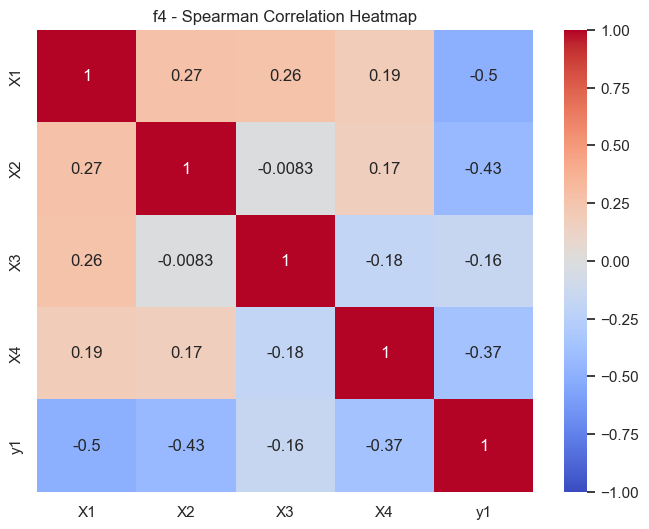


f5 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,-0.087302,-0.010685,0.265568,0.056166
X2,-0.087302,1.000000,0.399634,0.172161,0.523810
X3,-0.010685,0.399634,1.000000,-0.076019,0.622500
X4,0.265568,0.172161,-0.076019,1.000000,0.408425
y1,0.056166,0.523810,0.622500,0.408425,1.000000


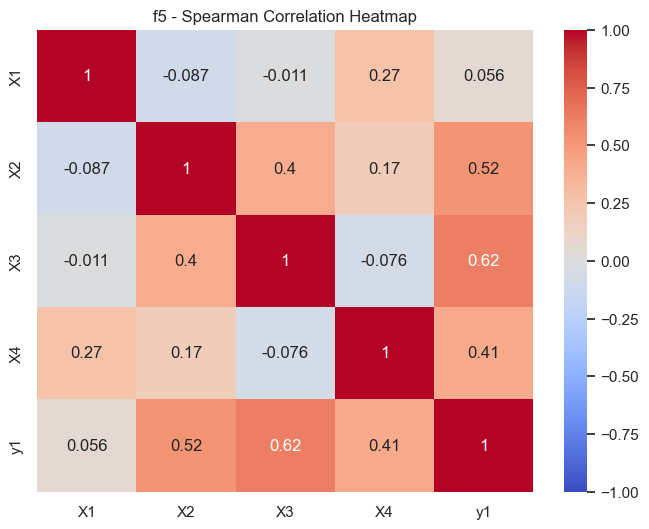


f6 — Spearman Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.063206,-0.097405,0.066555,-0.388032,0.030835
X2,-0.063206,1.000000,-0.033282,-0.255228,0.142574,-0.304992
X3,-0.097405,-0.033282,1.000000,0.352313,-0.114486,0.233552
X4,0.066555,-0.255228,0.352313,1.000000,-0.324786,0.540293
X5,-0.388032,0.142574,-0.114486,-0.324786,1.000000,-0.659951
y1,0.030835,-0.304992,0.233552,0.540293,-0.659951,1.000000


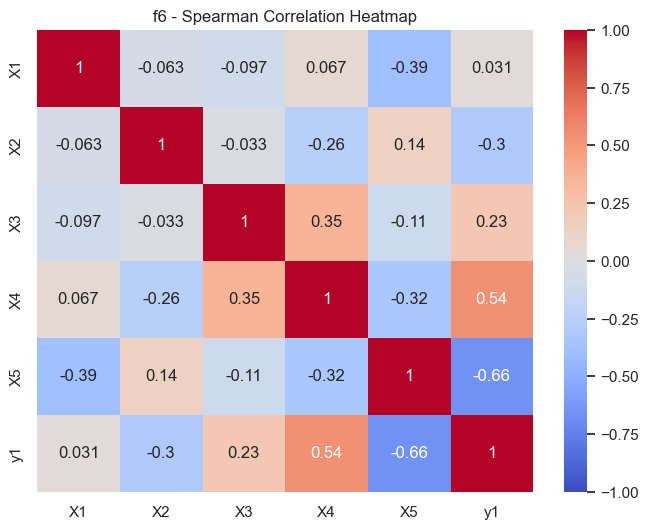


f7 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.030820,-0.120199,0.032006,-0.000474,-0.477477,-0.516833
X2,-0.030820,1.000000,0.077999,0.202703,0.339972,0.152916,-0.137032
X3,-0.120199,0.077999,1.000000,0.114272,-0.234708,0.137980,0.269796
X4,0.032006,0.202703,0.114272,1.000000,0.067093,0.027501,-0.198672
X5,-0.000474,0.339972,-0.234708,0.067093,1.000000,0.002371,-0.397582
X6,-0.477477,0.152916,0.137980,0.027501,0.002371,1.000000,0.348506
y1,-0.516833,-0.137032,0.269796,-0.198672,-0.397582,0.348506,1.000000


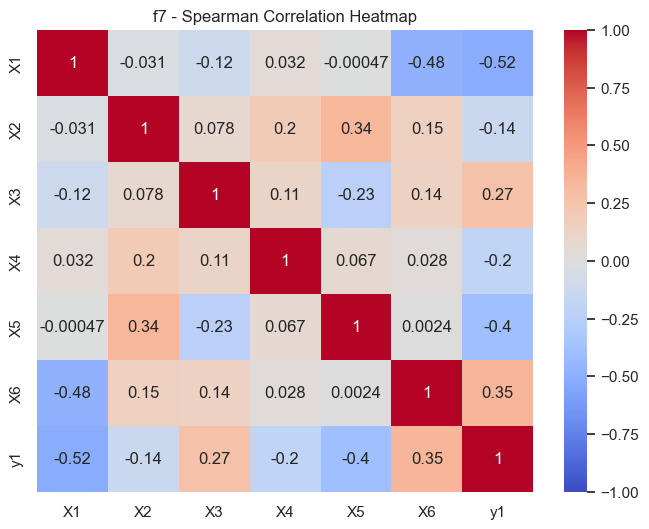


f8 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.074563,0.179278,0.135003,0.112184,0.101206,0.078754,0.096889,-0.626519
X2,0.074563,1.000000,0.040581,-0.135809,0.104354,0.051437,0.041691,-0.253361,-0.206975
X3,0.179278,0.040581,1.000000,0.140368,-0.194887,-0.195751,-0.129571,-0.047488,-0.631699
X4,0.135003,-0.135809,0.140368,1.000000,-0.074627,-0.184409,0.001110,0.250154,-0.259891
X5,0.112184,0.104354,-0.194887,-0.074627,1.000000,0.138522,0.199328,0.046873,0.030467
X6,0.101206,0.051437,-0.195751,-0.184409,0.138522,1.000000,0.073761,0.108301,0.067224
X7,0.078754,0.041691,-0.129571,0.001110,0.199328,0.073761,1.000000,-0.143822,-0.309405
X8,0.096889,-0.253361,-0.047488,0.250154,0.046873,0.108301,-0.143822,1.000000,0.104474
y1,-0.626519,-0.206975,-0.631699,-0.259891,0.030467,0.067224,-0.309405,0.104474,1.000000


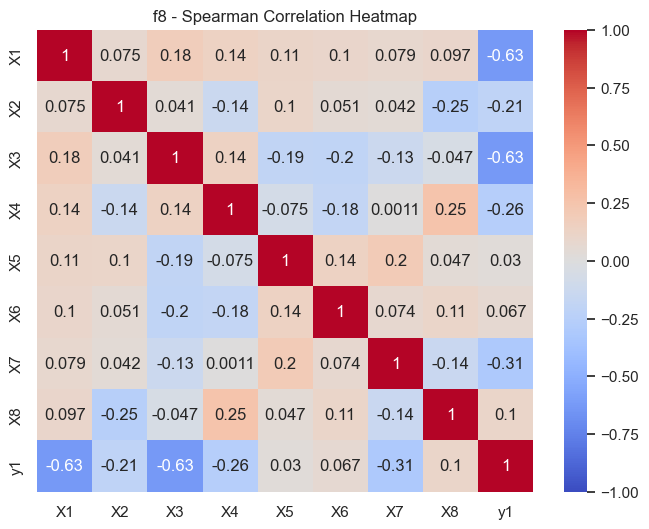

In [14]:
for name, df in functions_data.items():
    print(f"\n{name} — Spearman Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    spearman_corr = df[input_cols + output_cols].corr(method='spearman')
    display(spearman_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Spearman Correlation Heatmap")
    plt.show()

#### Kendall Correlation


f1 — Kendall Correlation


,X1,X2,y1
X1,1.000000,-0.294118,0.176471
X2,-0.294118,1.000000,0.294118
y1,0.176471,0.294118,1.000000


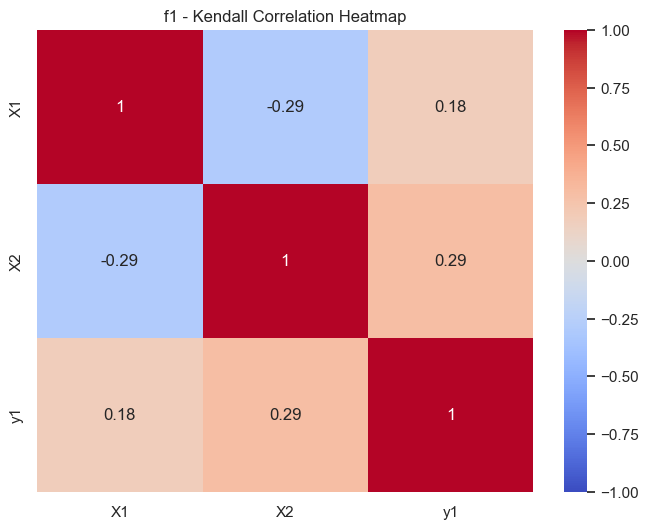


f2 — Kendall Correlation


,X1,X2,y1
X1,1.000000,0.058824,0.323529
X2,0.058824,1.000000,0.205882
y1,0.323529,0.205882,1.000000


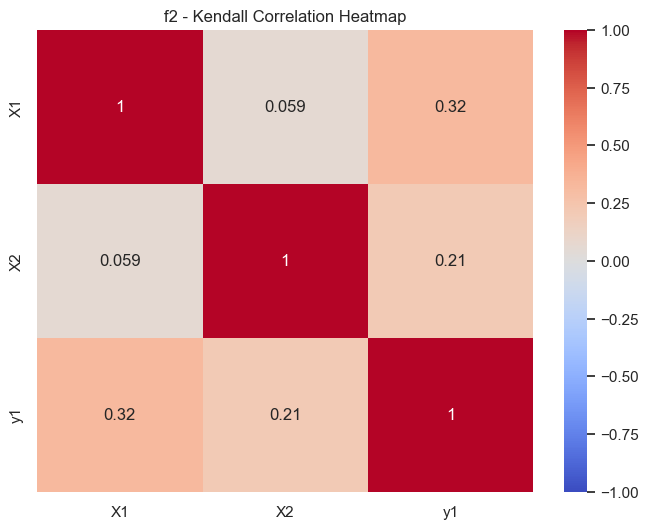


f3 — Kendall Correlation


,X1,X2,X3,y1
X1,1.000000,0.125541,-0.056277,0.125541
X2,0.125541,1.000000,-0.116883,0.203463
X3,-0.056277,-0.116883,1.000000,-0.116883
y1,0.125541,0.203463,-0.116883,1.000000


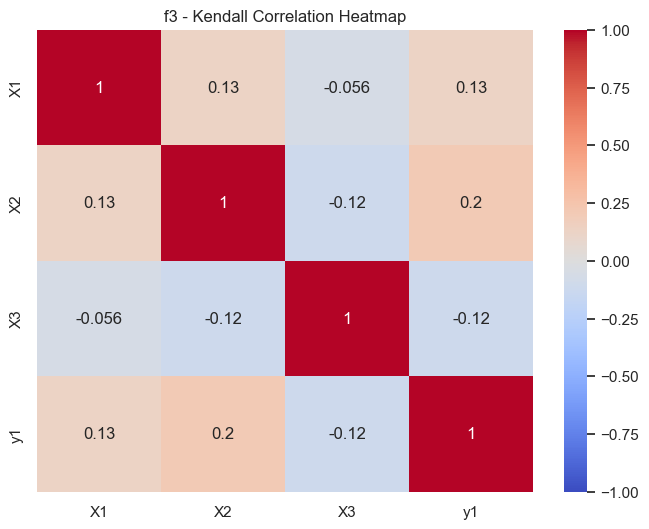


f4 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.180180,0.204204,0.132132,-0.336336
X2,0.180180,1.000000,0.015015,0.123123,-0.303303
X3,0.204204,0.015015,1.000000,-0.141141,-0.159159
X4,0.132132,0.123123,-0.141141,1.000000,-0.261261
y1,-0.336336,-0.303303,-0.159159,-0.261261,1.000000


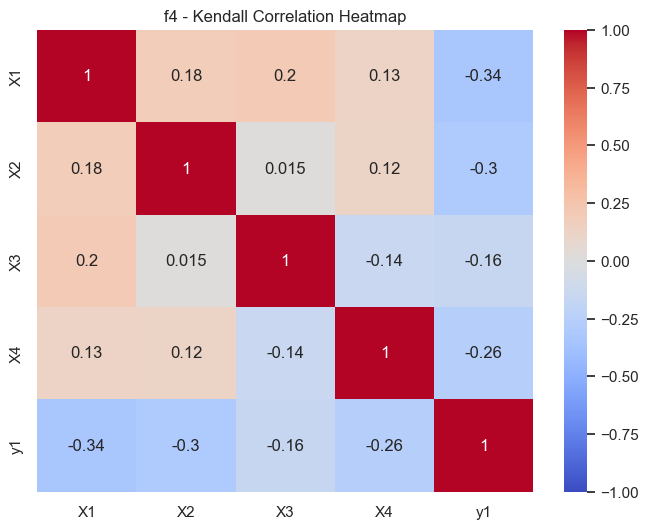


f5 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,-0.071225,-0.022825,0.202279,0.002849
X2,-0.071225,1.000000,0.251070,0.099715,0.344729
X3,-0.022825,0.251070,1.000000,-0.079886,0.462197
X4,0.202279,0.099715,-0.079886,1.000000,0.276353
y1,0.002849,0.344729,0.462197,0.276353,1.000000


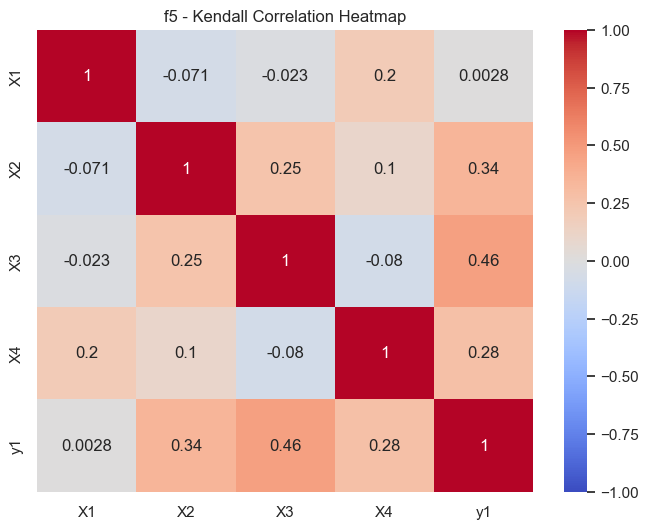


f6 — Kendall Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.057143,-0.062857,0.062768,-0.291013,0.022825
X2,-0.057143,1.000000,-0.022857,-0.171184,0.079886,-0.222539
X3,-0.062857,-0.022857,1.000000,0.256776,-0.062768,0.171184
X4,0.062768,-0.171184,0.256776,1.000000,-0.270655,0.401709
X5,-0.291013,0.079886,-0.062768,-0.270655,1.000000,-0.470085
y1,0.022825,-0.222539,0.171184,0.401709,-0.470085,1.000000


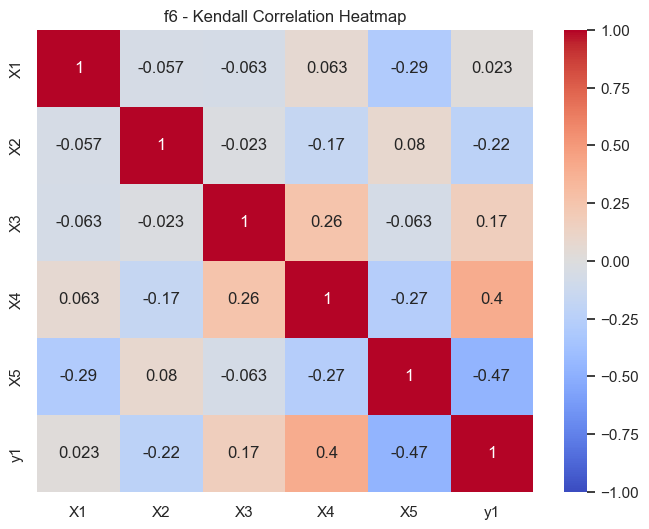


f7 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,0.000000,-0.078078,0.021021,-0.012012,-0.336336,-0.390390
X2,0.000000,1.000000,0.051051,0.132132,0.237237,0.075075,-0.099099
X3,-0.078078,0.051051,1.000000,0.054054,-0.147147,0.099099,0.177177
X4,0.021021,0.132132,0.054054,1.000000,0.048048,0.012012,-0.150150
X5,-0.012012,0.237237,-0.147147,0.048048,1.000000,0.009009,-0.261261
X6,-0.336336,0.075075,0.099099,0.012012,0.009009,1.000000,0.225225
y1,-0.390390,-0.099099,0.177177,-0.150150,-0.261261,0.225225,1.000000


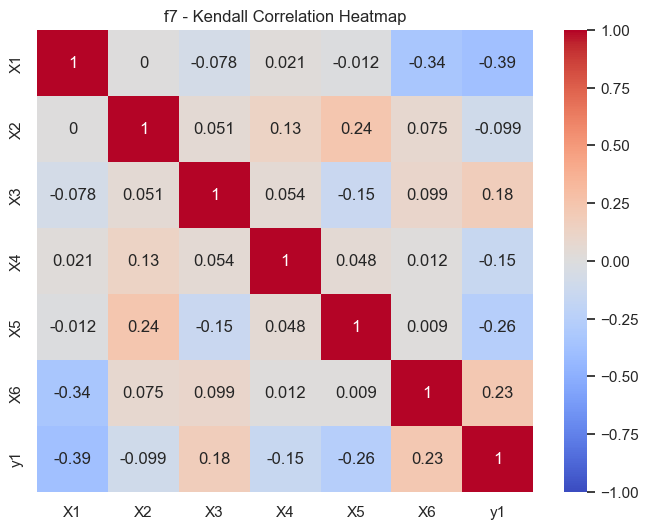


f8 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.061866,0.099517,0.085065,0.073465,0.048333,0.039614,0.057999,-0.447343
X2,0.061866,1.000000,0.017400,-0.106383,0.083172,0.007737,0.019333,-0.152805,-0.123731
X3,0.099517,0.017400,1.000000,0.079265,-0.133398,-0.139198,-0.087923,-0.040599,-0.462802
X4,0.085065,-0.106383,0.079265,1.000000,-0.044487,-0.096712,0.003867,0.179884,-0.173997
X5,0.073465,0.083172,-0.133398,-0.044487,1.000000,0.100580,0.139198,0.036750,0.030933
X6,0.048333,0.007737,-0.139198,-0.096712,0.100580,1.000000,0.059932,0.065764,0.032866
X7,0.039614,0.019333,-0.087923,0.003867,0.139198,0.059932,1.000000,-0.092798,-0.244444
X8,0.057999,-0.152805,-0.040599,0.179884,0.036750,0.065764,-0.092798,1.000000,0.073465
y1,-0.447343,-0.123731,-0.462802,-0.173997,0.030933,0.032866,-0.244444,0.073465,1.000000


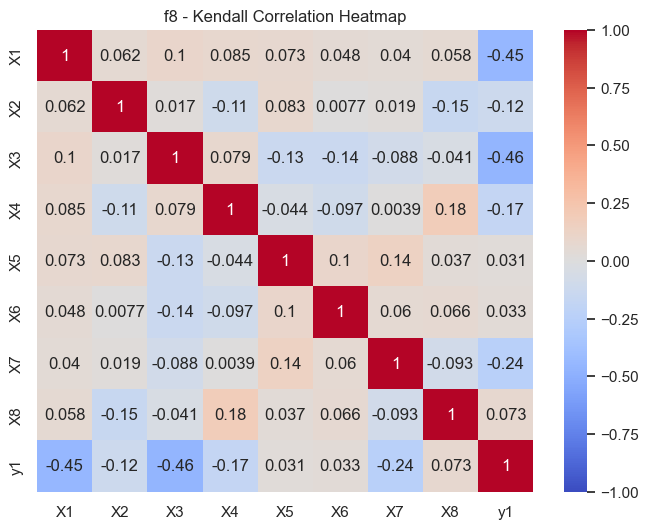

In [15]:
for name, df in functions_data.items():
    print(f"\n{name} — Kendall Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    kendall_corr = df[input_cols + output_cols].corr(method='kendall')
    display(kendall_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Kendall Correlation Heatmap")
    plt.show()


#### Mutual Information

In [16]:
from sklearn.feature_selection import mutual_info_regression

for name, df in functions_data.items():
    print(f"\n{name} — Mutual Information with Output")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values

    mi = mutual_info_regression(X, y, random_state=42)
    mi_df = pd.DataFrame({'Feature': input_cols, 'Mutual_Info': mi}).sort_values(by='Mutual_Info', ascending=False)
    display(mi_df)



f1 — Mutual Information with Output


,Feature,Mutual_Info
0,X1,0
1,X2,0



f2 — Mutual Information with Output


,Feature,Mutual_Info
0,X1,0.413035
1,X2,0.000000



f3 — Mutual Information with Output


...

,Feature,Mutual_Info
4,X5,0.303727
3,X4,0.109110
0,X1,0.000000
1,X2,0.000000
2,X3,0.000000



f7 — Mutual Information with Output


,Feature,Mutual_Info
5,X6,0.175433
0,X1,0.132676
4,X5,0.127465
1,X2,0.016725
2,X3,0.000000
3,X4,0.000000



f8 — Mutual Information with Output


,Feature,Mutual_Info
2,X3,0.349298
0,X1,0.282232
6,X7,0.136523
3,X4,0.018608
7,X8,0.001508
1,X2,0.000000
4,X5,0.000000
5,X6,0.000000


#### Partial Correlation

In [18]:
!pip install pingouin
import pingouin as pg

for name, df in functions_data.items():
    print(f"\n{name} — Partial Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    for x in input_cols:
        pcorr = pg.partial_corr(data=df, x=x, y=output_cols[0], covar=[c for c in input_cols if c != x])
        print(pcorr)



f1 — Partial Correlation
          n         r          CI95%     p-val
pearson  17 -0.080773  [-0.55, 0.43]  0.766184
          n         r         CI95%     p-val
pearson  17 -0.122668  [-0.58, 0.4]  0.650848

f2 — Partial Correlation
          n         r          CI95%     p-val
pearson  17  0.440212  [-0.07, 0.77]  0.087928
          n         r          CI95%     p-val
pearson  17  0.245063  [-0.29, 0.66]  0.360299

f3 — Partial Correlation
          n        r          CI95%     p-val
pearson  22  0.14352  [-0.32, 0.55]  0.546074
          n         r          CI95%     p-val
pearson  22  0.178374  [-0.29, 0.58]  0.451803
          n        r          CI95%     p-val
pearson  22 -0.38894  [-0.71, 0.06]  0.090097

f4 — Partial Correlation
          n         r           CI95%    p-val
pearson  37 -0.386275  [-0.64, -0.06]  0.02404
          n         r         CI95%     p-val
pearson  37 -0.321762  [-0.6, 0.02]  0.063497
          n         r          CI95%     p-val
pearson  37

#### Feature vs Output Plots 


Feature vs Output Plots for f1
X shape for f1: (17, 2)
y shape for f1: (17,)


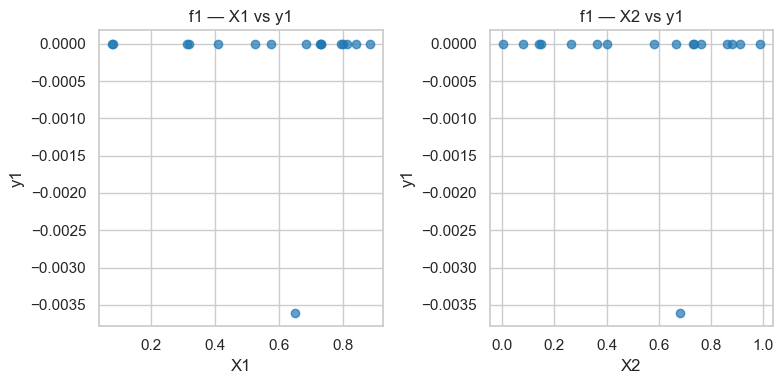


Feature vs Output Plots for f2
X shape for f2: (17, 2)
y shape for f2: (17,)


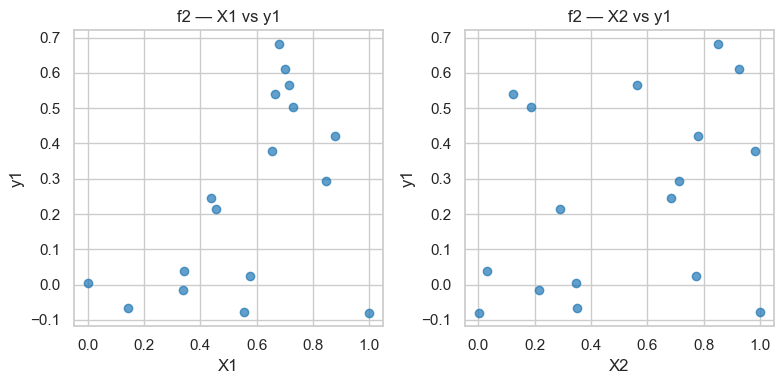


Feature vs Output Plots for f3
X shape for f3: (22, 3)
y shape for f3: (22,)


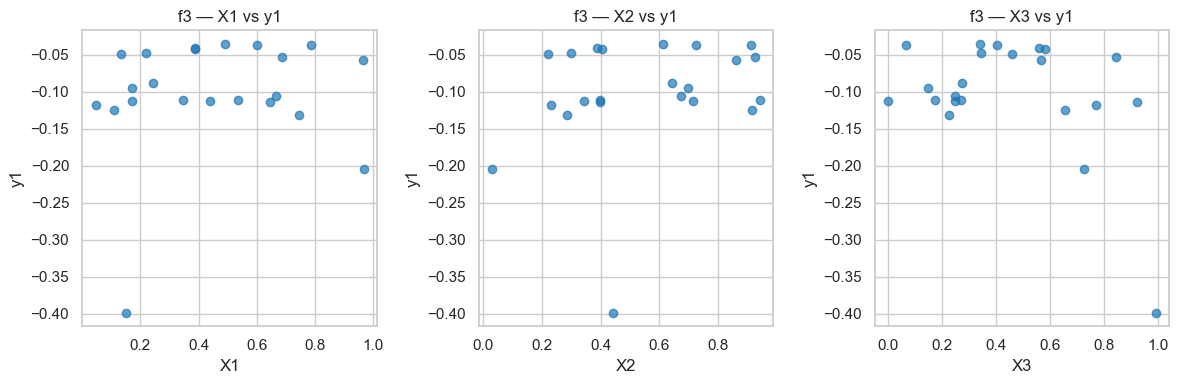


Feature vs Output Plots for f4
X shape for f4: (37, 4)
y shape for f4: (37,)


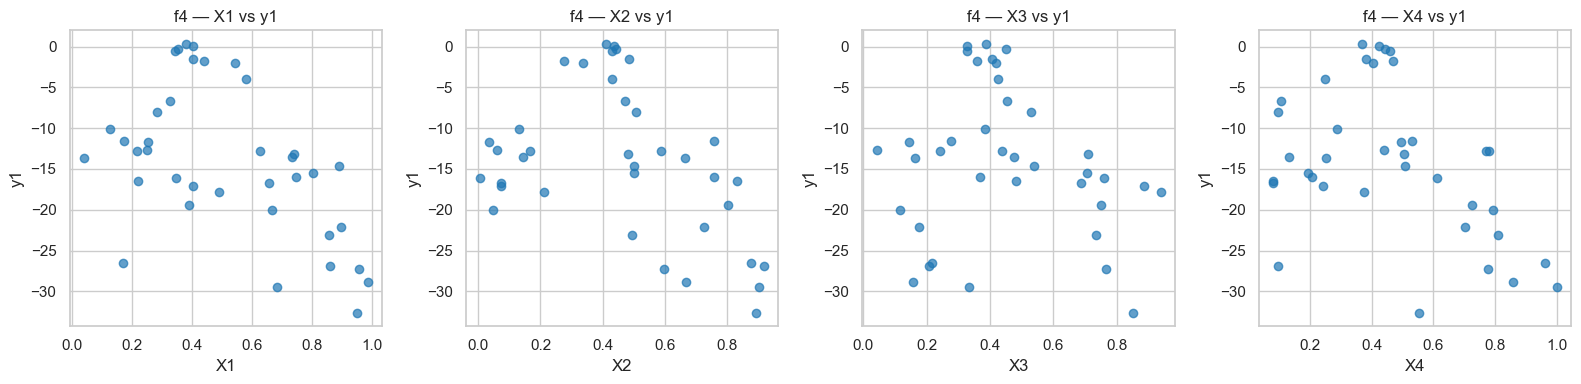


Feature vs Output Plots for f5
X shape for f5: (27, 4)
y shape for f5: (27,)


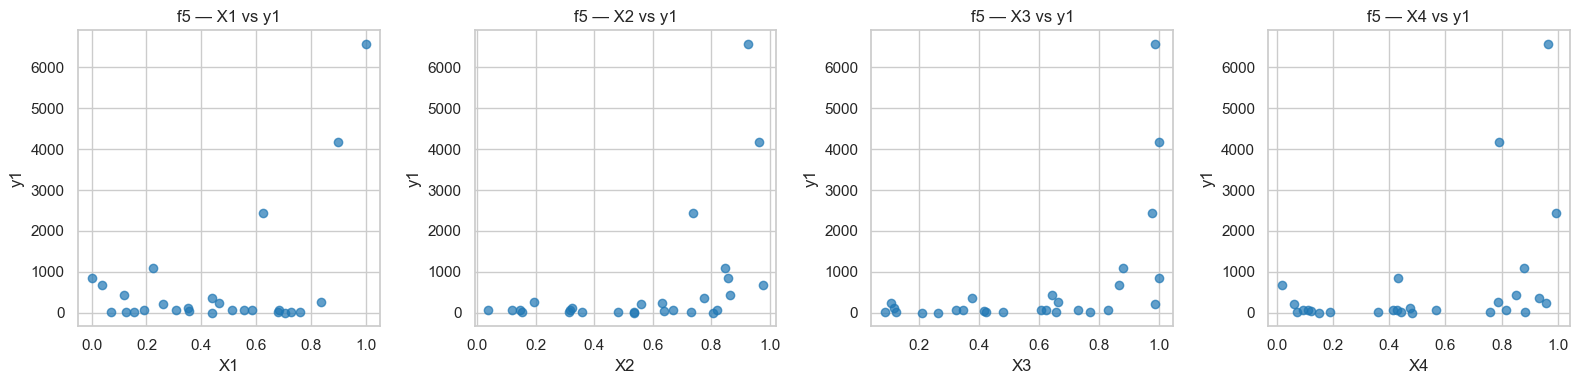


Feature vs Output Plots for f6
X shape for f6: (27, 5)
y shape for f6: (27,)


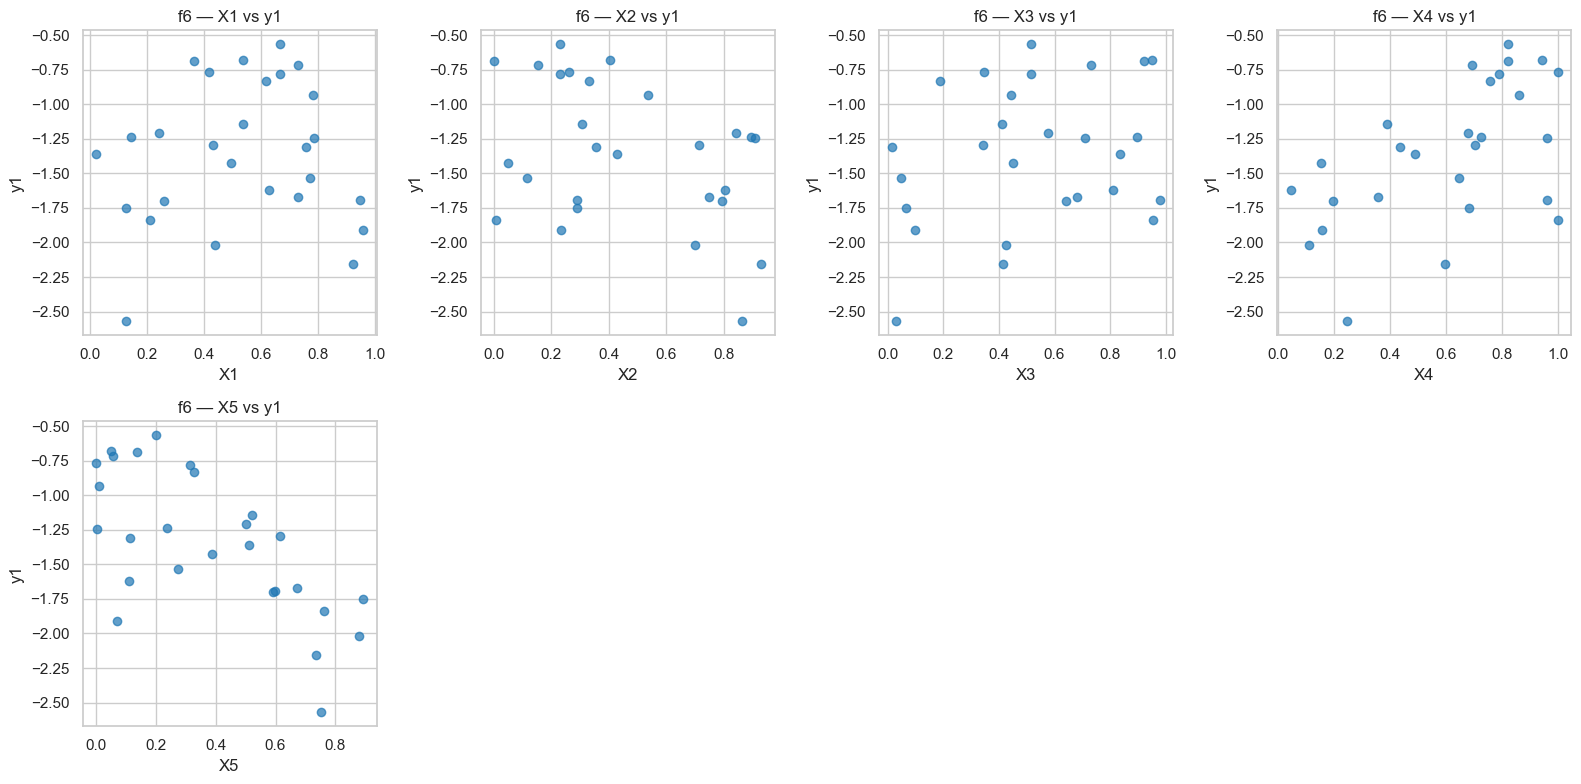


Feature vs Output Plots for f7
X shape for f7: (37, 6)
y shape for f7: (37,)


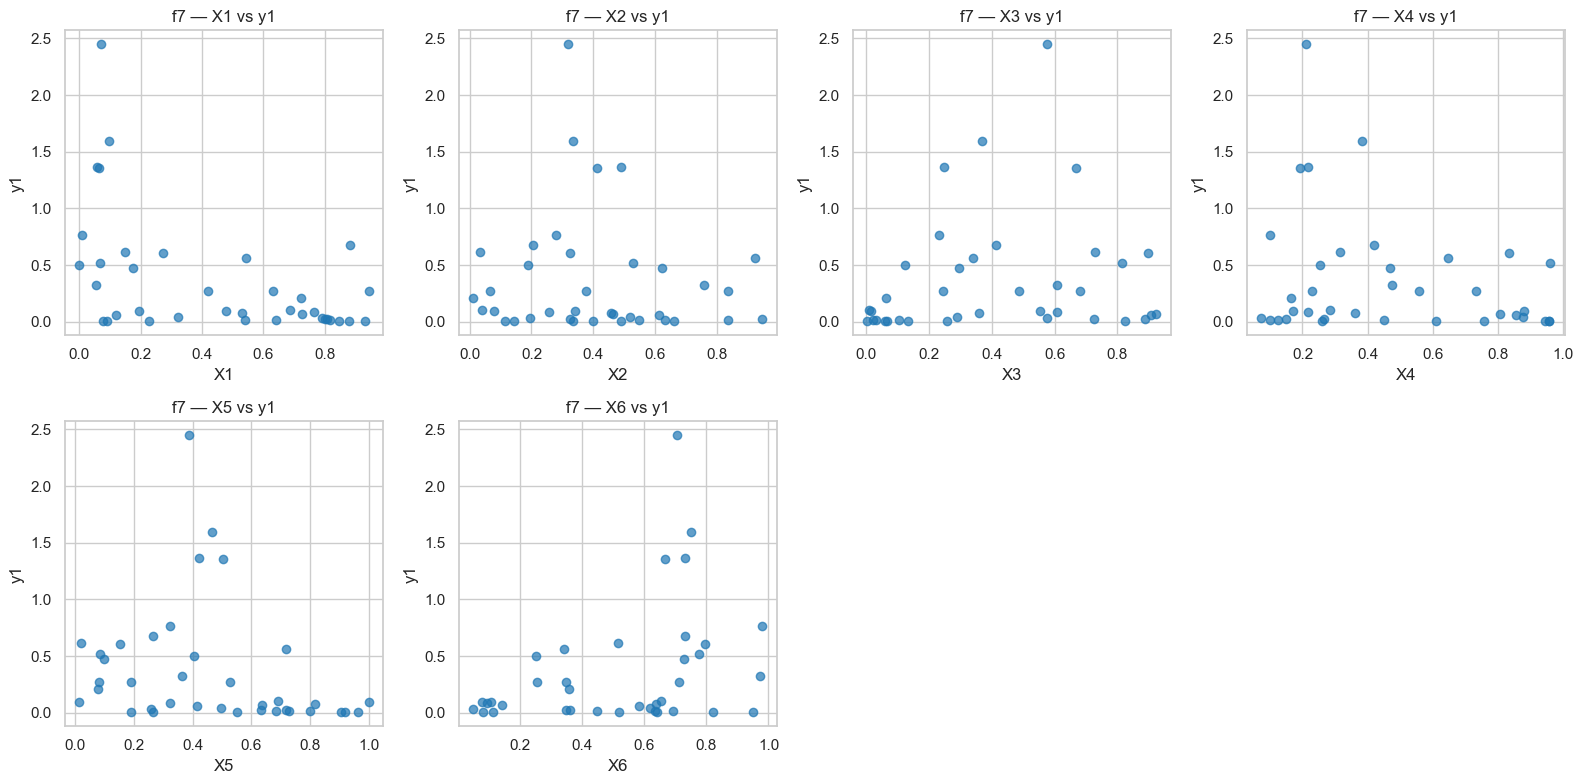


Feature vs Output Plots for f8
X shape for f8: (46, 8)
y shape for f8: (46,)


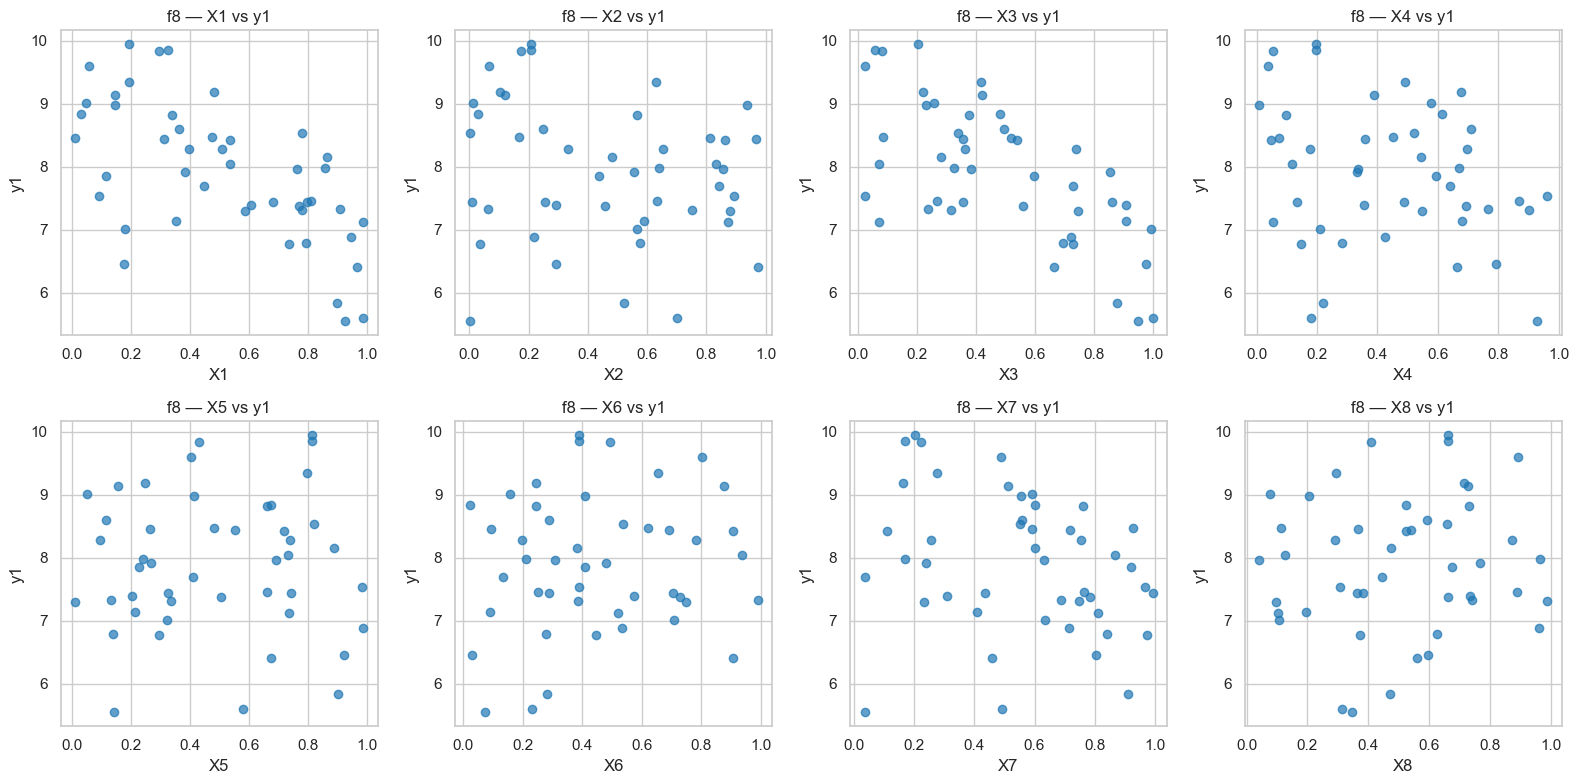

In [19]:
for name, df in functions_data.items():

    print(f"\nFeature vs Output Plots for {name}")


    # Extract input/output columns
    input_cols = [col for col in df.columns if col.startswith("X")]
    output_cols = [col for col in df.columns if col.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values  # use first output column for coloring/plot


    # Sanity checks
    print(f"X shape for {name}: {X.shape}")
    print(f"y shape for {name}: {y.shape}")

    assert X.shape[0] == y.shape[0], f"Mismatch in samples for {name}!"
    expected_features = len(input_cols)
    assert X.shape[1] == expected_features, f"Unexpected feature count in {name}!"


    # Plot each feature vs y
    n_features = X.shape[1]

    # Determine grid size (2 rows, dynamic columns)
    n_cols = min(4, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.ravel() if n_features > 1 else [axes]

    for i in range(n_features):
        ax = axes[i]
        ax.scatter(X[:, i], y, color='tab:blue', alpha=0.7)
        ax.set_xlabel(input_cols[i])
        ax.set_ylabel(output_cols[0])
        ax.set_title(f"{name} — {input_cols[i]} vs {output_cols[0]}")

    # Hide unused subplots
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()



=== f1 — Feature & Output Distributions ===


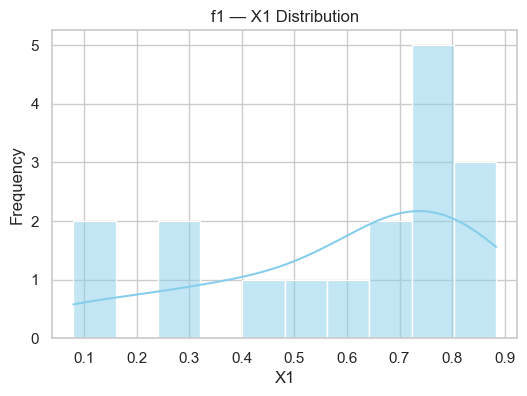

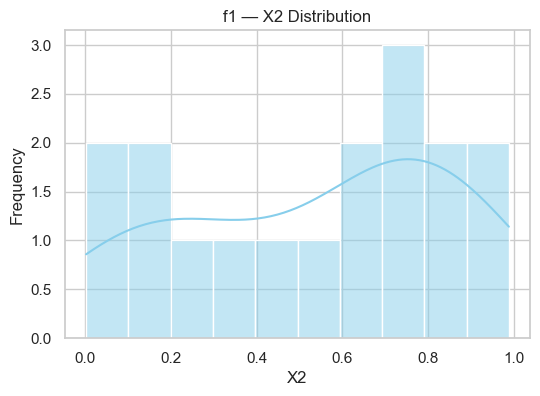

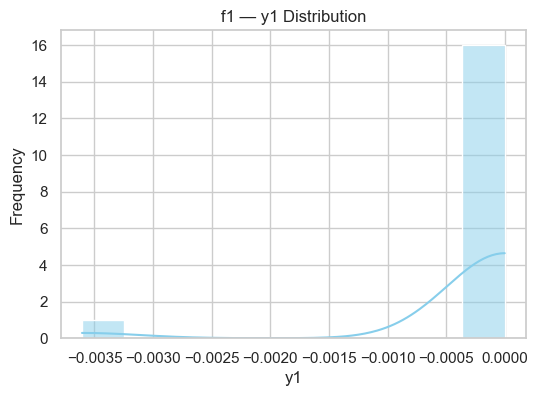


=== f2 — Feature & Output Distributions ===


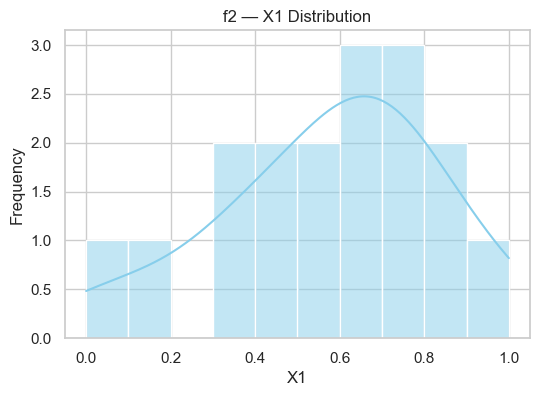

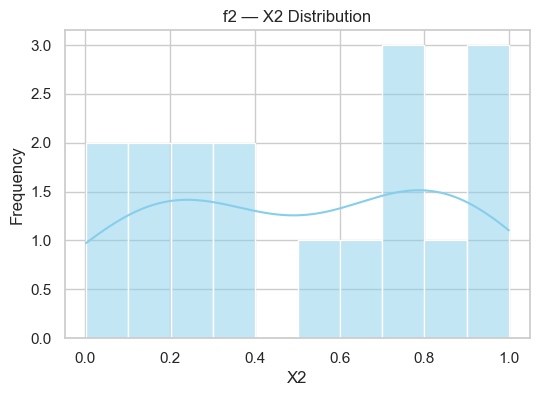

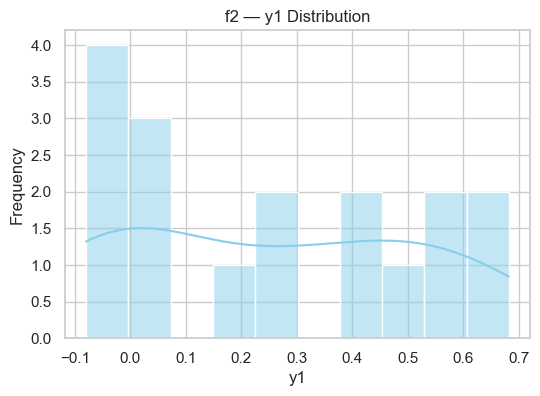


=== f3 — Feature & Output Distributions ===


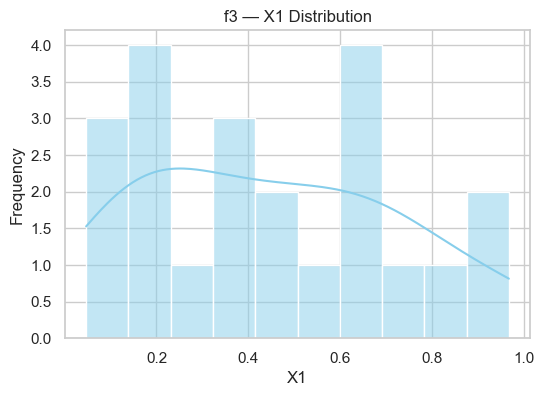

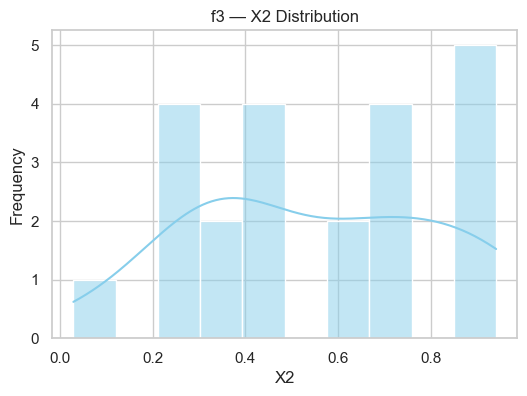

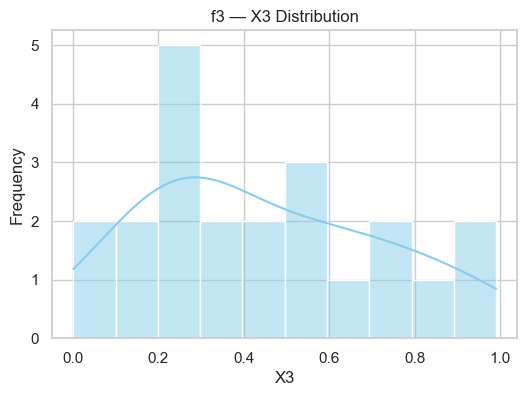

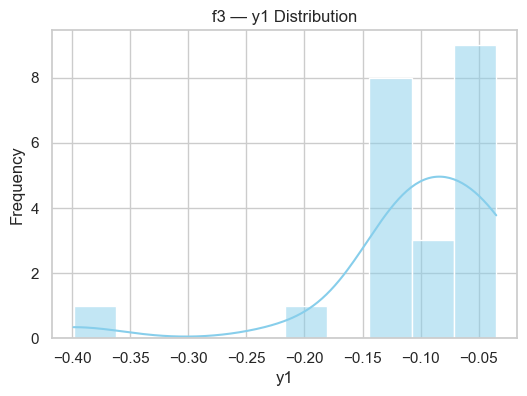


=== f4 — Feature & Output Distributions ===


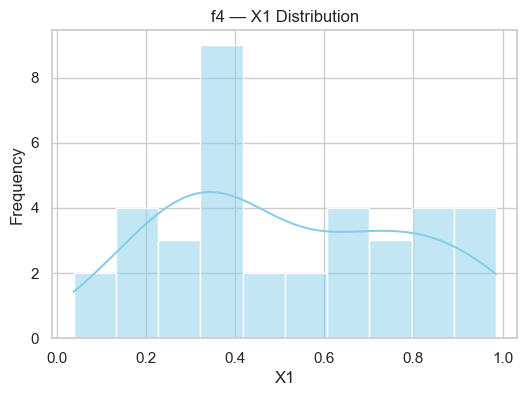

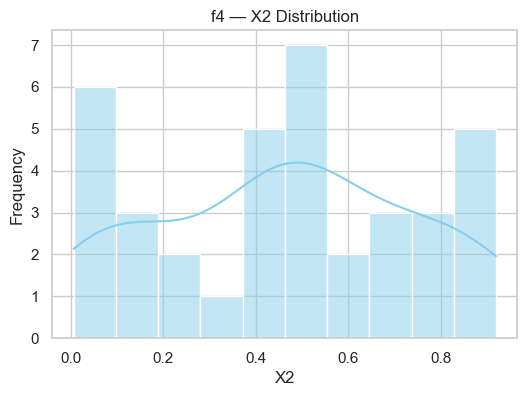

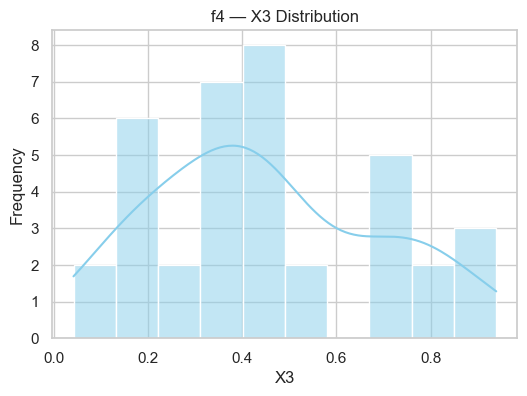

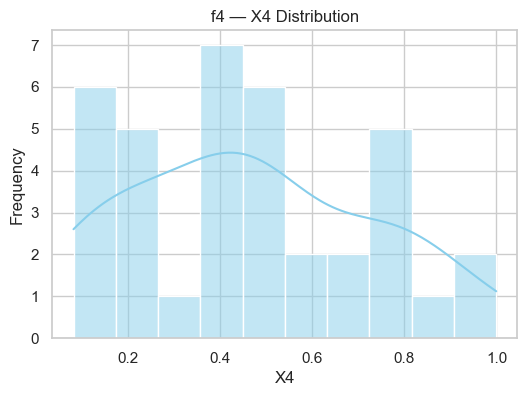

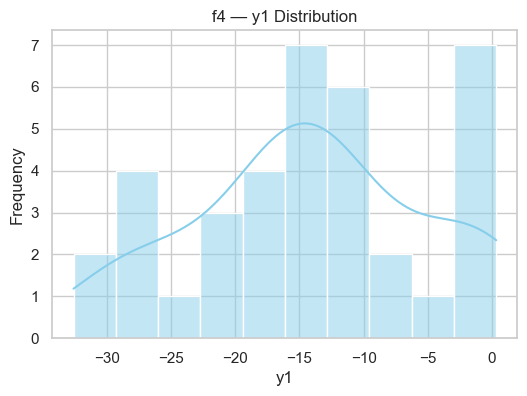


=== f5 — Feature & Output Distributions ===


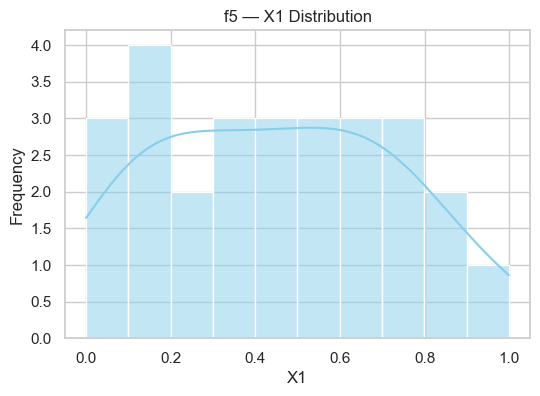

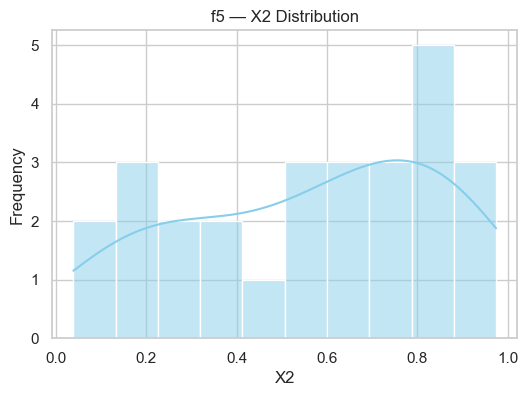

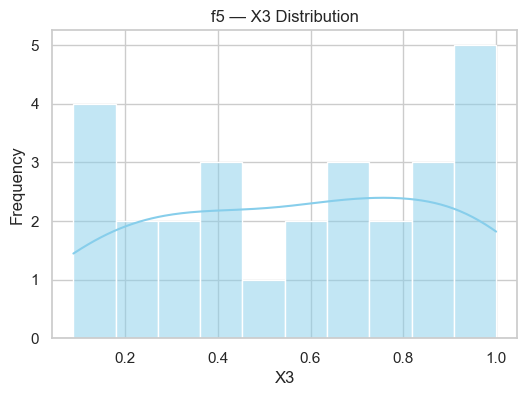

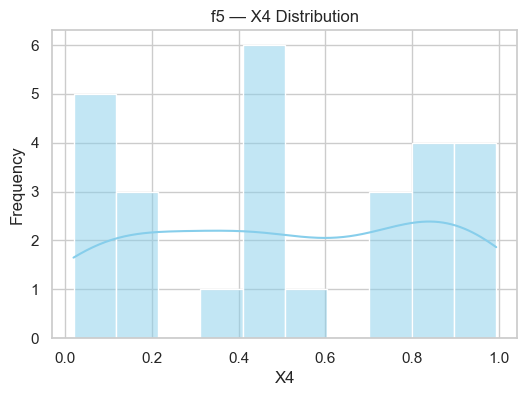

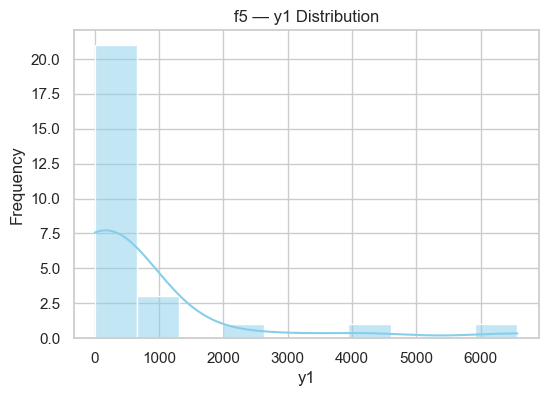


=== f6 — Feature & Output Distributions ===


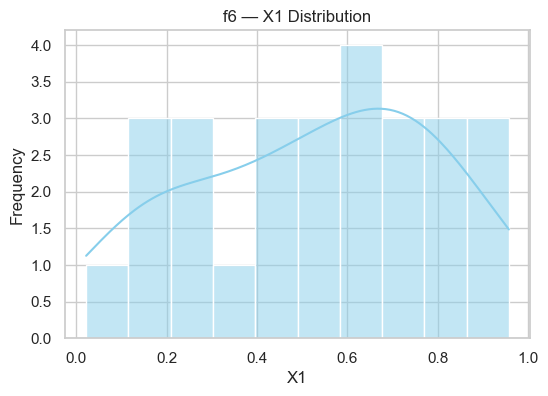

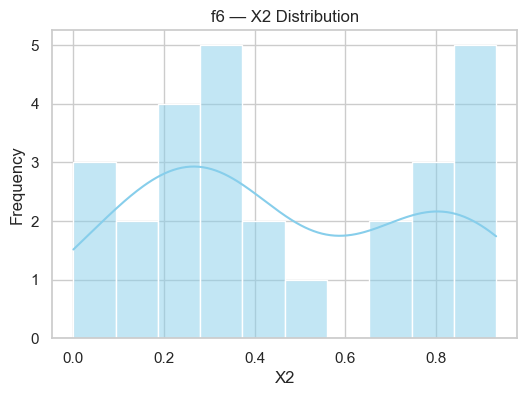

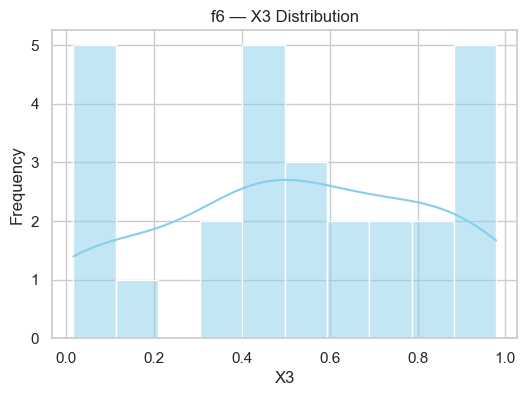

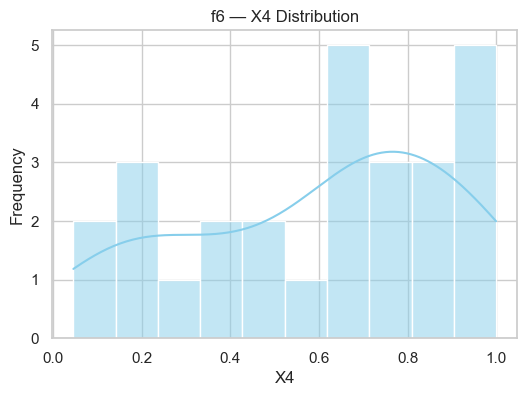

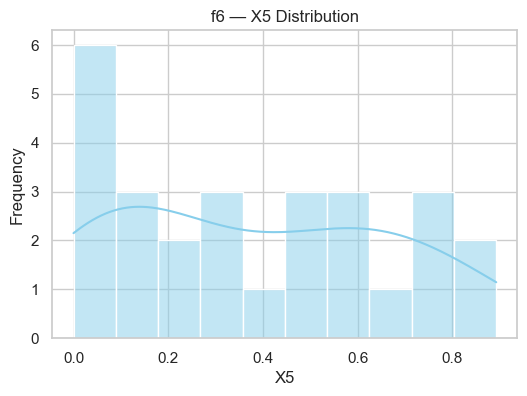

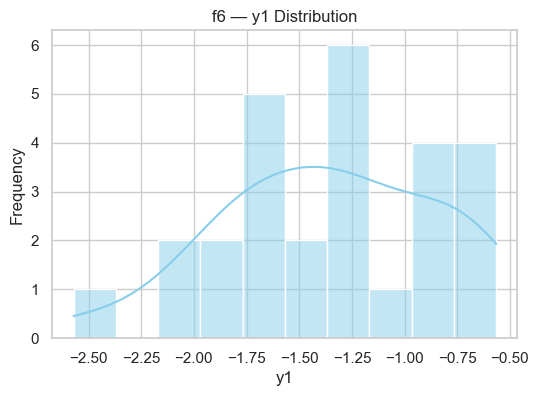


=== f7 — Feature & Output Distributions ===


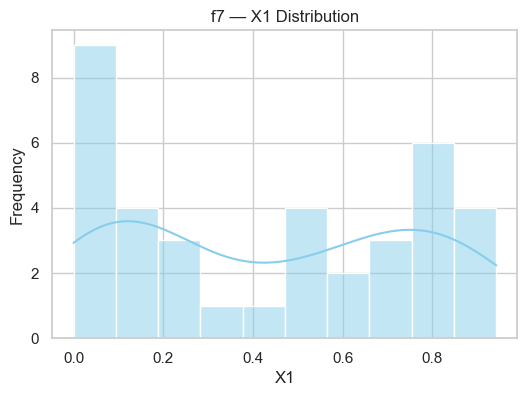

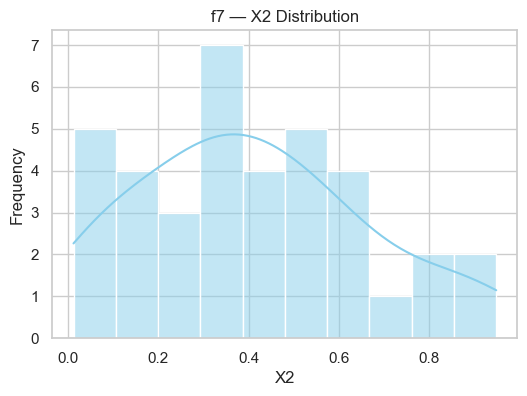

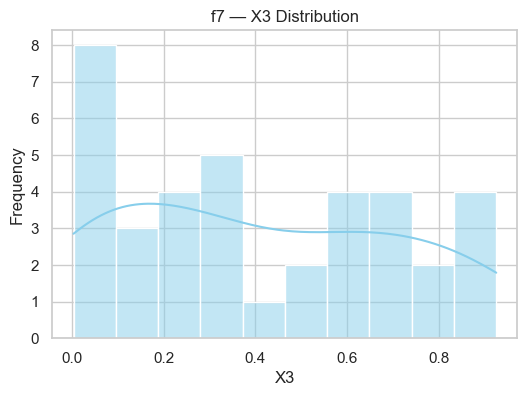

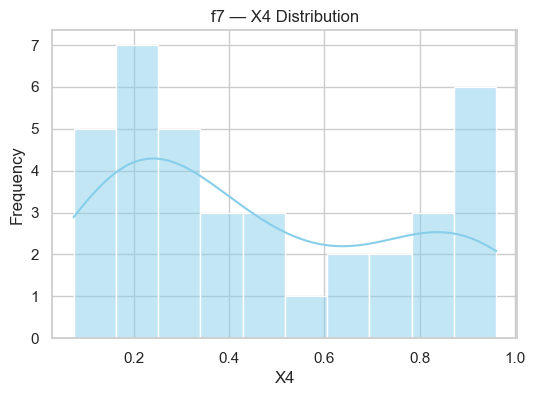

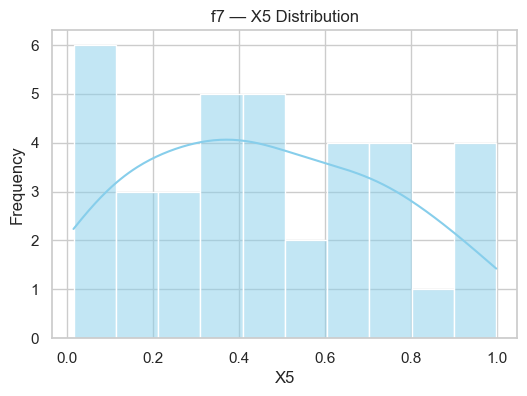

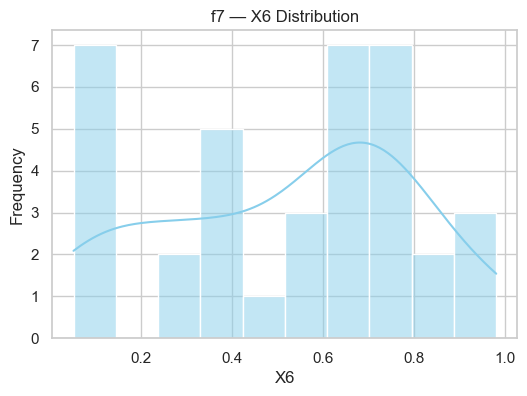

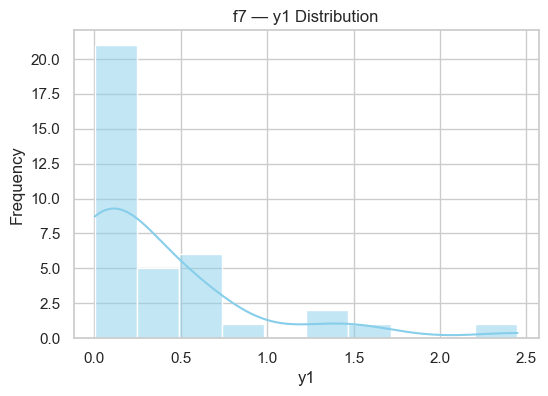


=== f8 — Feature & Output Distributions ===


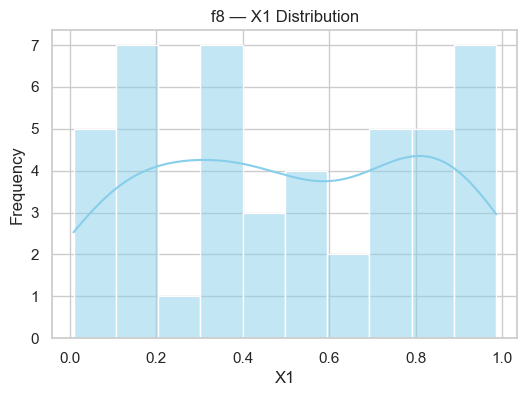

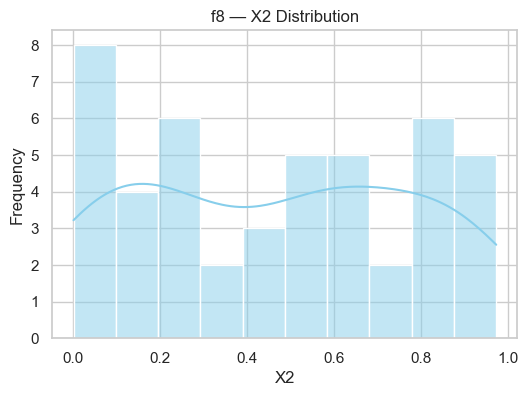

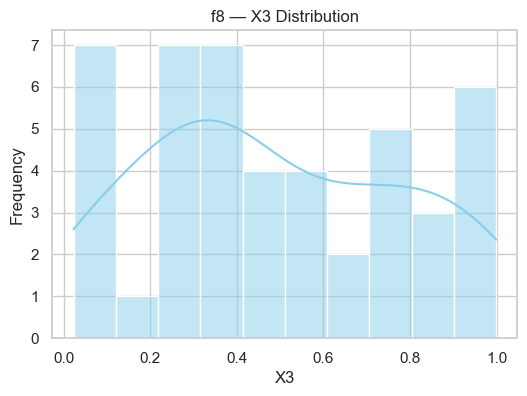

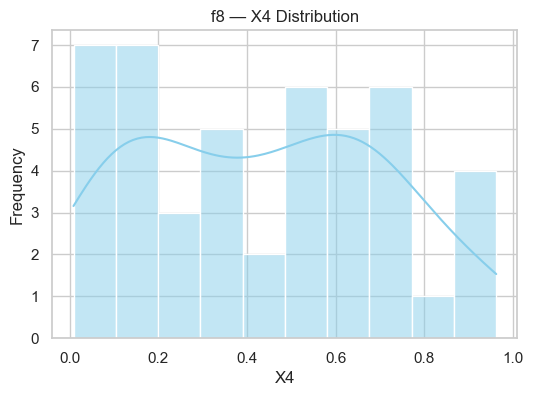

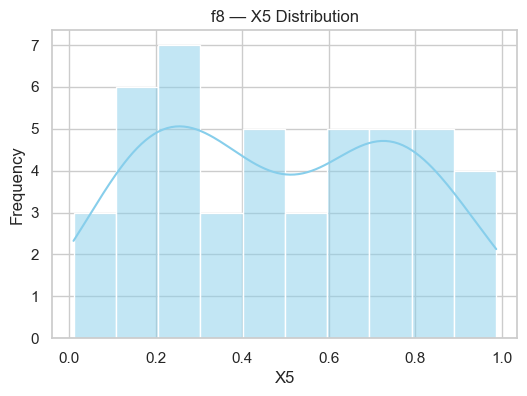

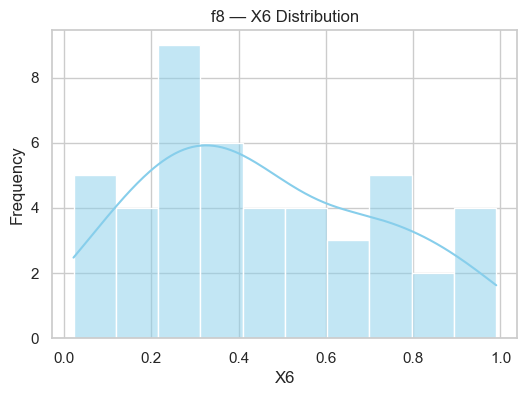

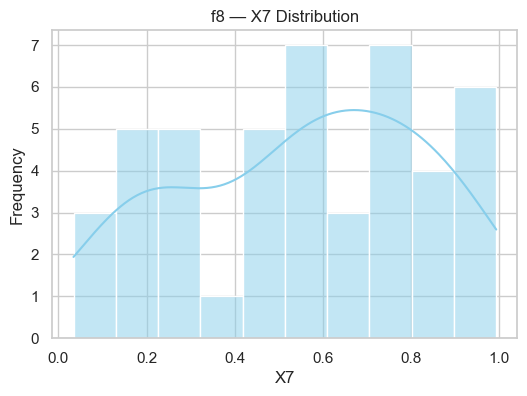

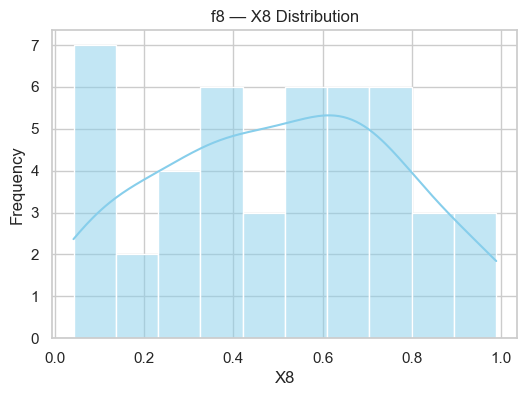

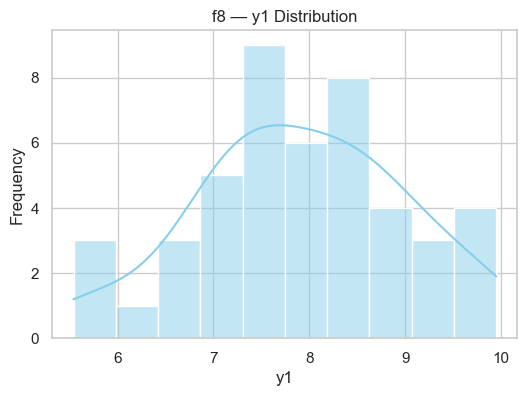

In [21]:
for name, df in functions_data.items():
    print(f"\n=== {name} — Feature & Output Distributions ===")
    
    # Identify input and output columns
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    all_cols = input_cols + output_cols
    
    for col in all_cols:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], kde=True, bins=10, color='skyblue')
        plt.title(f"{name} — {col} Distribution")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


#### Line Plot of y Values


f1 — Full Data Table
          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15
13  0.732162  0.364472   5.473776e-57
14  0.812650  0.143347 -1.062933e-161
15  0.079265  0.909848  2.607883e-248
16  0.525569  0.987823   2.236033e-98

f1 — y vs Instance Plot


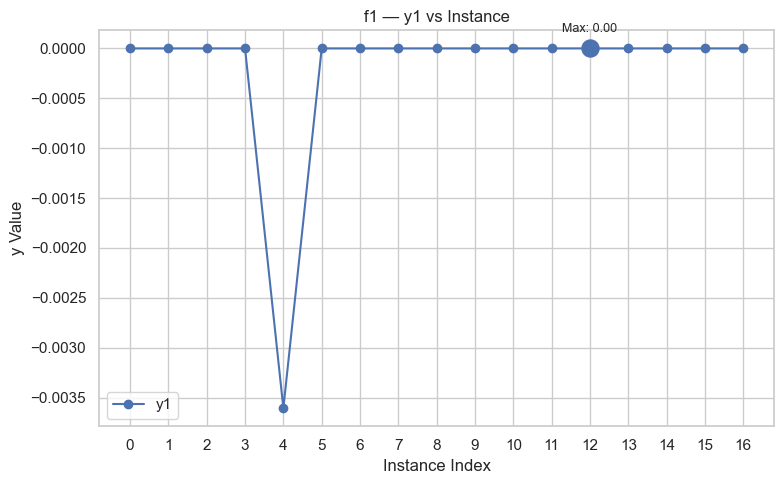


f2 — Full Data Table
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.554975  0.999446 -0.076408
11  0.999500  0.001800 -0.079755
12  0.727681  0.187140  0.503703
13  0.715483  0.563901  0.566166
14  0.678746  0.850809  0.682452
15  0.653993  0.981188  0.379820
16  0.000128  0.346419  0.005941

f2 — y vs Instance Plot


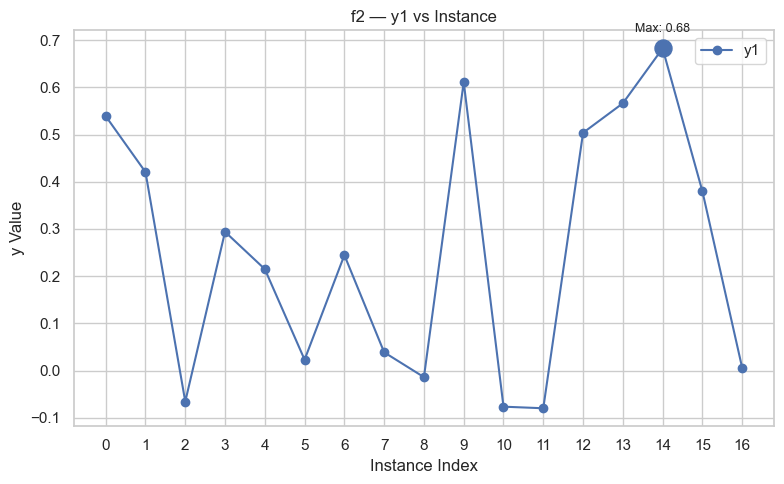


f3 — Full Data Table
          X1        X2        X3        y1
0   0.171525  0.343917  0.248737 -0.112122
1   0.242114  0.644074  0.272433 -0.087963
2   0.534906  0.398501  0.173389 -0.111415
3   0.492581  0.611593  0.340176 -0.034835
4   0.134622  0.219917  0.458206 -0.048008
5   0.345523  0.941360  0.269363 -0.110621
6   0.151837  0.439991  0.990882 -0.398926
7   0.645503  0.397143  0.919771 -0.113869
8   0.746912  0.284196  0.226300 -0.131461
9   0.170477  0.697032  0.149169 -0.094190
10  0.220549  0.297825  0.343555 -0.046947
11  0.666014  0.671985  0.246295 -0.105965
12  0.046809  0.231360  0.770618 -0.118048
13  0.600097  0.725136  0.066089 -0.036378
14  0.965995  0.861120  0.566829 -0.056758
15  0.389233  0.386084  0.558916 -0.041168
16  0.967200  0.029200  0.723300 -0.204966
17  0.437962  0.715305  0.000876 -0.111768
18  0.387933  0.405240  0.580181 -0.041279
19  0.688252  0.924125  0.842251 -0.053147
20  0.788392  0.913423  0.403090 -0.036375
21  0.110343  0.915465  0.655916

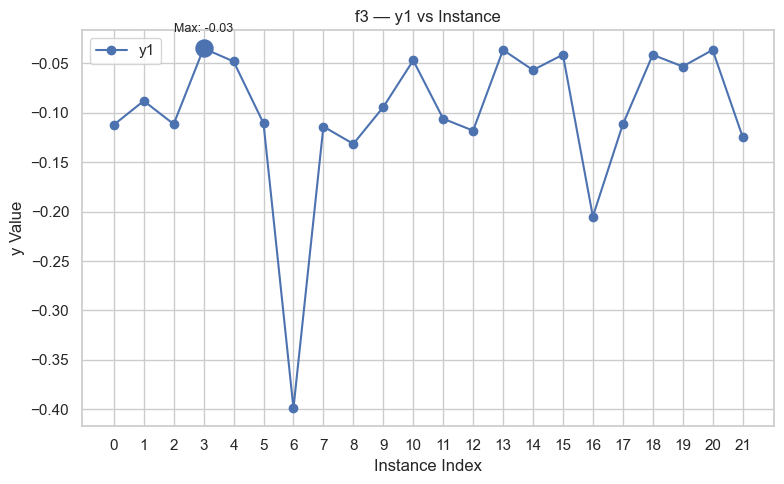


f4 — Full Data Table
          X1        X2        X3        X4         y1
0   0.896981  0.725628  0.175404  0.701694 -22.108288
1   0.889356  0.499588  0.539269  0.508783 -14.601397
2   0.250946  0.033693  0.145380  0.494932 -11.699932
3   0.346962  0.006250  0.760564  0.613024 -16.053765
4   0.124871  0.129770  0.384400  0.287076 -10.069633
5   0.801303  0.500231  0.706645  0.195103 -15.487083
6   0.247708  0.060445  0.042186  0.441324 -12.681685
7   0.746702  0.757092  0.369353  0.206566 -16.026400
8   0.400665  0.072574  0.886768  0.243842 -17.049235
9   0.626071  0.586751  0.438806  0.778858 -12.741766
10  0.957135  0.597644  0.766114  0.776210 -27.316396
11  0.732812  0.145250  0.476813  0.133366 -13.527649
12  0.655115  0.072392  0.687152  0.081517 -16.679115
13  0.219734  0.832031  0.482864  0.082569 -16.507159
14  0.488594  0.211965  0.939178  0.376192 -17.817999
15  0.167130  0.876555  0.217240  0.959801 -26.561821
16  0.216911  0.166086  0.241372  0.770062 -12.758324
17  0.

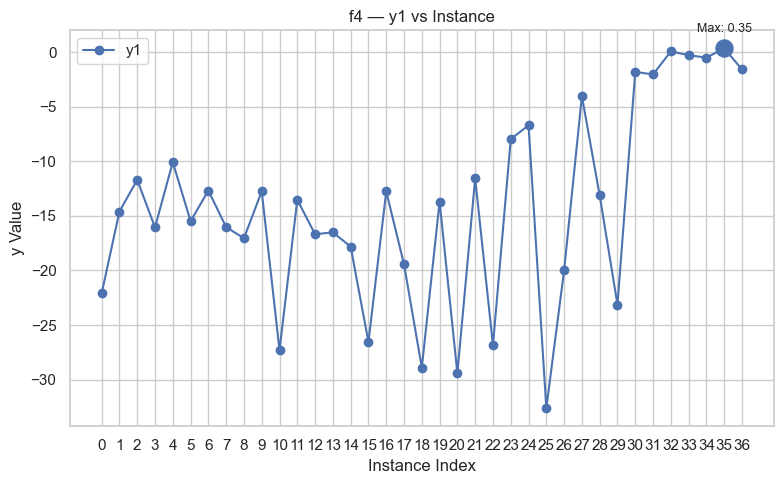


f5 — Full Data Table
          X1        X2        X3        X4           y1
0   0.191447  0.038193  0.607418  0.414584    64.443440
1   0.758653  0.536518  0.656000  0.360342    18.301380
2   0.438350  0.804340  0.210245  0.151295     0.112940
3   0.706051  0.534192  0.264243  0.482088     4.210898
4   0.836478  0.193610  0.663893  0.785649   258.370525
5   0.683432  0.118663  0.829046  0.567577    78.434389
6   0.553621  0.667350  0.323806  0.814870    57.571537
7   0.352356  0.322242  0.116979  0.473113   109.571876
8   0.153786  0.729382  0.422598  0.443074     8.847992
9   0.463442  0.630025  0.107906  0.957644   233.223610
10  0.677491  0.358510  0.479592  0.072880    24.423088
11  0.583973  0.147243  0.348097  0.428615    64.420147
12  0.306889  0.316878  0.622634  0.095399    63.476716
13  0.511142  0.817957  0.728710  0.112354    79.729130
14  0.438933  0.774092  0.378167  0.933696   355.806818
15  0.224189  0.846480  0.879484  0.878516  1088.859618
16  0.725262  0.479870  0.

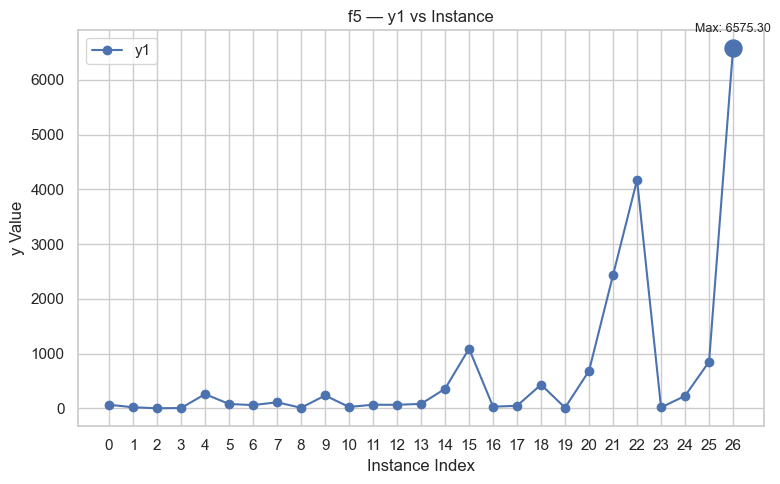


f6 — Full Data Table
          X1        X2        X3        X4        X5        y1
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
1   0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955
2   0.729523  0.748106  0.679775  0.356552  0.671054 -1.672200
3   0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058
4   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
5   0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049
6   0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786
7   0.945069  0.288459  0.978806  0.961656  0.598016 -1.694343
8   0.125720  0.862725  0.028544  0.246605  0.751206 -2.571170
9   0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116
10  0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785
11  0.957740  0.235669  0.099146  0.156806  0.071317 -1.912677
12  0.629308  0.803484  0.811408  0.045613  0.110624 -1.622839
13  0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682
14  0.439344  0.698924  0.426820 

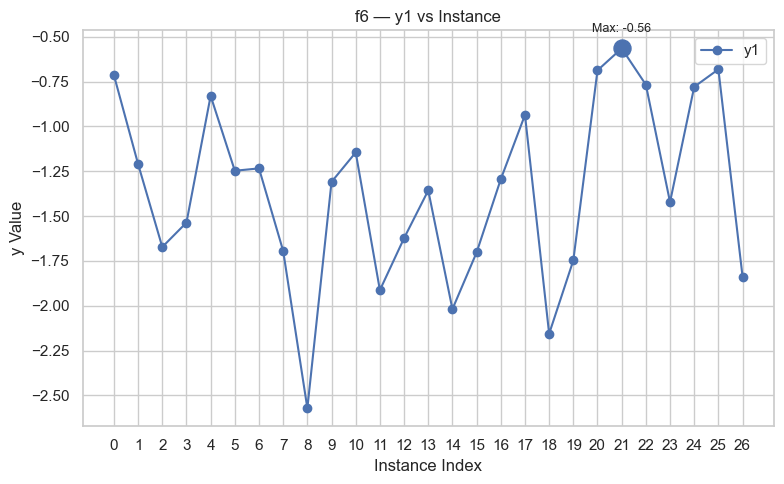


f7 — Full Data Table
          X1        X2        X3        X4        X5        X6        y1
0   0.272624  0.324495  0.897109  0.832951  0.154063  0.795864  0.604433
1   0.543003  0.924694  0.341567  0.646486  0.718440  0.343133  0.562753
2   0.090832  0.661529  0.065931  0.258577  0.963453  0.640265  0.007503
3   0.118867  0.615055  0.905816  0.855300  0.413631  0.585236  0.061424
4   0.630218  0.838097  0.680013  0.731895  0.526737  0.348429  0.273047
5   0.764919  0.255883  0.609084  0.218079  0.322943  0.095794  0.083747
6   0.057896  0.491672  0.247422  0.218118  0.420428  0.730970  1.364968
7   0.195252  0.079227  0.554580  0.170567  0.014944  0.107032  0.092645
8   0.642303  0.836875  0.021793  0.101488  0.683071  0.692416  0.017870
9   0.789943  0.195545  0.575623  0.073659  0.259049  0.051100  0.033565
10  0.528497  0.457424  0.360096  0.362046  0.816891  0.637476  0.073516
11  0.722615  0.011813  0.063646  0.165173  0.079244  0.359952  0.206310
12  0.075665  0.334502  0.132

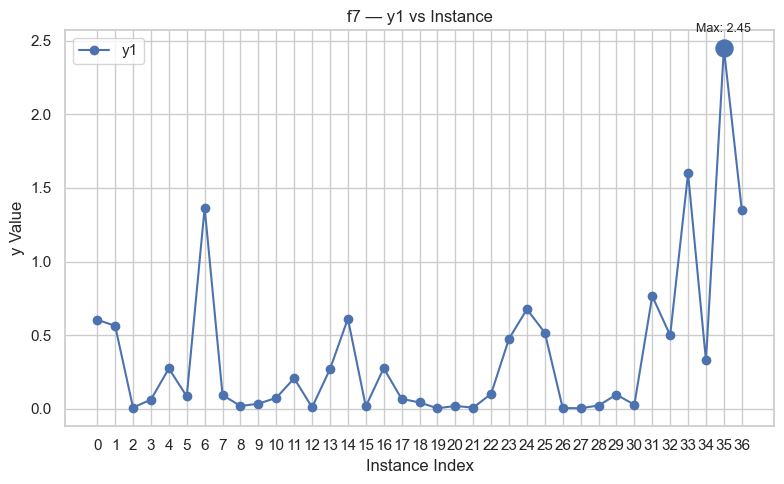


f8 — Full Data Table
          X1        X2        X3        X4        X5        X6        X7        X8        y1
0   0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311  0.734281  7.398721
1   0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384  0.107132  7.005227
2   0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415  0.367320  8.459482
3   0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827  0.292472  8.284008
4   0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295  0.593882  8.606117
5   0.778818  0.003419  0.337983  0.519528  0.820907  0.537247  0.551347  0.660032  8.541748
6   0.908649  0.062250  0.238260  0.766604  0.132336  0.990244  0.688068  0.742496  7.327435
7   0.586371  0.880736  0.745021  0.546035  0.009649  0.748992  0.230907  0.097916  7.299872
8   0.761137  0.854672  0.382124  0.337352  0.689708  0.309853  0.631380  0.041956  7.957875
9   0.984933  0.699506  0.998885  0.180148  0.58

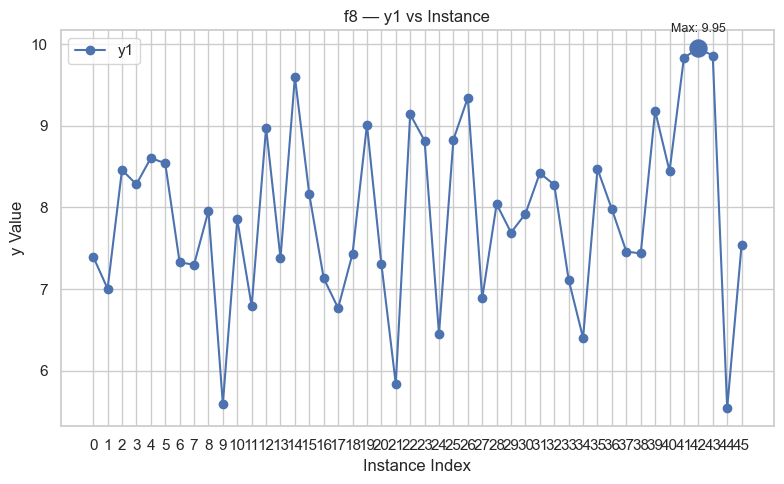

In [20]:
# Dictionary to store week labels for each DataFrame
week_labels_dict = {}
# Dictionary to track the next week number to assign
next_week_counter = {}

for name, df in functions_data.items():
    print(f"\n{name} — Full Data Table")
    print(df.to_string())
    print(f"\n{name} — y vs Instance Plot")
    
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    
    for col in output_cols:
        plt.figure(figsize=(8, 5))
        x = df.index
        y = df[col]
        plt.plot(x, y, marker='o', label=col)
        
        # Highlight maximum y
        max_idx = y.idxmax()
        max_val = y.max()
        plt.scatter(max_idx, max_val, s=150, zorder=5)
        plt.annotate(
            f"Max: {max_val:.2f}",
            (max_idx, max_val),
            textcoords="offset points",
            xytext=(0, 12),
            ha='center',
            fontsize=9
        )
        
        
        plt.xticks(x)
        plt.title(f"{name} — {col} vs Instance")
        plt.xlabel("Instance Index")
        plt.ylabel("y Value")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()



#### f1 | Sobol Sampling with Multi-Start L-BFGS-B log transformed heteroscedastic GP HPT

In [21]:
import numpy as np
from scipy.stats.qmc import Sobol
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

In [22]:
# Extract existing data for Function 1
df = functions_data["f1"]

# Separate inputs (X) and outputs (y)
X_train_1 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_1 = df["y1"].values
print(X_train_1)
print(y_train_1)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.7936     0.666269  ]
 [0.800601   0.0028    ]
 [0.729726   0.729276  ]
 [0.732162   0.364472  ]
 [0.81265    0.143347  ]
 [0.079265   0.909848  ]
 [0.525569   0.987823  ]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.40349865e-021  9.06910879e-223
  5.31459276e-015  5.47377612e-057 -1.06293312e-161  2.60788262e-248
  2.23603281e-098]


In [23]:
# ml method: gaussian process regression with matern kernel on log transformed outputs
# objective: propose the next evaluation point for an expensive 2d black box function
# rationale: log transform makes tiny outputs visible, gp models them, ucb drives exploration

log_shift = 1e-12   # log shift epsilon hyperparameter
dim = 2             # f1 has 2 input dimensions
n_sobol = 3000      # number of sobol candidates
min_dist_guard = 0.05  # minimum distance between new point and existing points
ucb_beta = 2.0      # ucb beta hyperparameter
n_restarts_lbfgs = 20  # number of l bfgs b restarts for gp hyperparameters


def log_warp(y, shift=log_shift):
    """
    log transform component: implements hebo style output warping y' = log(y + shift)
    this makes very small positive outputs spread out on a log scale
    it helps the gaussian process see differences that are invisible in raw space
    """
    # ensure numerical safety by clipping very small values before adding shift
    y_safe = np.maximum(y, 1e-300)
    return np.log(y_safe + shift)


def generate_sobol_candidates(n, d, seed=0):
    """
    candidate generation component: sobol sequence over [0, 1]^d
    sobol points cover the 2d space more evenly than pure random sampling
    this supports global exploration
    """
    sampler = Sobol(d=d, scramble=True, seed=seed)
    return sampler.random(n)


def min_dist_to_obs(x, x_obs):
    """
    distance guard component: compute minimum euclidean distance from x to observed points
    this is used to avoid proposing points that are too close to existing evaluations
    """
    return np.sqrt(((x_obs - x) ** 2).sum(axis=1)).min()


def fit_log_gp(x_train_1, y_train_1):
    """
    ml model component: fit a gaussian process on log transformed outputs
    method: matern 2.5 kernel plus white noise, with l bfgs b hyperparameter tuning
    rationale: after log transform, the gp likelihood is smooth and gradients are reliable
    key assumptions: smoothness in log space and approximate gaussianity of transformed outputs
    """
    # apply log transform to outputs
    y_log = log_warp(y_train_1)

    # define matern kernel with separate length scales and white noise
    kernel = (
        Matern(
            length_scale=[1.0, 1.0],
            length_scale_bounds=[(0.05, 10.0), (0.05, 10.0)],
            nu=2.5,
        )
        + WhiteKernel(
            noise_level=1.0,
            noise_level_bounds=(1e-6, 5.0),
        )
    )

    # create gaussian process regressor with multi start l bfgs b
    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=n_restarts_lbfgs,
        normalize_y=True,
        random_state=0,
    )

    # fit gp on inputs and log transformed outputs
    gp.fit(x_train_1, y_log)

    # print fitted hyperparameters for inspection
    k = gp.kernel_
    print("log gp fitted")
    print(f"log marginal likelihood: {gp.log_marginal_likelihood_value_:.4f}")
    print(f"kernel: {k}")

    return gp, y_log


def compute_ucb_scores(gp, candidates):
    """
    exploration mechanism component: upper confidence bound in log space
    for each candidate, compute mean and standard deviation from the gp
    ucb score = mean + beta * standard deviation
    this encourages sampling where the model is uncertain and potentially high
    """
    mu_log, sigma_log = gp.predict(candidates, return_std=True)
    ucb_scores = mu_log + ucb_beta * sigma_log
    return ucb_scores, mu_log, sigma_log


def propose_f1_query(x_train_1, y_train_1):
    """
    main strategy component: combine all parts to propose the next point
    steps:
      1. generate sobol candidates over the full domain
      2. apply distance guard to enforce exploration
      3. fit log transformed gaussian process
      4. compute ucb scores in log space
      5. select candidate with highest ucb score
    """
    # step 1: generate sobol candidates in [0, 1]^2
    candidates = generate_sobol_candidates(n_sobol, dim)

    # step 2: apply distance guard to avoid points too close to existing data
    valid_mask = np.array(
        [min_dist_to_obs(c, x_train_1) >= min_dist_guard for c in candidates]
    )
    candidates = candidates[valid_mask]
    print(f"valid candidates after distance guard: {len(candidates)}")

    # step 3: fit gaussian process on log transformed outputs
    gp, y_log = fit_log_gp(x_train_1, y_train_1)

    # step 4: compute ucb scores for all candidates
    ucb_scores, mu_log, sigma_log = compute_ucb_scores(gp, candidates)

    # step 5: select candidate with highest ucb score
    best_idx = np.argmax(ucb_scores)
    next_x = candidates[best_idx]

    # back transform mean prediction for reporting in original scale
    pred_log_mean = mu_log[best_idx]
    pred_original = np.exp(pred_log_mean) - log_shift

    # print diagnostic information
    print("\nselected candidate for f1:")
    print(f"next_x: {next_x}")
    print(f"log space mean at next_x: {pred_log_mean:.6f}")
    print(f"log space sigma at next_x: {sigma_log[best_idx]:.6f}")
    print(f"approx predicted original scale: {pred_original:.4e}")
    print(f"current best y (original): {np.max(y_train_1):.4e}")
    print(f"current best y (log): {np.max(y_log):.6f}")

    return next_x, gp, y_log

next_x = propose_f1_query(X_train_1, y_train_1)


valid candidates after distance guard: 2648
log gp fitted
log marginal likelihood: -25.5639
kernel: Matern(length_scale=[10, 10], nu=2.5) + WhiteKernel(noise_level=1.06)

selected candidate for f1:
next_x: [0.9949023 0.9942216]
log space mean at next_x: -27.630650
log space sigma at next_x: 0.001324
approx predicted original scale: 3.7085e-16
current best y (original): 5.3146e-15
current best y (log): -27.625721


#### f2 | yeo johnson input warping, Sobol with Multi-Start L-BFGS-B ARD-GP HPT

In [24]:
# Extract existing data for Function 2
df = functions_data["f2"]

# Separate inputs (X) and outputs (y)
X_train_2 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_2 = df["y1"].values
print(X_train_2)
print(y_train_2)

[[6.65799580e-01 1.23969128e-01]
 [8.77790989e-01 7.78627501e-01]
 [1.42699074e-01 3.49005131e-01]
 [8.45275429e-01 7.11120267e-01]
 [4.54647141e-01 2.90455180e-01]
 [5.77712844e-01 7.71973184e-01]
 [4.38166062e-01 6.85018257e-01]
 [3.41749593e-01 2.86977198e-02]
 [3.38648157e-01 2.13867246e-01]
 [7.02636557e-01 9.26564198e-01]
 [5.54975000e-01 9.99446000e-01]
 [9.99500000e-01 1.80000000e-03]
 [7.27681000e-01 1.87140000e-01]
 [7.15483000e-01 5.63901000e-01]
 [6.78746000e-01 8.50809000e-01]
 [6.53993000e-01 9.81188000e-01]
 [1.28000000e-04 3.46419000e-01]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522 -0.07640834 -0.07975546
  0.50370322  0.56616625  0.68245235  0.37981981  0.00594097]


In [25]:
from sklearn.preprocessing import PowerTransformer

In [26]:
# ml method: gaussian process regression with ard matern kernel
# objective: propose the next evaluation point for an expensive 2d black box function
# rationale: yeo johnson warp x1, use anisotropic gp, and ucb to drive exploration
# x_train_2: numpy array of shape (n_samples, 2)
# y_train_2: numpy array of shape (n_samples,)

dim = 2
n_sobol = 5000
min_dist_guard = 0.05
ucb_beta = 2.0
x1_filter_threshold = 0.70
n_restarts_lbfgs = 20


def yeo_johnson_transform_x1(x_train_2, x_candidates):
    """
    input warping component: fit yeo johnson on observed x1 and transform x1
    this makes x1 more symmetric and closer to gaussian, which helps gp modelling
    only x1 is warped because it is assumed to be the dominant driver
    """
    pt = PowerTransformer(method="yeo-johnson", standardize=True)

    # extract x1 from observed data and fit transformer
    x1_obs = x_train_2[:, 0:1]
    pt.fit(x1_obs)

    # transform x1 in observed data
    x_train_t = x_train_2.copy()
    x_train_t[:, 0] = pt.transform(x1_obs).ravel()

    # transform x1 in candidate data
    x_cand_t = x_candidates.copy()
    x_cand_t[:, 0] = pt.transform(x_candidates[:, 0:1]).ravel()

    print(f"yeo johnson fitted on x1, lambda: {pt.lambdas_[0]:.4f}")
    return x_train_t, x_cand_t


def fit_ard_gp(x_train_t, y_train_2):
    """
    ml model component: fit ard matern 2.5 gaussian process
    x1 has shorter length scale bounds, x2 has longer bounds
    this encodes the assumption that x1 is more important than x2
    l bfgs b with multiple restarts tunes the hyperparameters
    """
    kernel = (
        Matern(
            length_scale=[0.5, 2.0],
            length_scale_bounds=[(0.05, 3.0), (0.20, 10.0)],
            nu=2.5,
        )
        + WhiteKernel(
            noise_level=1e-3,
            noise_level_bounds=(1e-6, 0.5),
        )
    )

    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=n_restarts_lbfgs,
        normalize_y=True,
        random_state=0,
    )

    gp.fit(x_train_t, y_train_2)

    # print fitted kernel and marginal likelihood for inspection
    print("ard gp fitted")
    print(f"log marginal likelihood: {gp.log_marginal_likelihood_value_:.4f}")
    print(f"kernel: {gp.kernel_}")

    return gp


def min_dist_to_obs(x, x_train_2):
    """
    distance guard component: compute minimum distance from x to observed points
    this is used to avoid proposing points that are too close to existing evaluations
    """
    return np.sqrt(((x_train_2 - x) ** 2).sum(axis=1)).min()


def propose_f2_query(x_train_2, y_train_2):
    """
    main strategy component: propose the next point for f2 like function
    steps:
      1. generate sobol candidates over [0, 1]^2
      2. apply directional filter x1 > threshold
      3. apply distance guard
      4. yeo johnson warp x1 in observed and candidate data
      5. fit ard gp on warped inputs
      6. compute ucb scores and select best candidate
    """
    # step 1: generate sobol candidates
    sampler = Sobol(d=dim, scramble=True, seed=0)
    cands_raw = sampler.random(n_sobol)

    # step 2: directional filter to focus on high x1 region
    cands_filtered = cands_raw[cands_raw[:, 0] > x1_filter_threshold]
    print(f"candidates after x1 > {x1_filter_threshold} filter: {len(cands_filtered)}")

    # step 3: apply distance guard to enforce exploration
    valid_mask = np.array(
        [min_dist_to_obs(c, x_train_2) >= min_dist_guard for c in cands_filtered]
    )
    candidates = cands_filtered[valid_mask]
    print(f"candidates after distance guard: {len(candidates)}")

    # step 4: yeo johnson warp x1 in observed and candidate data
    x_train_t, cands_t = yeo_johnson_transform_x1(x_train_2, candidates)

    # step 5: fit ard gaussian process on warped inputs
    gp = fit_ard_gp(x_train_t, y_train_2)

    # step 6: compute ucb scores for all candidates
    mu, sigma = gp.predict(cands_t, return_std=True)
    ucb_scores = mu + ucb_beta * sigma

    # select candidate with highest ucb score
    best_idx = np.argmax(ucb_scores)
    next_x = candidates[best_idx]

    # print diagnostic information
    print("\nselected candidate for f2:")
    print(f"next_x (raw space): {next_x}")
    print(f"x1: {next_x[0]:.4f}, x2: {next_x[1]:.4f}")
    print(f"gp mean at next_x: {mu[best_idx]:.6f}")
    print(f"gp sigma at next_x: {sigma[best_idx]:.6f}")
    print(f"ucb score at next_x: {ucb_scores[best_idx]:.6f}")
    print(f"current best y: {np.max(y_train_2):.6f}")

    return next_x, gp
    
np.set_printoptions(suppress=True, precision=10)
next_x = propose_f2_query(X_train_2, y_train_2)


candidates after x1 > 0.7 filter: 1499
candidates after distance guard: 1318
yeo johnson fitted on x1, lambda: 2.2762
ard gp fitted
log marginal likelihood: -13.2174
kernel: Matern(length_scale=[0.238, 10], nu=2.5) + WhiteKernel(noise_level=0.00889)

selected candidate for f2:
next_x (raw space): [0.9203046672 0.0400615111]
x1: 0.9203, x2: 0.0401
gp mean at next_x: 0.318068
gp sigma at next_x: 0.206856
ucb score at next_x: 0.731780
current best y: 0.682452


#### f3 | Voronoi Adaptive Space-Filling + Multi-Bandwidth KNN Ensemble + GP-EI

In [27]:
# Extract existing data for Function 2
df = functions_data["f3"]

# Separate inputs (X) and outputs (y)
X_train_3 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_3 = df["y1"].values
print(X_train_3)
print(y_train_3)

[[0.1715252069 0.3439168703 0.2487372011]
 [0.2421144606 0.6440742698 0.2724328092]
 [0.5349057202 0.3985009154 0.1733887289]
 [0.4925814146 0.6115931883 0.340176386 ]
 [0.1346216663 0.2199172405 0.4582062196]
 [0.3455232705 0.9413598306 0.2693634791]
 [0.1518366324 0.439990619  0.9908818666]
 [0.6455028352 0.3971429396 0.9197713377]
 [0.7469119452 0.2841963092 0.2262998549]
 [0.170476994  0.6970324007 0.1491694337]
 [0.2205493371 0.2978252442 0.3435553444]
 [0.6660136588 0.6719851513 0.2462952967]
 [0.0468089497 0.2313602408 0.7706175922]
 [0.6000972824 0.7251357252 0.0660886415]
 [0.9659948489 0.8611196897 0.5668291313]
 [0.389233     0.386084     0.558916    ]
 [0.9672       0.0292       0.7233      ]
 [0.437962     0.715305     0.000876    ]
 [0.387933     0.40524      0.580181    ]
 [0.688252     0.924125     0.842251    ]
 [0.788392     0.913423     0.40309     ]
 [0.110343     0.915465     0.655916    ]]
[-0.1121222005 -0.0879628602 -0.1114146543 -0.0348353134 -0.0480075844
 -0.

In [28]:
from scipy.stats import boxcox
from scipy.stats import norm
from sklearn.neighbors import KNeighborsRegressor as KNN
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error

In [29]:
# ml method: voronoi space filling + multi bandwidth knn + gp expected improvement
# objective: propose the next evaluation point for an expensive 3d black box function
# rationale: improve coverage while using simple models to guide improvement
# x_train_3: numpy array of shape (n_samples, 3)
# y_train_3: numpy array of shape (n_samples,)

dim = 3
x1_idx = 0
n_sobol = 12000
voronoi_top_pct = 0.40
min_dist_guard = 0.05
ei_xi = 0.001
knn_ks = [3, 5, 7]
alpha_space = 0.40
alpha_knn = 0.35
alpha_ei = 0.25


def box_cox_transform_y(y_train_3):
    # shift y to be positive and apply box cox transform
    shift = -y_train_3.min() + 0.01
    y_bc, lam = boxcox(y_train_3 + shift)
    return y_bc, lam, shift


def maximin_distances(candidates, x_obs):
    # compute minimum distance from each candidate to all observed points
    diff = candidates[:, None, :] - x_obs[None, :, :]
    dists = np.sqrt((diff ** 2).sum(axis=2))
    return dists.min(axis=1)


def apply_min_dist_guard(candidates, x_obs, threshold):
    # remove candidates too close to existing observations
    min_dists = maximin_distances(candidates, x_obs)
    mask = min_dists >= threshold
    return candidates[mask], min_dists[mask]


def loo_cv_mse(model_class, model_kwargs, x, y):
    # leave one out cross validation for knn bandwidth weighting
    loo = LeaveOneOut()
    preds = []
    for train_idx, test_idx in loo.split(x):
        model = model_class(**model_kwargs)
        model.fit(x[train_idx], y[train_idx])
        preds.append(model.predict(x[test_idx])[0])
    return mean_squared_error(y, preds)


def build_multi_bandwidth_knn(x, y, ks):
    # fit knn models with different bandwidths and compute weights
    models = []
    mses = []
    for k in ks:
        k_safe = min(k, len(x) - 1)
        mse = loo_cv_mse(
            KNN,
            {"n_neighbors": k_safe, "weights": "distance", "metric": "euclidean"},
            x, y,
        )
        model = KNN(
            n_neighbors=k_safe, weights="distance", metric="euclidean"
        )
        model.fit(x, y)
        models.append(model)
        mses.append(mse)
    inv_mses = 1.0 / (np.array(mses) + 1e-10)
    weights = inv_mses / inv_mses.sum()
    return models, weights


def predict_multi_knn(models, weights, candidates):
    # weighted knn ensemble prediction
    mu = np.zeros(len(candidates))
    for model, w in zip(models, weights):
        mu += w * model.predict(candidates)
    return mu


def fit_gp_for_ei(x, y_bc):
    # fit gaussian process on box cox transformed y for uncertainty
    kernel = (
        Matern(
            length_scale=[1.0] * dim,
            length_scale_bounds=[(0.01, 10.0)] * dim,
            nu=2.5,
        )
        + WhiteKernel(
            noise_level=1e-3,
            noise_level_bounds=(1e-8, 1.0),
        )
    )
    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=10,
        normalize_y=True,
    )
    gp.fit(x, y_bc)
    return gp


def expected_improvement(mu, sigma, best_y, xi):
    # compute expected improvement
    improvement = mu - best_y - xi
    z = improvement / (sigma + 1e-9)
    ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma <= 0.0] = 0.0
    return ei


def propose_f3_query(x_train_3, y_train_3):
    # step 1: box cox transform
    y_bc, lam, shift = box_cox_transform_y(y_train_3)

    # step 2: sobol candidates and distance guard
    sampler = Sobol(d=dim, scramble=True, seed=0)
    cands_raw = sampler.random(n_sobol)
    cands, min_dists = apply_min_dist_guard(cands_raw, x_train_3, min_dist_guard)

    # step 3: voronoi maximin pre filter in reduced 3d space
    active_dims = [d for d in range(dim) if d != x1_idx]
    min_dists_3d = maximin_distances(cands[:, active_dims], x_train_3[:, active_dims])
    n_keep = max(int(len(cands) * voronoi_top_pct), 200)
    top_indices = np.argsort(min_dists_3d)[-n_keep:]
    cands_filtered = cands[top_indices]
    min_dists_filtered = min_dists_3d[top_indices]

    # step 4: multi bandwidth knn ensemble
    knn_models, knn_weights = build_multi_bandwidth_knn(x_train_3, y_train_3, knn_ks)
    mu_knn = predict_multi_knn(knn_models, knn_weights, cands_filtered)

    # step 5: gaussian process for uncertainty
    gp = fit_gp_for_ei(x_train_3, y_bc)
    _, sigma_gp = gp.predict(cands_filtered, return_std=True)

    # step 6: compute scores and hybrid acquisition
    space_score = (min_dists_filtered - min_dists_filtered.min()) / (
        min_dists_filtered.max() - min_dists_filtered.min() + 1e-10
    )
    knn_score = (mu_knn - mu_knn.min()) / (
        mu_knn.max() - mu_knn.min() + 1e-10
    )
    ei_raw = expected_improvement(mu_knn, sigma_gp, y_train_3.max(), ei_xi)
    ei_score = (ei_raw - ei_raw.min()) / (
        ei_raw.max() - ei_raw.min() + 1e-10
    )

    hybrid = (
        alpha_space * space_score
        + alpha_knn * knn_score
        + alpha_ei * ei_score
    )
    best_idx = np.argmax(hybrid)
    next_x = cands_filtered[best_idx]
    
        # print summary header
    print("f3 week 8: voronoi space filling + multi bandwidth knn + gp ei")
    print(f"number of observations: {len(x_train_3)}")
    print(f"dimension: {dim}")
    print(f"n/d ratio: {len(x_train_3) / dim:.2f}")
    print(f"current best y: {y_train_3.max():.6f}")

    # print box cox info
    print("\nbox cox transform")
    print(f"  lambda: {lam:.4f}")
    print(f"  shift: {shift:.6f}")

    # print sobol pool info
    print("\nsobol candidate generation")
    print(f"  initial pool: {n_sobol}")
    print(f"  after min distance guard: {len(cands)}")

    # print voronoi info
    print("\nvoronoi maximin pre filter")
    print(f"  kept top {voronoi_top_pct * 100:.0f} percent")
    print(f"  candidates after filter: {len(cands_filtered)}")
    print(f"  min distance range: {min_dists_filtered.min():.4f} to {min_dists_filtered.max():.4f}")

    # print knn info
    print("\nmulti bandwidth knn ensemble")
    for k, w in zip(knn_ks, knn_weights):
        print(f"  knn k={k} weight={w:.4f}")

    # print gp info
    print("\ngaussian process for uncertainty")
    print(f"  gp kernel: {gp.kernel_}")
    print(f"  gp log marginal likelihood: {gp.log_marginal_likelihood_value_:.4f}")

    # print selected point
    print("\nselected next point")
    print(f"  x: {next_x}")
    print(f"  x1={next_x[0]:.4f}, x2={next_x[1]:.4f}, x3={next_x[2]:.4f}")
    print(f"  min distance to observations: {min_dists_filtered[best_idx]:.4f}")
    print(f"  knn mean: {mu_knn[best_idx]:.6f}")
    print(f"  gp sigma: {sigma_gp[best_idx]:.6f}")
    print(f"  ei raw: {ei_raw[best_idx]:.8f}")

    # print coverage diagnostics
    print("\ncoverage diagnostics")
    print(f"  selected point in unexplored region: {min_dists_filtered[best_idx] > 0.15}")
    print(f"  dominant knn bandwidth: k={knn_ks[np.argmax(knn_weights)]}")


    return next_x, knn_models, knn_weights, gp


next_x = propose_f3_query(X_train_3, y_train_3)

f3 week 8: voronoi space filling + multi bandwidth knn + gp ei
number of observations: 22
dimension: 3
n/d ratio: 7.33
current best y: -0.034835

box cox transform
  lambda: 2.2411
  shift: 0.408926

sobol candidate generation
  initial pool: 12000
  after min distance guard: 11883

voronoi maximin pre filter
  kept top 40 percent
  candidates after filter: 4753
  min distance range: 0.1276 to 0.3594

multi bandwidth knn ensemble
  knn k=3 weight=0.3260
  knn k=5 weight=0.3354
  knn k=7 weight=0.3386

gaussian process for uncertainty
  gp kernel: Matern(length_scale=[6.81, 10, 0.0744], nu=2.5) + WhiteKernel(noise_level=0.0406)
  gp log marginal likelihood: -22.4273

selected next point
  x: [0.394618406  0.0037790099 0.0015148688]
  x1=0.3946, x2=0.0038, x3=0.0015
  min distance to observations: 0.3594
  knn mean: -0.087104
  gp sigma: 0.003641
  ei raw: 0.00000000

coverage diagnostics
  selected point in unexplored region: True
  dominant knn bandwidth: k=7


#### f4 | Sobol Sampling with ARD-GP + L-BFGS-B HPT for 4D Space

In [30]:
# Extract existing data for Function 2
df = functions_data["f4"]

# Separate inputs (X) and outputs (y)
X_train_4 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_4 = df["y1"].values
print(X_train_4)
print(y_train_4)

[[0.8969810544 0.7256279703 0.1754043089 0.7016943694]
 [0.8893563957 0.4995878554 0.5392688578 0.5087834391]
 [0.2509462428 0.0336931305 0.1453800247 0.4949324206]
 [0.3469620609 0.0062504002 0.7605636064 0.6130235572]
 [0.1248711812 0.1297701931 0.384400483  0.2870761011]
 [0.8013027073 0.5002310937 0.70664456   0.195102841 ]
 [0.2477082619 0.0604454273 0.0421863451 0.4413242505]
 [0.7467022421 0.7570915044 0.3693530596 0.206566281 ]
 [0.4006650272 0.0725742511 0.8867682538 0.2438422898]
 [0.6260705962 0.5867512593 0.4388057822 0.7788576938]
 [0.9571352931 0.597644383  0.7661138516 0.7762099053]
 [0.732812426  0.145249979  0.4768127176 0.133365734 ]
 [0.6551154792 0.0723918269 0.6871517458 0.0815165642]
 [0.2197344292 0.8320313351 0.4828641625 0.0825692306]
 [0.4885941895 0.2119650956 0.9391779074 0.3761917259]
 [0.1671304856 0.8765545583 0.217239545  0.9598009846]
 [0.2169111881 0.166085829  0.2413722564 0.7700624757]
 [0.3874878367 0.8045322582 0.7517954828 0.7238274385]
 [0.985621

In [31]:
from scipy.optimize import minimize

In [32]:
# ml method: clean matern gaussian process with ucb acquisition
# objective: choose the next point for an expensive 4d black box function
# x_train_4: numpy array of shape (n_samples, dim)
# y_train_4: numpy array of shape (n_samples,)
dim = 4
n_sobol = 10000
n_acq_restarts = 40
n_gp_restarts = 20
beta = 3.5
min_dist = 0.05


def fit_gp(x_train_4, y_train_4):
    # fit a gaussian process with matern 2.5 kernel and white noise
    dim = x_train_4.shape[1]
    kernel = (
        Matern(
            length_scale=[1.0] * dim,
            length_scale_bounds=[(0.05, 10.0)] * dim,
            nu=2.5,
        )
        + WhiteKernel(
            noise_level=1e-3,
            noise_level_bounds=(1e-6, 0.5),
        )
    )
    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=n_gp_restarts,
        normalize_y=True,
        random_state=0,
    )
    gp.fit(x_train_4, y_train_4)
    return gp


def neg_ucb(x_flat, gp, beta):
    # negative ucb so we can minimise with scipy
    x = x_flat.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    return -(mu[0] + beta * sigma[0])


def min_dist_to_obs(x, x_train_4):
    # compute minimum distance from x to all observed points
    return np.sqrt(((x_train_4 - x) ** 2).sum(axis=1)).min()

def propose_f4_query(x_train_4, y_train_4):
    """
    main function that selects the next point to evaluate.
    steps:
      1. fit gp
      2. optimise ucb with many restarts
      3. evaluate ucb on a sobol pool
      4. choose the best point that passes the distance guard
    """
    dim = x_train_4.shape[1]

    # step 1: fit gp
    gp = fit_gp(x_train_4, y_train_4)

    # step 2: gradient based search on ucb
    bounds = [(0.0, 1.0)] * dim
    rng = np.random.default_rng(0)
    best_ucb_grad = -np.inf
    best_x_grad = None

    for i in range(n_acq_restarts):
        x0 = rng.random(dim)
        res = minimize(
            neg_ucb,
            x0,
            args=(gp, beta),
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 300, "ftol": 1e-10}
        )
        ucb_val = -res.fun
        if ucb_val > best_ucb_grad:
            best_ucb_grad = ucb_val
            best_x_grad = np.clip(res.x, 0.0, 1.0)

    # step 3: sobol pool as safety net
    sampler = Sobol(d=dim, scramble=True, seed=1)
    cands = sampler.random(n_sobol)

    valid_mask = np.array(
        [min_dist_to_obs(c, x_train_4) >= min_dist for c in cands]
    )
    cands = cands[valid_mask]

    mu_pool, sigma_pool = gp.predict(cands, return_std=True)
    ucb_pool = mu_pool + beta * sigma_pool

    best_pool_idx = np.argmax(ucb_pool)
    best_x_pool = cands[best_pool_idx]
    best_ucb_pool = ucb_pool[best_pool_idx]

    # step 4: choose between gradient optimum and pool optimum
    if (
        best_x_grad is not None
        and min_dist_to_obs(best_x_grad, x_train_4) >= min_dist
        and best_ucb_grad >= best_ucb_pool
    ):
        next_x = best_x_grad
        ucb_final = best_ucb_grad
    else:
        next_x = best_x_pool
        ucb_final = best_ucb_pool

    # compute gp mean and sigma for reporting
    mu_p, sigma_p = gp.predict(next_x.reshape(1, -1), return_std=True)

    # print results
    print(f"selected point: {next_x}")
    print(f"gp mean prediction: {mu_p[0]:.6f}")
    print(f"gp uncertainty (sigma): {sigma_p[0]:.6f}")
    print(f"ucb score at selected point: {ucb_final:.6f}")
    print(f"current best observed value: {y_train_4.max():.6f}")

    return next_x, gp, mu_p[0], sigma_p[0]


next_x = propose_f4_query(X_train_4, y_train_4)

selected point: [0.4132265877 0.4089263026 0.3837571082 0.4717379009]
gp mean prediction: -0.021558
gp uncertainty (sigma): 0.568942
ucb score at selected point: 1.969738
current best observed value: 0.346551


#### f5 | Log Transformed ARD-GP with EI around X3 Region and distance guards

In [33]:
# Extract existing data for Function 5
df = functions_data["f5"]

# Separate inputs (X) and outputs (y)
X_train_5 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_5 = df["y1"].values
print(X_train_5)
print(y_train_5)

[[0.1914470845 0.0381933714 0.6074178109 0.414584137 ]
 [0.7586529492 0.5365177381 0.6560003817 0.360341553 ]
 [0.4383498727 0.8043397048 0.2102452664 0.1512948161]
 [0.7060508341 0.5341919612 0.2642433452 0.482087549 ]
 [0.836477993  0.1936096469 0.663892697  0.7856488829]
 [0.6834322499 0.1186626418 0.8290459097 0.5675766059]
 [0.5536214795 0.6673499787 0.3238058192 0.8148697537]
 [0.3523562695 0.322241532  0.1169793676 0.4731125216]
 [0.1537857059 0.7293816904 0.4225984367 0.4430741656]
 [0.4634422674 0.6300245101 0.1079064558 0.9576438987]
 [0.6774911484 0.3585095065 0.4795922245 0.0728804811]
 [0.5839734125 0.1472426462 0.3480974621 0.428614651 ]
 [0.3068887187 0.3168781266 0.6226344813 0.0953990581]
 [0.5111417749 0.8179569972 0.7287104181 0.1123536231]
 [0.4389333758 0.7740917617 0.3781670864 0.9336962068]
 [0.2241890233 0.8464804905 0.8794841797 0.8785156842]
 [0.7252617232 0.4798704863 0.0889468426 0.7597602201]
 [0.3554816095 0.6396193667 0.4176176789 0.1226038397]
 [0.119879

In [34]:
from scipy.stats import norm

In [35]:
# ml method name
# log transformed ard gaussian process with expected improvement acquisition
# objective of submission
# propose a new query point for a 5d expensive black box function using a gp model
# rationale behind the chosen ml method
# the log transform stabilises variance, and the ard gp can focus on the dominant x3 dimension
# key assumptions
# x3 is a dominant driver and the log transformed outputs are well modelled by a gp
# exploration mechanism
# candidates are concentrated near the x3 boundary and scored by expected improvement

# X_train_5 and y_train_5 must be provided by the user
# X_train_5: array of shape (n_samples, 5)
# y_train_5: array of shape (n_samples,)

x3_idx = 2          # index of x3 in the input
x3_lower = 0.90     # lower bound of the x3 strip
n_strip = 6000      # number of strip candidates
n_global = 2000     # number of global candidates
min_dist_guard = 0.04
xi = 0.001          # expected improvement parameter


def log_transform(y, shift=1.0):
    """
    apply a log transform to the outputs

    this reduces skew and makes the distribution more gaussian like
    """
    y_safe = np.maximum(y, 1e-6)
    return np.log(y_safe + shift)


def sobol_strip(d, n, x3_idx, x3_lower, seed=0):
    """
    generate sobol candidates with x3 restricted to [x3_lower, 1]

    this concentrates candidates near the x3 boundary where high values are expected
    """
    sampler = Sobol(d=d, scramble=True, seed=seed)
    pts = sampler.random(n)
    pts[:, x3_idx] = x3_lower + pts[:, x3_idx] * (1.0 - x3_lower)
    return np.clip(pts, 0.0, 1.0)


def sobol_global(d, n, seed=100):
    """
    generate global sobol candidates in the full unit cube

    this provides insurance against missing other high value regions
    """
    sampler = Sobol(d=d, scramble=True, seed=seed)
    return sampler.random(n)


def min_dist_to_obs(x, X_train_5):
    """
    compute the minimum l2 distance from x to any observed point

    this is used to avoid sampling points that are too close to existing data
    """
    dists = np.sqrt(((X_train_5 - x) ** 2).sum(axis=1))
    return dists.min()


def fit_log_gp_lbfgsb(X_train_5, y_train_5):
    """
    fit an ard matern gaussian process on log transformed outputs

    l bfgs b with multiple restarts is used to optimise length scales and noise
    """
    dim = X_train_5.shape[1]
    y_log = log_transform(y_train_5)

    # set length scale bounds
    # x3 gets tighter bounds because it is the dominant dimension
    ls_bounds = [(0.05, 15.0)] * dim
    ls_bounds[x3_idx] = (0.01, 3.0)

    kernel = (
        Matern(
            length_scale=[1.0] * dim,
            length_scale_bounds=ls_bounds,
            nu=2.5
        )
        + WhiteKernel(
            noise_level=1e-4,
            noise_level_bounds=(1e-8, 0.01)
        )
    )

    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=25,
        normalize_y=True,
        random_state=0
    )
    gp.fit(X_train_5, y_log)

    # print optimised length scales for inspection
    k = gp.kernel_
    params = k.get_params()
    ls_key = [kk for kk in params if "length_scale" in kk and "bounds" not in kk]
    if ls_key:
        ls = params[ls_key[0]]
        print("l bfgs b optimised ard length scales:")
        for d_i, l in enumerate(ls):
            marker = "<-- dominant" if d_i == x3_idx else ""
            print(f"  x{d_i + 1}: {float(l):.4f} {marker}")
    print(f"log marginal likelihood: {gp.log_marginal_likelihood_value_:.4f}")

    return gp, y_log


def ei_log(gp, candidates, best_y_log, xi=0.001):
    """
    compute expected improvement in log transformed space

    this measures the expected gain over the current best log value
    """
    mu, sigma = gp.predict(candidates, return_std=True)
    improvement = mu - best_y_log - xi
    z = improvement / (sigma + 1e-9)
    ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma <= 0.0] = 0.0
    return ei, mu, sigma


def propose_f5_query(X_train_5, y_train_5):
    """
    main function to propose the next query point for f5

    uses a log transformed ard gp and expected improvement over concentrated candidates
    """
    dim = X_train_5.shape[1]

    # generate strip and global candidates
    strip_pts = sobol_strip(dim, n_strip, x3_idx, x3_lower, seed=0)
    global_pts = sobol_global(dim, n_global, seed=100)
    candidates = np.vstack([strip_pts, global_pts])

    # apply minimum distance guard
    valid_mask = np.array(
        [min_dist_to_obs(c, X_train_5) >= min_dist_guard for c in candidates]
    )
    candidates = candidates[valid_mask]
    print(f"valid candidates: {len(candidates)}")
    if len(candidates) == 0:
        raise RuntimeError("no valid candidates after distance guard")

    frac_strip = (candidates[:, x3_idx] >= x3_lower).mean()
    print(f"fraction in x3 strip (x3 >= {x3_lower}): {frac_strip:.3f}")

    # fit log gp with l bfgs b hyperparameter tuning
    gp, y_log = fit_log_gp_lbfgsb(X_train_5, y_train_5)

    # compute expected improvement in log space
    best_y_log = np.max(y_log)
    ei_scores, mu_log, sigma_log = ei_log(gp, candidates, best_y_log, xi)

    # select best candidate
    best_idx = np.argmax(ei_scores)
    next_x = candidates[best_idx]
    mu_best = mu_log[best_idx]
    sigma_best = sigma_log[best_idx]
    predicted_original = np.exp(mu_best) - 1.0

    print("\nselected candidate for f5:")
    print(f"next_x: {next_x}")
    print(f"x3 value: {next_x[x3_idx]:.4f} (in strip: {next_x[x3_idx] >= x3_lower})")
    print(f"gp log mean at next_x: {mu_best:.4f}")
    print(f"gp log sigma at next_x: {sigma_best:.4f}")
    print(f"approx predicted original scale: {predicted_original:.1f}")
    print(f"ei score at next_x: {ei_scores[best_idx]:.8f}")

    return next_x, gp, y_log

next_x = propose_f5_query(X_train_5, y_train_5)

valid candidates: 7997
fraction in x3 strip (x3 >= 0.9): 0.775
l bfgs b optimised ard length scales:
  x1: 1.0493 
  x2: 0.3259 
  x3: 0.5558 <-- dominant
  x4: 0.4402 
log marginal likelihood: -27.8699

selected candidate for f5:
next_x: [0.7145392755 0.9528557658 0.9955862852 0.9960339777]
x3 value: 0.9956 (in strip: True)
gp log mean at next_x: 8.5376
gp log sigma at next_x: 0.6566
approx predicted original scale: 5102.2
ei score at next_x: 0.15408655


#### f6 | GP regression with ARD RBF kernel and portfolio acquisition

In [36]:
# Extract existing data for Function 2
df = functions_data["f6"]

# Separate inputs (X) and outputs (y)
X_train_6 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_6 = df["y1"].values
print(X_train_6)
print(y_train_6)

[[0.7281861047 0.1546925696 0.7325516687 0.6939965091 0.0564013105]
 [0.2423843472 0.8440999723 0.5778090988 0.6790212843 0.5019528879]
 [0.7295226101 0.7481062003 0.6797746409 0.3565522793 0.6710536835]
 [0.7706202417 0.1144037442 0.0467799319 0.6483242845 0.2735490527]
 [0.6188122987 0.3318021372 0.1872878678 0.756238474  0.3288347983]
 [0.7849580941 0.9106823491 0.7081201035 0.959225429  0.0049114959]
 [0.1451107857 0.8966845977 0.8963222346 0.7262715367 0.2362719909]
 [0.9450690681 0.2884590506 0.9788057636 0.961655587  0.5980159364]
 [0.125720155  0.8627246922 0.0285443322 0.2466052719 0.7512062409]
 [0.7575943554 0.3558314149 0.0165228997 0.434207205  0.1124330444]
 [0.5367969035 0.3087809072 0.4118792851 0.3882251767 0.5225283039]
 [0.9577396689 0.2356685723 0.0991458496 0.1568059339 0.0713173731]
 [0.6293078953 0.8034836781 0.811408439  0.0456131858 0.110624462 ]
 [0.0217353077 0.4280842403 0.8359394371 0.4894886594 0.5110817347]
 [0.4393442639 0.6989238329 0.4268202222 0.10947

In [37]:
from scipy.stats import norm, rankdata
from sklearn.gaussian_process.kernels import RBF

In [38]:
# gaussian process regression with ard rbf kernel and portfolio acquisition

dim = 5

# indices of active and inactive dimensions
active_dims = [1, 3, 4]    # example: x2, x4, x5 active
inactive_dims = [0, 2]     # example: x1, x3 inactive

# length scale settings
ls_active_init = 0.15
ls_active_bounds = (0.03, 0.45)
ls_inactive_init = 3.0
ls_inactive_bounds = (0.80, 20.0)

# noise settings
noise_init = 1e-4
noise_bounds = (1e-8, 0.005)

# acquisition parameters
beta_primary = 5.0
beta_secondary = 8.0
w_ucb1 = 0.50
w_ucb2 = 0.30
w_ei = 0.20
ei_xi = 0.001

# candidate pool and distance guard
n_restarts = 20
n_sobol = 20000
min_dist = 0.04


def build_kernel():
    """
    build an ard rbf kernel with different length scale bounds
    for active and inactive dimensions
    """
    ls_init = np.where(
        np.isin(np.arange(dim), active_dims),
        ls_active_init,
        ls_inactive_init
    )
    ls_bounds = [
        ls_active_bounds if d in active_dims else ls_inactive_bounds
        for d in range(dim)
    ]
    kernel = RBF(length_scale=ls_init, length_scale_bounds=ls_bounds)
    kernel += WhiteKernel(noise_level=noise_init, noise_level_bounds=noise_bounds)
    return kernel


def fit_gp(x_train_6, y_train_6, seed=0):
    """
    fit a gaussian process with the ard rbf kernel
    """
    kernel = build_kernel()
    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=n_restarts,
        normalize_y=True,
        random_state=seed
    )
    gp.fit(x_train_6, y_train_6)
    return gp


def copula_transform(y):
    """
    transform y into a gaussian copula space using ranks
    """
    n = len(y)
    ranks = rankdata(y) / (n + 1.0)
    return norm.ppf(ranks)


def compute_ei(mu, sigma, best_value, xi=ei_xi):
    """
    compute expected improvement given mean, sigma, and best value
    """
    improvement = mu - best_value - xi
    z = improvement / (sigma + 1e-9)
    ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma <= 1e-9] = 0.0
    return ei


def normalise(arr):
    """
    normalise an array to the range [0, 1]
    """
    rng = arr.max() - arr.min()
    return (arr - arr.min()) / (rng + 1e-12)


def min_distances(cands, x_obs):
    """
    compute minimum distance from each candidate to the observed points
    """
    diff = cands[:, None, :] - x_obs[None, :, :]
    dists = np.sqrt((diff ** 2).sum(axis=2))
    return dists.min(axis=1)


def propose_f6_query(x_train_6, y_train_6):
    """
    main function to select the next query point for f6
    it uses a portfolio of two ucb acquisitions and one copula ei acquisition
    """
    # generate sobol candidate pool
    sampler = Sobol(d=dim, scramble=True, seed=42)
    cands_raw = sampler.random(n_sobol)

    # apply minimum distance guard
    dists = min_distances(cands_raw, x_train_6)
    mask = dists >= min_dist
    cands = cands_raw[mask]

    # fit gaussian process on raw y for ucb
    gp_raw = fit_gp(x_train_6, y_train_6, seed=0)
    mu_raw, sigma_raw = gp_raw.predict(cands, return_std=True)

    # fit gaussian process on copula transformed y for ei
    y_cop = copula_transform(y_train_6)
    gp_cop = fit_gp(x_train_6, y_cop, seed=1)
    mu_cop, sigma_cop = gp_cop.predict(cands, return_std=True)

    # compute ucb acquisitions
    ucb1 = mu_raw + beta_primary * sigma_raw
    ucb2 = mu_raw + beta_secondary * sigma_raw

    # compute copula ei
    best_copula = y_cop.max()
    ei = compute_ei(mu_cop, sigma_cop, best_copula, ei_xi)

    # normalise acquisitions
    ucb1_n = normalise(ucb1)
    ucb2_n = normalise(ucb2)
    ei_n = normalise(ei)

    # portfolio combination
    combo = w_ucb1 * ucb1_n + w_ucb2 * ucb2_n + w_ei * ei_n

    # select best candidate
    best_idx = np.argmax(combo)
    next_x = cands[best_idx]

    # print diagnostics
    print(f"number of observations: {len(x_train_6)}")
    print(f"selected next point: {next_x}")
    print(f"gp mean (raw y): {mu_raw[best_idx]:.6f}")
    print(f"gp sigma (raw y): {sigma_raw[best_idx]:.6f}")
    print(f"ucb1 (beta={beta_primary}): {ucb1[best_idx]:.6f}")
    print(f"ucb2 (beta={beta_secondary}): {ucb2[best_idx]:.6f}")
    print(f"copula ei: {ei[best_idx]:.8f}")
    print(f"combined portfolio score: {combo[best_idx]:.6f}")
    print(f"current best y: {y_train_6.max():.6f}")

    return next_x
    
next_x = propose_f6_query(X_train_6, y_train_6)

number of observations: 27
selected next point: [0.9879710265 0.0669228444 0.9080365738 0.0006157029 0.9646374099]
gp mean (raw y): -1.351126
gp sigma (raw y): 0.492925
ucb1 (beta=5.0): 1.113498
ucb2 (beta=8.0): 2.592272
copula ei: 0.00423265
combined portfolio score: 0.801994
current best y: -0.564857


#### f7 | four model cv weighted ensemble with soft directional sobol acquisition

In [39]:
# Extract existing data for Function 2
df = functions_data["f7"]

# Separate inputs (X) and outputs (y)
X_train_7 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_7 = df["y1"].values
print(X_train_7)
print(y_train_7)


[[0.272623822  0.3244953623 0.8971088103 0.8329511521 0.1540626854
  0.7958636235]
 [0.543002577  0.9246939037 0.3415674592 0.6464858491 0.7184403268
  0.3431326637]
 [0.090832248  0.6615293818 0.0659309106 0.258577008  0.9634528514
  0.6402653979]
 [0.1188669749 0.6150549402 0.9058163852 0.8553003036 0.4136314288
  0.5852356278]
 [0.6302176412 0.8380968963 0.6800130516 0.7318950901 0.5267367145
  0.3484292134]
 [0.7649191728 0.255882917  0.6090842239 0.2180790419 0.3229427692
  0.0957936551]
 [0.057895542  0.4916722186 0.2474222237 0.2181184364 0.4204283295
  0.7309698429]
 [0.1952518811 0.0792266506 0.5545804617 0.1705668197 0.0149441764
  0.1070317101]
 [0.6423029816 0.8368745468 0.0217926915 0.1014880095 0.6830708283
  0.6924164003]
 [0.7899425542 0.1955450053 0.5756233261 0.0736591873 0.2590491743
  0.0510998642]
 [0.5284973277 0.4574243553 0.3600956902 0.3620455064 0.8168909784
  0.6374763663]
 [0.7226152153 0.0118128367 0.0636459129 0.165173106  0.079244146
  0.3599516574]
 [0.0

In [40]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor as RF
from sklearn.metrics import mean_squared_error
try:
    from xgboost import XGBRegressor as XGB
    has_xgb = True
except ImportError:
    has_xgb = False


In [41]:
dim = 6
n_sobol = 8000
min_dist_guard = 0.05
beta_ucb = 2.0
var_inflation = 3.0

# indices for directional weighting (example: x1 negative, x5 negative, x6 positive)
x1_idx, x5_idx, x6_idx = 0, 4, 5


def loo_cv_mse(model, x, y):
    """
    compute leave one out cross validation mean squared error
    this measures how well a model predicts unseen points at small sample sizes
    """
    loo = LeaveOneOut()
    preds = []
    for train_idx, test_idx in loo.split(x):
        m = model
        m.fit(x[train_idx], y[train_idx])
        preds.append(m.predict(x[test_idx])[0])
    return mean_squared_error(y, preds)


def build_ensemble(x, y):
    """
    fit all four models and compute cv based weights
    models:
      gaussian process
      support vector regression
      k nearest neighbors
      xgboost or random forest
    """
    models = {}

    # gaussian process
    kernel = (
        Matern(
            length_scale=[1.0] * dim,
            length_scale_bounds=[(0.05, 10.0)] * dim,
            nu=2.5
        )
        + WhiteKernel(
            noise_level=1e-3,
            noise_level_bounds=(1e-6, 1.0)
        )
    )
    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=10,
        normalize_y=True,
        random_state=0
    )
    gp.fit(x, y)
    gp_cv_model = GPR(
        kernel=kernel,
        normalize_y=True,
        random_state=0
    )
    mse_gp = loo_cv_mse(gp_cv_model, x, y)
    models["gp"] = (gp, mse_gp)
    print(f"gp loo cv mse: {mse_gp:.6f}")

    # support vector regression
    svr = SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale")
    svr.fit(x, y)
    svr_cv_model = SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale")
    mse_svr = loo_cv_mse(svr_cv_model, x, y)
    models["svr"] = (svr, mse_svr)
    print(f"svr loo cv mse: {mse_svr:.6f}")

    # k nearest neighbors
    k_neighbors = min(5, len(x) - 1)
    knn = KNN(n_neighbors=k_neighbors, weights="distance")
    knn.fit(x, y)
    knn_cv_model = KNN(n_neighbors=k_neighbors, weights="distance")
    mse_knn = loo_cv_mse(knn_cv_model, x, y)
    models["knn"] = (knn, mse_knn)
    print(f"knn loo cv mse: {mse_knn:.6f}")

    # xgboost or random forest
    if has_xgb:
        xgb = XGB(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            random_state=0,
            verbosity=0
        )
        xgb.fit(x, y)
        xgb_cv_model = XGB(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            random_state=0,
            verbosity=0
        )
        mse_xgb = loo_cv_mse(xgb_cv_model, x, y)
        models["xgb"] = (xgb, mse_xgb)
        print(f"xgb loo cv mse: {mse_xgb:.6f}")
    else:
        rf = RF(
            n_estimators=100,
            max_depth=5,
            random_state=0
        )
        rf.fit(x, y)
        rf_cv_model = RF(
            n_estimators=100,
            max_depth=5,
            random_state=0
        )
        mse_rf = loo_cv_mse(rf_cv_model, x, y)
        models["xgb"] = (rf, mse_rf)
        print(f"rf loo cv mse: {mse_rf:.6f}")

    # compute inverse mse weights
    mses = np.array([v[1] for v in models.values()])
    inv_mses = 1.0 / (mses + 1e-10)
    weights = inv_mses / inv_mses.sum()

    for (name, _), w in zip(models.items(), weights):
        print(f"model {name} weight: {w:.4f}")

    return models, weights, models["gp"][0]


def min_dist_to_obs(x, x_obs):
    """
    compute minimum euclidean distance from x to observed points
    """
    return np.sqrt(((x_obs - x) ** 2).sum(axis=1)).min()


def soft_directional_weight(candidates, x1_idx, x5_idx, x6_idx):
    """
    compute soft directional weights based on three dimensions
    x6 high is good  - multiply by (1 + 0.5 * (x6 - 0.5))
    x1 low is good   - multiply by (1 - 0.3 * x1)
    x5 low is good   - multiply by (1 - 0.3 * x5)
    this biases the acquisition toward desirable directions without hard filtering
    """
    w = np.ones(len(candidates))
    w *= (1.0 + 0.5 * (candidates[:, x6_idx] - 0.5))
    w *= (1.0 - 0.3 * candidates[:, x1_idx])
    w *= (1.0 - 0.3 * candidates[:, x5_idx])
    return np.clip(w, 0.1, 2.0)


def propose_f7_query(x_train_7, y_train_7, best_y=None):
    """
    main function to select the next query point for f7
    it builds the ensemble, computes the ucb acquisition with soft directional weights,
    and returns the candidate with the highest score
    """
    if best_y is None:
        best_y = np.max(y_train_7)

    print("building four model ensemble for f7")
    models, weights, gp = build_ensemble(x_train_7, y_train_7)
    model_list = list(models.values())

    # generate sobol candidates
    sampler = Sobol(d=dim, scramble=True, seed=0)
    cands_raw = sampler.random(n_sobol)

    # apply minimum distance guard
    valid_mask = np.array(
        [min_dist_to_obs(c, x_train_7) >= min_dist_guard for c in cands_raw]
    )
    candidates = cands_raw[valid_mask]
    print(f"valid candidates after distance guard: {len(candidates)}")

    # compute ensemble mean prediction
    mu_ens = np.zeros(len(candidates))
    for (model, _), w in zip(model_list, weights):
        mu_ens += w * model.predict(candidates)

    # gaussian process sigma with variance inflation
    mu_gp, sigma_gp = gp.predict(candidates, return_std=True)
    sigma_inf = sigma_gp * var_inflation

    # soft directional weights
    dir_w = soft_directional_weight(candidates, x1_idx, x5_idx, x6_idx)

    # ucb acquisition with directional weighting
    ucb_scores = dir_w * (mu_ens + beta_ucb * sigma_inf)

    # select best candidate
    best_idx = np.argmax(ucb_scores)
    next_x = candidates[best_idx]

    # print diagnostics for a beginner
    print("\nselected next point for f7")
    print(f"x: {next_x}")
    print(f"x1 value (negative driver): {next_x[x1_idx]:.4f}")
    print(f"x5 value (negative driver): {next_x[x5_idx]:.4f}")
    print(f"x6 value (positive driver): {next_x[x6_idx]:.4f}")
    print(f"ensemble mean prediction: {mu_ens[best_idx]:.6f}")
    print(f"gaussian process sigma (inflated): {sigma_inf[best_idx]:.6f}")
    print(f"directional weight: {dir_w[best_idx]:.4f}")
    print(f"ucb score at selected point: {ucb_scores[best_idx]:.6f}")
    print(f"current best observed value: {best_y:.6f}")

    return next_x


next_x = propose_f7_query(X_train_7, y_train_7, best_y=None)

building four model ensemble for f7
gp loo cv mse: 0.183302
svr loo cv mse: 0.163333
knn loo cv mse: 0.164419
xgb loo cv mse: 0.377411
model gp weight: 0.2686
model svr weight: 0.3015
model knn weight: 0.2995
model xgb weight: 0.1305
valid candidates after distance guard: 8000

selected next point for f7
x: [0.1868914999 0.9342288608 0.5229743645 0.1878250819 0.0669474872
 0.8417787449]
x1 value (negative driver): 0.1869
x5 value (negative driver): 0.0669
x6 value (positive driver): 0.8418
ensemble mean prediction: 0.541816
gaussian process sigma (inflated): 1.524533
directional weight: 1.0830
ucb score at selected point: 3.889078
current best observed value: 2.448291


#### f8 | Global Sobol Sampling, ARD-GP with an Exclusion Zone + L-BFGS-B Hyperparameter Tuning for a Sparse 8D active subspace

In [42]:
# Extract existing data for Function 2
df = functions_data["f8"]

# Separate inputs (X) and outputs (y)
X_train_8 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_8 = df["y1"].values
print(X_train_8)
print(y_train_8)

[[0.6049944525 0.2922150196 0.9084527476 0.355506242  0.2016687193
  0.5753380053 0.3103109513 0.734281377 ]
 [0.1780069589 0.566222654  0.9948618446 0.2103250061 0.3201526569
  0.7079087917 0.6353844889 0.1071316266]
 [0.0090769767 0.8116261525 0.5205203598 0.0756866752 0.2651118251
  0.0916516894 0.5924151454 0.3673202622]
 [0.5060281642 0.653730123  0.3634107792 0.1779810485 0.0937283044
  0.1974253306 0.7558269003 0.2924723387]
 [0.3599092642 0.249075679  0.4959971702 0.7092149806 0.1149871947
  0.2892069208 0.5572951508 0.5938817263]
 [0.7788183442 0.0034194995 0.3379831297 0.5195277782 0.8209069932
  0.5372466891 0.551347098  0.6600320863]
 [0.9086493218 0.0622496998 0.2382595456 0.766603545  0.1323359624
  0.9902438144 0.688067822  0.7424959411]
 [0.5863714437 0.8807357258 0.745020752  0.5460348489 0.009648878
  0.7489917633 0.2309070697 0.0979156228]
 [0.7611373256 0.85467239   0.3821243305 0.3373519834 0.6897083205
  0.3098530521 0.6313796832 0.0419560695]
 [0.9849332024 0.699

In [43]:
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold

In [44]:
# fit an ard matern 2.5 gaussian process for f8
def fit_ard_gp_for_f8(x_train_8, y_train_8, active_dims=None):
    # if active dimensions are not provided, use x1, x3, x7 as known active dims
    if active_dims is None:
        active_dims = [0, 2, 6]

    dim = x_train_8.shape[1]

    # initial length scales for all dimensions
    ls_init = [5.0] * dim

    # default bounds for inactive dimensions
    ls_bounds = [(0.1, 20.0)] * dim

    # set tighter bounds and smaller initial scales for active dimensions
    for d in active_dims:
        ls_init[d] = 0.5
        ls_bounds[d] = (0.05, 3.0)

    # build matern 2.5 kernel with ard length scales and white noise
    kernel = (
        Matern(length_scale=ls_init, length_scale_bounds=ls_bounds, nu=2.5)
        + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-4, 1.0))
    )

    # create gaussian process regressor
    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=20,
        normalize_y=True,
        random_state=0
    )

    # fit gp to the training data
    gp.fit(x_train_8, y_train_8)

    # print basic information about the fitted gp
    print("fitted ard gp for f8")
    print(f"log marginal likelihood: {gp.log_marginal_likelihood_value_:.4f}")
    print(f"kernel after training: {gp.kernel_}")

    return gp


# compute k fold cross validation mse for a given model
def cv_mse(model, x, y, n_splits=5):
    # use kfold cross validation
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    mses = []
    for train_idx, val_idx in kf.split(x):
        x_tr, x_val = x[train_idx], x[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        model.fit(x_tr, y_tr)
        y_pred = model.predict(x_val)
        mses.append(mean_squared_error(y_val, y_pred))
    return float(np.mean(mses))


# micro hpo for knn: small grid over k
def tune_knn(x, y):
    # candidate values for k
    k_grid = [3, 5, 7]
    best_mse = np.inf
    best_k = None
    for k in k_grid:
        k_eff = min(k, len(x) - 1)
        model = KNN(n_neighbors=k_eff, weights="distance")
        mse = cv_mse(model, x, y)
        print(f"knn k={k_eff} cv mse={mse:.6f}")
        if mse < best_mse:
            best_mse = mse
            best_k = k_eff
    # fit final model with best k
    knn = KNN(n_neighbors=best_k, weights="distance")
    knn.fit(x, y)
    print(f"selected knn k={best_k} with cv mse={best_mse:.6f}")
    return knn, best_mse


# micro hpo for extra trees: small grid over n_estimators, max_depth, max_features
def tune_extratrees(x, y):
    n_grid = [200, 300]
    depth_grid = [3, 4, 5]
    feat_grid = ["sqrt", 0.7]
    best_mse = np.inf
    best_params = None
    for n in n_grid:
        for d in depth_grid:
            for f in feat_grid:
                model = ExtraTreesRegressor(
                    n_estimators=n,
                    max_depth=d,
                    max_features=f,
                    random_state=0
                )
                mse = cv_mse(model, x, y)
                print(f"extratrees n={n} depth={d} feats={f} cv mse={mse:.6f}")
                if mse < best_mse:
                    best_mse = mse
                    best_params = (n, d, f)
    n_best, d_best, f_best = best_params
    et = ExtraTreesRegressor(
        n_estimators=n_best,
        max_depth=d_best,
        max_features=f_best,
        random_state=0
    )
    et.fit(x, y)
    print(f"selected extratrees n={n_best} depth={d_best} feats={f_best} with cv mse={best_mse:.6f}")
    return et, best_mse


# micro hpo for gradient boosting: small grid over n_estimators, max_depth, learning_rate
def tune_gbt(x, y):
    n_grid = [100, 150]
    depth_grid = [2, 3]
    lr_grid = [0.05, 0.1]
    best_mse = np.inf
    best_params = None
    for n in n_grid:
        for d in depth_grid:
            for lr in lr_grid:
                model = GradientBoostingRegressor(
                    n_estimators=n,
                    max_depth=d,
                    learning_rate=lr,
                    random_state=0
                )
                mse = cv_mse(model, x, y)
                print(f"gbt n={n} depth={d} lr={lr} cv mse={mse:.6f}")
                if mse < best_mse:
                    best_mse = mse
                    best_params = (n, d, lr)
    n_best, d_best, lr_best = best_params
    gbt = GradientBoostingRegressor(
        n_estimators=n_best,
        max_depth=d_best,
        learning_rate=lr_best,
        random_state=0
    )
    gbt.fit(x, y)
    print(f"selected gbt n={n_best} depth={d_best} lr={lr_best} with cv mse={best_mse:.6f}")
    return gbt, best_mse


# compute minimum distance from a candidate to observed points
def min_dist_to_obs(x, x_obs):
    diff = x_obs - x
    dists = np.sqrt(np.sum(diff ** 2, axis=1))
    return dists.min()


# propose next query point for f8 using four model ensemble and high beta ucb
def propose_f8_query(x_train_8, y_train_8):
    dim = x_train_8.shape[1]
    n_sobol = 15000
    min_dist_guard = 0.04
    beta = 5.0
    var_inflation = 3.0

    best_y = float(np.max(y_train_8))

    print("f8 exploration with gp, knn, extratrees, gbt and micro hpo")
    print(f"number of observations: {x_train_8.shape[0]}")
    print(f"dimension: {dim}")
    print(f"current best observed value: {best_y:.6f}")

    # fit gp
    gp = fit_ard_gp_for_f8(x_train_8, y_train_8)

    # micro hpo for knn, extratrees, and gbt
    print("\nmicro hpo for knn")
    knn, mse_knn = tune_knn(x_train_8, y_train_8)

    print("\nmicro hpo for extratrees")
    et, mse_et = tune_extratrees(x_train_8, y_train_8)

    print("\nmicro hpo for gradient boosting")
    gbt, mse_gbt = tune_gbt(x_train_8, y_train_8)

    # compute cv mse for gp using same kfold for weighting
    print("\ncomputing cv mse for gp")
    gp_for_cv = fit_ard_gp_for_f8(x_train_8, y_train_8)
    mse_gp = cv_mse(gp_for_cv, x_train_8, y_train_8)
    print(f"gp cv mse={mse_gp:.6f}")

    # compute ensemble weights as inverse mse normalized
    mses = np.array([mse_gp, mse_knn, mse_et, mse_gbt])
    inv_mses = 1.0 / (mses + 1e-12)
    weights = inv_mses / np.sum(inv_mses)
    w_gp, w_knn, w_et, w_gbt = weights
    print("\nensemble weights based on inverse cv mse")
    print(f"gp weight={w_gp:.4f}")
    print(f"knn weight={w_knn:.4f}")
    print(f"extratrees weight={w_et:.4f}")
    print(f"gbt weight={w_gbt:.4f}")

    # generate sobol candidates
    sobol_engine = Sobol(d=dim, scramble=True, seed=0)
    candidates_raw = sobol_engine.random(n_sobol)

    # apply minimum distance guard
    valid_mask = []
    for c in candidates_raw:
        d = min_dist_to_obs(c, x_train_8)
        valid_mask.append(d >= min_dist_guard)
    valid_mask = np.array(valid_mask)
    candidates = candidates_raw[valid_mask]
    print(f"\nsobol candidates: {n_sobol} -> {len(candidates)} after min distance guard {min_dist_guard}")

    # predictions from all models
    mu_gp, sigma_gp = gp.predict(candidates, return_std=True)
    mu_knn = knn.predict(candidates)
    mu_et = et.predict(candidates)
    mu_gbt = gbt.predict(candidates)

    # ensemble mean
    mu_ens = (
        w_gp * mu_gp
        + w_knn * mu_knn
        + w_et * mu_et
        + w_gbt * mu_gbt
    )

    # inflate gp uncertainty
    sigma_inf = sigma_gp * var_inflation

    # compute ucb scores
    ucb_scores = mu_ens + beta * sigma_inf

    # select best candidate
    best_idx = int(np.argmax(ucb_scores))
    next_x = candidates[best_idx]

    # distance from current best point
    best_idx_obs = int(np.argmax(y_train_8))
    best_x_obs = x_train_8[best_idx_obs]
    dist_from_best = float(np.sqrt(np.sum((next_x - best_x_obs) ** 2)))

    # print diagnostics
    print("\nselected next query point for f8")
    print(f"x: {next_x}")
    print(f"distance from current best point: {dist_from_best:.4f}")
    print(f"ensemble mean at selected point: {mu_ens[best_idx]:.6f}")
    print(f"gp mean at selected point: {mu_gp[best_idx]:.6f}")
    print(f"gp sigma at selected point (before inflation): {sigma_gp[best_idx]:.6f}")
    print(f"gp sigma at selected point (after inflation): {sigma_inf[best_idx]:.6f}")
    print(f"ucb score at selected point: {ucb_scores[best_idx]:.6f}")
    print(f"current best observed value: {best_y:.6f}")

    return next_x, gp, knn, et, gbt

next_x = propose_f8_query(X_train_8, y_train_8)


f8 exploration with gp, knn, extratrees, gbt and micro hpo
number of observations: 46
dimension: 8
current best observed value: 9.948689
fitted ard gp for f8
log marginal likelihood: -5.0777
kernel after training: Matern(length_scale=[1.19, 2.03, 0.94, 1.73, 5.09, 20, 1.37, 20], nu=2.5) + WhiteKernel(noise_level=0.0001)

micro hpo for knn
knn k=3 cv mse=0.570786
knn k=5 cv mse=0.526048
knn k=7 cv mse=0.532876
selected knn k=5 with cv mse=0.526048

micro hpo for extratrees
extratrees n=200 depth=3 feats=sqrt cv mse=0.634382
extratrees n=200 depth=3 feats=0.7 cv mse=0.410782
extratrees n=200 depth=4 feats=sqrt cv mse=0.530316
extratrees n=200 depth=4 feats=0.7 cv mse=0.335624
extratrees n=200 depth=5 feats=sqrt cv mse=0.482898
extratrees n=200 depth=5 feats=0.7 cv mse=0.311831
extratrees n=300 depth=3 feats=sqrt cv mse=0.626875
extratrees n=300 depth=3 feats=0.7 cv mse=0.404912
extratrees n=300 depth=4 feats=sqrt cv mse=0.526776
extratrees n=300 depth=4 feats=0.7 cv mse=0.336636
extratre

In [139]:
import numpy as np
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = -1.0629331180647184e-161   # replace this each week

# get the gp prediction and uncertainty at the proposed point
# return_std=True is needed here because the original function does not return sigma
gp_pred, gp_sigma = gp.predict(next_query.reshape(1, -1), return_std=True)
gp_pred  = float(gp_pred[0])
gp_sigma = float(gp_sigma[0])

print("CALIBRATION ASSESSMENT")
print(f"  predicted mean : {gp_pred:.6e}")
print(f"  predicted std  : {gp_sigma:.6e}")
print(f"  observed value : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the predictive distribution explains the observation
# negative values mean the model was confident and correct
# large positive values mean the model was overconfident or wrong

if gp_sigma > 0:
    nll = (0.5 * np.log(2 * np.pi * gp_sigma ** 2)
           + (y_actual - gp_pred) ** 2 / (2 * gp_sigma ** 2))
else:
    nll = np.inf

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score
# how many standard deviations the observation sits from the predicted mean
# values near zero mean the model uncertainty is well sized
# large absolute values mean the model was more confident than it should have been

if gp_sigma > 0:
    z_score = (y_actual - gp_pred) / gp_sigma
else:
    z_score = np.nan

print(f"  Z-Score : {z_score:.4f}")

if np.isnan(z_score):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# the observation should fall inside this interval roughly 95% of the time
# a single pass or fail is less informative than the trend across weeks

lower_95 = gp_pred - 1.96 * gp_sigma
upper_95 = gp_pred + 1.96 * gp_sigma
ci_pass  = bool(abs(z_score) <= 1.96) if not np.isnan(z_score) else False

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the predicted cumulative distribution
# 0.5 means perfectly centred in the predictive distribution
# values near 0 mean the gp overestimated, values near 1 mean it underestimated
# for f1 specifically, values near 0.5 confirm the flat surface assumption

if gp_sigma > 0:
    quantile = norm.cdf(y_actual, loc=gp_pred, scale=gp_sigma)
else:
    quantile = np.nan

print(f"  Quantile : {quantile:.4f}")

if np.isnan(quantile):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, perfectly centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, gp overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, gp underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# zero means perfectly calibrated
# above 0.3 means significant directional bias
# for f1 this should stay below 0.15 given the flat and well-behaved surface

if not np.isnan(quantile):
    gap = abs(quantile - 0.5)
else:
    gap = np.nan

print(f"  Calibration Gap : {gap:.4f}")

if np.isnan(gap):
    print("  verdict : UNDEFINED")
elif gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table
# all five metrics in one block for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*56}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# flat surface decision rule for f1
# if the observed value is effectively zero, f1 is confirmed flat
# this triggers the week 6 pre-commitment to reallocate query budget

# this function performs the rank-based confirmation after receiving y_actual
def f1_rank_confirmation(y_train_1, y_actual):

    all_y = np.append(y_train_1, y_actual)
    rank_of_new = np.sum(all_y <= y_actual)
    rank_percentile = rank_of_new / len(all_y)

    return rank_percentile


flatness_threshold = 1e-10

print("FLAT SURFACE DECISION RULE")
if abs(y_actual) < flatness_threshold:
    print(f"  observed |y| = {abs(y_actual):.2e}  is below threshold {flatness_threshold:.0e}")
    print("  verdict  : f1 CONFIRMED FLAT")
    print("  action   : submit one verification query per week only")
else:
    print(f"  observed |y| = {abs(y_actual):.2e}  is above threshold {flatness_threshold:.0e}")
    print("  verdict  : UNEXPECTED NON-ZERO VALUE DETECTED")
    print("  action   : restart eda, do not dismiss this observation")
    print("  week 6   : ucb beta = 2.0 across full domain, 5 candidate pool")

CALIBRATION ASSESSMENT
  predicted mean : -2.575759e-04
  predicted std  : 9.287031e-04
  observed value : -1.062933e-161

  NLL : -6.0243
  verdict : EXCELLENT (< 0) high confidence, correct prediction

  Z-Score : 0.2774
  verdict : EXCELLENT (|Z| <= 1) within 68% credible region

  95% CI lower : -2.077834e-03
  95% CI upper : 1.562682e-03
  observed     : -1.062933e-161
  verdict : PASS, observation is inside the 95% confidence interval

  Quantile : 0.6092
  verdict : GOOD (0.25 to 0.75) reasonably centred

  Calibration Gap : 0.1092
  verdict : MODERATE (0.10 to 0.20) some directional bias

CALIBRATION SUMMARY
  metric                      value  verdict
  --------------------------------------------------------
  NLL                       -6.0243  EXCELLENT
  Z-Score                    0.2774  EXCELLENT
  95% CI                       PASS
  Quantile                   0.6092  GOOD
  Calibration Gap            0.1092  MODERATE

FLAT SURFACE DECISION RULE
  observed |y| = 1.06e-161

In [42]:
# Scalar predictions at the selected next_point (index = best_index) 
# These are already computed in the main script at X_candidates[best_index]
gp_pred_next  = gp_mean[best_index]        # GP mean at next_point
gp_std_next   = gp_std[best_index]         # GP std  at next_point
svr_pred_next = svr_mean[best_index]       # SVR mean at next_point
knn_pred_next = knn_mean[best_index]       # KNN mean at next_point
ens_pred_next = ensemble_mean[best_index]  # Ensemble mean at next_point

y_actual = 0.6824523528240423  # <--- CHANGE THIS

# Guard against zero/negative std
sigma = max(gp_std_next, 1e-8)

print("CALIBRATION ASSESSMENT (GP + Ensemble)")
print(f"  GP pred      : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  SVR pred     : {svr_pred_next:.6e}")
print(f"  KNN pred     : {knn_pred_next:.6e}")
print(f"  Ensemble pred: {ens_pred_next:.6e}")
print(f"  Observed     : {y_actual:.6e}")
print()

# NLL  (uses GP uncertainty, ensemble mean) 
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_pred_next)**2 / (2 * sigma**2))

print(f"[1] NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE  (ensemble residual / GP std)
z_score = (y_actual - ens_pred_next) / sigma

print(f"[2] Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE  (centred on ensemble mean, width from GP std)
lower_95 = ens_pred_next - 1.96 * sigma
upper_95 = ens_pred_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"[3] 95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE  (quantile position in predictive distribution) 
obs_quantile = norm.cdf(y_actual, loc=ens_pred_next, scale=sigma)

print(f"[4] Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE (single-point: deviation of quantile from 0.5)
ece = abs(obs_quantile - 0.5)

print(f"[5] ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error  = y_actual - gp_pred_next
svr_error = y_actual - svr_pred_next
knn_error = y_actual - knn_pred_next
ens_error = y_actual - ens_pred_next

print("[6] PREDICTION ERRORS (ALL MODELS)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    SVR     : {svr_error:+.6e}  (|error| = {abs(svr_error):.6e})")
print(f"    KNN     : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "SVR":      abs(svr_error),
    "KNN":      abs(knn_error),
    "Ensemble": abs(ens_error),
}
best = min(errors, key=errors.get)
print(f"\n    Best predictor: {best} (|error| = {errors[best]:.6e})")

CALIBRATION ASSESSMENT (GP + Ensemble)
  GP pred      : 2.041752e-01  +/- 2.424196e-01
  SVR pred     : 1.562435e-01
  KNN pred     : 1.600340e-01
  Ensemble pred: 1.737343e-01
  Observed     : 5.661663e-01

[1] NLL (Negative Log-Likelihood): 0.8121
    GOOD (0-5): Reasonable calibration

[2] Z-Score (Standardised Residual): 1.6188
    GOOD (|Z| <= 1.96): Within 95% region

[3] 95% CI Coverage: True
    CI     : [-3.014081e-01, 6.488766e-01]
    Actual : 5.661663e-01
    PASS: Actual within CI (expected 95% of time)

[4] Calibration Curve (Quantile Position): 0.9473
    Where the actual value sits in the predicted distribution:
    MODERATE: Within 95% but off-centre

[5] ECE (Expected Calibration Error): 0.4473
    POOR (> 0.20): Significant miscalibration

[6] PREDICTION ERRORS (ALL MODELS)
    GP      : +3.619911e-01  (|error| = 3.619911e-01)
    SVR     : +4.099227e-01  (|error| = 4.099227e-01)
    KNN     : +4.061322e-01  (|error| = 4.061322e-01)
    Ensemble: +3.924320e-01  (|err

In [45]:
# Scalar predictions at next_point (index = best_idx)─
gp_pred_next  = gp_mean[best_idx]       # GP mean at next_point
gp_std_next   = gp_std[best_idx]        # GP posterior std at next_point
knn_pred_next = knn_mean[best_idx]      # KNN mean at next_point
ens_lcb_next  = ensemble_lcb[best_idx]  # Ensemble LCB at next_point

# Simple ensemble mean (equal weight, no kappa shift)
ens_mean_next = 0.5 * (gp_pred_next + knn_pred_next)

y_actual = 	-0.05314656740717209  # <--- CHANGE THIS

# Use GP posterior std as the uncertainty proxy
# Fall back to CV-based std if GP std is too small
sigma = max(gp_std_next, gp_cv_std, 1e-8)

print("CALIBRATION ASSESSMENT (ARD-GP + KNN Ensemble, f3)")
print(f"  GP pred       : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  KNN pred      : {knn_pred_next:.6e}")
print(f"  Ensemble mean : {ens_mean_next:.6e}")
print(f"  Ensemble LCB  : {ens_lcb_next:.6e}")
print(f"  GP CV std     : {gp_cv_std:.6e}")
print(f"  KNN CV std    : {knn_cv_std:.6e}")
print(f"  Sigma used    : {sigma:.6e}  (max of GP std, GP CV std)")
print(f"  Observed      : {y_actual:.6e}")
print()

# NLL  (ensemble mean as centre, sigma as spread)
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_mean_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE 
z_score = (y_actual - ens_mean_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE 
lower_95 = ens_mean_next - 1.96 * sigma
upper_95 = ens_mean_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position) 
obs_quantile = norm.cdf(y_actual, loc=ens_mean_next, scale=sigma)

print(f"[4] Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE 
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error  = y_actual - gp_pred_next
knn_error = y_actual - knn_pred_next
ens_error = y_actual - ens_mean_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    KNN     : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "KNN":      abs(knn_error),
    "Ensemble": abs(ens_error),
}
best = min(errors, key=errors.get)
print(f"\n    Best predictor: {best} (|error| = {errors[best]:.6e})")

CALIBRATION ASSESSMENT (ARD-GP + KNN Ensemble, f3)
  GP pred       : -1.091892e-01  +/- 8.173401e-02
  KNN pred      : -4.548405e-02
  Ensemble mean : -7.733664e-02
  Ensemble LCB  : -1.612684e-01
  GP CV std     : 8.404380e-02
  KNN CV std    : 8.381962e-02
  Sigma used    : 8.404380e-02  (max of GP std, GP CV std)
  Observed      : -4.127912e-02

NLL (Negative Log-Likelihood): -1.4654
    EXCELLENT (< 0): High confidence + correct prediction

Z-Score (Standardised Residual): 0.4290
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [-2.420625e-01, 8.738921e-02]
    Actual : -4.127912e-02
    PASS: Actual within CI (expected 95% of time)

[4] Calibration Curve (Quantile Position): 0.6661
    Where the actual value sits in the predicted distribution:
    GOOD (0.25-0.75): Reasonably centred

ECE (Expected Calibration Error): 0.1661
    MODERATE (0.10-0.20): Some miscalibration

PREDICTION ERRORS (ALL MODELS)
    GP      : +6.791011e-02  (|error| = 6.791011e

In [49]:
# Scalar predictions at next_point (index = best_idx in X_safe) 
gp_pred_next     = gp_mean[best_idx]          # GP mean at next_point
gp_std_next      = gp_std[best_idx]           # GP posterior std (raw)
gp_std_inf_next  = gp_std_inflated[best_idx]  # GP std after 3x inflation
ei_next          = ei[best_idx]               # EI at next_point

y_actual = -0.49820890718197175 # <--- CHANGE THIS

# Use inflated std for calibration (matches the acquisition used to pick point)
sigma = max(gp_std_inf_next, 1e-8)

print("CALIBRATION ASSESSMENT (SVM + TuRBO + ARD-GP EI, f4)")
print(f"  GP mean           : {gp_pred_next:.6e}")
print(f"  GP std (raw)      : {gp_std_next:.6e}")
print(f"  GP std (inflated) : {gp_std_inf_next:.6e}")
print(f"  EI at next point  : {ei_next:.6e}")
print(f"  Sigma used        : {sigma:.6e}  (inflated GP std)")
print(f"  Observed          : {y_actual:.6e}")
print()

# NLL 
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - gp_pred_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE 
z_score = (y_actual - gp_pred_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE 
lower_95 = gp_pred_next - 1.96 * sigma
upper_95 = gp_pred_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position) 
obs_quantile = norm.cdf(y_actual, loc=gp_pred_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, GP overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, GP underestimated")
print()

# ECE 
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error      = y_actual - gp_pred_next
gp_error_raw  = y_actual - gp_pred_next   # same mean, different sigma context
ei_gap        = y_actual - best_y         # how far actual is from current best

print("PREDICTION ERRORS")
print(f"    GP mean error     : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    Raw GP std        : {gp_std_next:.6e}")
print(f"    Inflated GP std   : {gp_std_inf_next:.6e}")
print(f"    EI (acquisition)  : {ei_next:.6e}")
print(f"    Current best y    : {best_y:.6e}")
print(f"    Actual - best_y   : {ei_gap:+.6e}  ", end="")
if ei_gap > 0:
    print("(IMPROVEMENT achieved)")
else:
    print("(no improvement over current best)")

# Raw vs inflated Z comparison
z_raw = (y_actual - gp_pred_next) / max(gp_std_next, 1e-8)
print(f"\n    Z-score (raw std)     : {z_raw:.4f}")
print(f"    Z-score (inflated std): {z_score:.4f}")
print("    Inflation helps calibration if inflated |Z| is closer to 0-2 range")

CALIBRATION ASSESSMENT (SVM + TuRBO + ARD-GP EI, f4)
  GP mean           : -5.694475e-01
  GP std (raw)      : 8.482535e-01
  GP std (inflated) : 1.469218e+00
  EI at next point  : 3.209131e-01
  Sigma used        : 1.469218e+00  (inflated GP std)
  Observed          : -2.763713e-01

NLL (Negative Log-Likelihood): 1.3236
    GOOD (0-5): Reasonable calibration

Z-Score (Standardised Residual): 0.1995
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [-3.449115e+00, 2.310220e+00]
    Actual : -2.763713e-01
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.5791
    Where the actual value sits in the predicted distribution:
    EXCELLENT (0.4-0.6): Near median, well centred

ECE (Expected Calibration Error): 0.0791
    GOOD (0.05-0.10): Well calibrated

PREDICTION ERRORS
    GP mean error     : +2.930761e-01  (|error| = 2.930761e-01)
    Raw GP std        : 8.482535e-01
    Inflated GP std   : 1.469218e+00
    EI (acqu

In [54]:
# Re-run cv_pred at best_point to recover scalars for calibration 
gp_mu_next,  gp_std_next  = cv_pred(gp_model,  X_train_5, y_log, best_point)
svr_mu_next, svr_std_next = cv_pred(svr_model, X_train_5, y_log, best_point)

# Ensemble mean and std (log-space)
ens_mu_log  = w_gp * gp_mu_next  + w_svr * svr_mu_next
ens_std_log = 0.5 * (gp_std_next + svr_std_next)

# Back-transform to original space:  exp(mu_log) - 1
gp_pred_orig  = np.exp(gp_mu_next)  - 1.0
svr_pred_orig = np.exp(svr_mu_next) - 1.0
ens_pred_orig = np.exp(ens_mu_log)  - 1.0

y_actual = 15.250051561683966  # <--- CHANGE THIS
y_actual_log = np.log(y_actual + 1.0)  # log-transform for log-space metrics

# Use ensemble CV std in log-space as uncertainty proxy
sigma = max(ens_std_log, 1e-8)

print("CALIBRATION ASSESSMENT (Log-GP + Log-SVR, f5)")
print(f"  --- Log-space ---")
print(f"  GP pred (log)      : {gp_mu_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  SVR pred (log)     : {svr_mu_next:.6e}  +/- {svr_std_next:.6e}")
print(f"  Ensemble mean (log): {ens_mu_log:.6e}")
print(f"  Ensemble std  (log): {ens_std_log:.6e}")
print(f"  Observed (log)     : {y_actual_log:.6e}")
print(f"  --- Original space ---")
print(f"  GP pred            : {gp_pred_orig:.6e}")
print(f"  SVR pred           : {svr_pred_orig:.6e}")
print(f"  Ensemble pred      : {ens_pred_orig:.6e}")
print(f"  Observed           : {y_actual:.6e}")
print()

# NLL  (computed in log-space where the model is Gaussian) 
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual_log - ens_mu_log)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood, log-space): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE  (log-space residual / log-space std) 
z_score = (y_actual_log - ens_mu_log) / sigma

print(f"Z-Score (Standardised Residual, log-space): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE  (log-space, then back-transformed for display) 
lower_log = ens_mu_log - 1.96 * sigma
upper_log = ens_mu_log + 1.96 * sigma
is_covered = lower_log <= y_actual_log <= upper_log

# Back-transform bounds for readability
lower_orig = np.exp(lower_log) - 1.0
upper_orig = np.exp(upper_log) - 1.0

print(f"95% CI Coverage: {is_covered}")
print(f"    CI (log)   : [{lower_log:.6e}, {upper_log:.6e}]")
print(f"    CI (orig)  : [{lower_orig:.6e}, {upper_orig:.6e}]")
print(f"    Actual     : {y_actual:.6e}  (log: {y_actual_log:.6e})")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position in log-space distribution)
obs_quantile = norm.cdf(y_actual_log, loc=ens_mu_log, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where log(actual) sits in the log-space predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS  (original space)
gp_error  = y_actual - gp_pred_orig
svr_error = y_actual - svr_pred_orig
ens_error = y_actual - ens_pred_orig

print("[6] PREDICTION ERRORS (original space, after back-transform)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    SVR     : {svr_error:+.6e}  (|error| = {abs(svr_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "SVR":      abs(svr_error),
    "Ensemble": abs(ens_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")
print(f"\n    CV-LCB used for selection: {best_lcb:.6e}")

CALIBRATION ASSESSMENT (Log-GP + Log-SVR, f5)
  --- Log-space ---
  GP pred (log)      : 4.464594e+00  +/- 2.673418e-01
  SVR pred (log)     : 5.046311e+00  +/- 3.902489e-01
  Ensemble mean (log): 4.860195e+00
  Ensemble std  (log): 3.287953e-01
  Observed (log)     : 2.788096e+00
  --- Original space ---
  GP pred            : 8.588579e+01
  SVR pred           : 1.544480e+02
  Ensemble pred      : 1.280493e+02
  Observed           : 1.525005e+01

NLL (Negative Log-Likelihood, log-space): 19.6648
    POOR (> 10): Severe overconfidence, sigma too small

Z-Score (Standardised Residual, log-space): -6.3021
    SEVERE (|Z| > 3): Extreme miscalibration

95% CI Coverage: False
    CI (log)   : [4.215756e+00, 5.504634e+00]
    CI (orig)  : [6.674536e+01, 2.448284e+02]
    Actual     : 1.525005e+01  (log: 2.788096e+00)
    FAIL: Actual outside CI (uncertainty underestimated)

Calibration Curve (Quantile Position): 0.0000
    Where log(actual) sits in the log-space predicted distribution:
    P

In [57]:
# Scalar predictions at best_idx (in Z_candidates) 
gp_pred_next  = gp_mean[best_idx]       # GP-2D mean at z_best
gp_std_next   = gp_std[best_idx]        # GP-2D std  at z_best
knn_pred_next = knn_mean[best_idx]      # KNN-2D mean at z_best
ens_pred_next = ensemble_mean[best_idx] # Ensemble mean at z_best
ucb_next      = ucb_values[best_idx]    # UCB at z_best

# KNN-5D prediction at the back-projected 5D point
knn_5d_pred_next = knn_5d.predict(x_next_5d.reshape(1, -1))[0]

y_actual = -1.421729209627387  # <--- CHANGE THIS

sigma = max(gp_std_next, 1e-8)

print("CALIBRATION ASSESSMENT (REMBO GP-2D + KNN-2D, f6)")
print(f"  GP-2D pred    : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  KNN-2D pred   : {knn_pred_next:.6e}")
print(f"  KNN-5D pred   : {knn_5d_pred_next:.6e}")
print(f"  Ensemble pred : {ens_pred_next:.6e}")
print(f"  UCB value     : {ucb_next:.6e}")
print(f"  Sigma used    : {sigma:.6e}  (GP-2D posterior std)")
print(f"  Observed      : {y_actual:.6e}")
print()

# NLL
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_pred_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE 
z_score = (y_actual - ens_pred_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE 
lower_95 = ens_pred_next - 1.96 * sigma
upper_95 = ens_pred_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position) 
obs_quantile = norm.cdf(y_actual, loc=ens_pred_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error    = y_actual - gp_pred_next
knn_2d_err  = y_actual - knn_pred_next
knn_5d_err  = y_actual - knn_5d_pred_next
ens_error   = y_actual - ens_pred_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    GP-2D   : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    KNN-2D  : {knn_2d_err:+.6e}  (|error| = {abs(knn_2d_err):.6e})")
print(f"    KNN-5D  : {knn_5d_err:+.6e}  (|error| = {abs(knn_5d_err):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP-2D":    abs(gp_error),
    "KNN-2D":   abs(knn_2d_err),
    "KNN-5D":   abs(knn_5d_err),
    "Ensemble": abs(ens_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")

# REMBO-specific note: KNN-5D vs KNN-2D gap shows embedding quality
emb_gap = abs(knn_2d_err) - abs(knn_5d_err)
print(f"\n    KNN-2D vs KNN-5D error gap: {emb_gap:+.6e}")
if emb_gap < 0:
    print("    Embedding helps: KNN-2D outperforms KNN-5D")
else:
    print("    Embedding hurts: KNN-5D outperforms KNN-2D")

CALIBRATION ASSESSMENT (REMBO GP-2D + KNN-2D, f6)
  GP-2D pred    : -1.388127e+00  +/- 5.028999e-01
  KNN-2D pred   : -7.372659e-01
  KNN-5D pred   : -1.322091e+00
  Ensemble pred : -1.069600e+00
  UCB value     : -5.667004e-01
  Sigma used    : 5.028999e-01  (GP-2D posterior std)
  Observed      : -1.421729e+00

NLL (Negative Log-Likelihood): 0.4767
    GOOD (0-5): Reasonable calibration

Z-Score (Standardised Residual): -0.7002
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [-2.055284e+00, -8.391654e-02]
    Actual : -1.421729e+00
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.2419
    Where the actual value sits in the predicted distribution:
    MODERATE: Within 95% but off-centre

ECE (Expected Calibration Error): 0.2581
    POOR (> 0.20): Significant miscalibration

PREDICTION ERRORS (ALL MODELS)
    GP-2D   : -3.360179e-02  (|error| = 3.360179e-02)
    KNN-2D  : -6.844633e-01  (|error| = 6.844633e-01)


In [61]:
# Scalar predictions at best_idx in X_candidates
gp_pred_next  = models["GP"].predict(x_next.reshape(1, -1), return_std=False)[0]
gp_std_next   = models["GP"].predict(x_next.reshape(1, -1), return_std=True)[1][0]
svr_pred_next = models["SVR"].predict(x_next.reshape(1, -1))[0]
knn_pred_next = models["KNN"].predict(x_next.reshape(1, -1))[0]
xgb_pred_next = models["XGB"].predict(x_next.reshape(1, -1))[0]
ens_mu_next   = ensemble_mu[best_idx]
var_bud_next  = var_budget[best_idx]
acq_next      = acq_values[best_idx]

y_actual = 1.5985145628892428  # <--- CHANGE THIS

# Use inflated budget as sigma (matches acquisition logic)
sigma = max(var_bud_next, 1e-8)

print("CALIBRATION ASSESSMENT (GP+SVR+KNN+XGB Conservative Ensemble, f7)")
print(f"  GP pred          : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  SVR pred         : {svr_pred_next:.6e}")
print(f"  KNN pred         : {knn_pred_next:.6e}")
print(f"  XGB pred         : {xgb_pred_next:.6e}")
print(f"  Ensemble mean    : {ens_mu_next:.6e}")
print(f"  Variance budget  : {var_bud_next:.6e}  (3x GP std)")
print(f"  Acquisition value: {acq_next:.6e}")
print(f"  Sigma used       : {sigma:.6e}")
print(f"  Observed         : {y_actual:.6e}")
print()

# NLL (ensemble mean as centre, inflated variance budget as spread)
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_mu_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-score
z_score = (y_actual - ens_mu_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI coverage
lower_95 = ens_mu_next - 1.96 * sigma
upper_95 = ens_mu_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# Calibration curve (quantile position)
obs_quantile = norm.cdf(y_actual, loc=ens_mu_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# Prediction errors
gp_error  = y_actual - gp_pred_next
svr_error = y_actual - svr_pred_next
knn_error = y_actual - knn_pred_next
xgb_error = y_actual - xgb_pred_next
ens_error = y_actual - ens_mu_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    SVR     : {svr_error:+.6e}  (|error| = {abs(svr_error):.6e})")
print(f"    KNN     : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    XGB     : {xgb_error:+.6e}  (|error| = {abs(xgb_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "SVR":      abs(svr_error),
    "KNN":      abs(knn_error),
    "XGB":      abs(xgb_error),
    "Ensemble": abs(ens_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")

# Raw vs inflated Z comparison
z_raw = (y_actual - ens_mu_next) / max(gp_std_next, 1e-8)
print(f"\n    Z-score (raw GP std)      : {z_raw:.4f}")
print(f"    Z-score (inflated budget) : {z_score:.4f}")
print("    Inflation helps if inflated |Z| is closer to 0-2 range")

CALIBRATION ASSESSMENT (GP+SVR+KNN+XGB Conservative Ensemble, f7)
  GP pred          : 2.387344e-01  +/- 3.084217e-01
  SVR pred         : 1.030457e+00
  KNN pred         : 6.909918e-01
  XGB pred         : 5.917846e-01
  Ensemble mean    : 6.596267e-01
  Variance budget  : 9.252650e-01  (3x GP std)
  Acquisition value: 2.047524e+00
  Sigma used       : 9.252650e-01
  Observed         : 1.598515e+00

NLL (Negative Log-Likelihood): 1.3561
    GOOD (0-5): Reasonable calibration

Z-Score (Standardised Residual): 1.0147
    GOOD (|Z| <= 1.96): Within 95% region

95% CI Coverage: True
    CI     : [-1.153893e+00, 2.473146e+00]
    Actual : 1.598515e+00
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.8449
    Where the actual value sits in the predicted distribution:
    MODERATE: Within 95% but off-centre

ECE (Expected Calibration Error): 0.3449
    POOR (> 0.20): Significant miscalibration

PREDICTION ERRORS (ALL MODELS)
    GP      : +1.359780e

In [67]:
# Scalar predictions at x_next via cv_prediction_interval (already computed)
# mu_cv and std_cv are from the CV acceptance stage at x_cd
# Re-run for x_next in case x_next reverted to x_best
mu_cv_next, std_cv_next = cv_prediction_interval(x_next)

# Also get ARD-GP and KNN predictions at x_next for the error block
gp_ard_next, gp_std_next = gp_ard.predict(x_next.reshape(1, -1), return_std=True)
gp_ard_next  = gp_ard_next[0]
gp_std_next  = gp_std_next[0]

knn_local = KNN(n_neighbors=5, weights="distance")
knn_local.fit(X, y)
knn_pred_next = knn_local.predict(x_next.reshape(1, -1))[0]

ens_pred_next = 0.7 * gp_ard_next + 0.3 * knn_pred_next

y_actual = 9.948688972661  # <--- CHANGE THIS

# CV std as sigma (reflects true cross-validated uncertainty at this point)
sigma = max(std_cv_next, 1e-8)

print("CALIBRATION ASSESSMENT (ARD-GP + KNN Coordinate Descent, f8)")
print(f"  ARD-GP pred    : {gp_ard_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  KNN pred       : {knn_pred_next:.6e}")
print(f"  Ensemble pred  : {ens_pred_next:.6e}  (0.7 GP + 0.3 KNN)")
print(f"  CV mean        : {mu_cv_next:.6e}")
print(f"  CV std         : {std_cv_next:.6e}")
print(f"  Sigma used     : {sigma:.6e}  (CV std)")
print(f"  Accepted point : x_cd accepted={np.allclose(x_next, x_cd)}")
print(f"  Observed       : {y_actual:.6e}")
print()

# NLL (CV mean as centre, CV std as spread)
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - mu_cv_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-score
z_score = (y_actual - mu_cv_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI coverage
lower_95 = mu_cv_next - 1.96 * sigma
upper_95 = mu_cv_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# Calibration curve (quantile position)
obs_quantile = norm.cdf(y_actual, loc=mu_cv_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# Prediction errors
gp_error  = y_actual - gp_ard_next
knn_error = y_actual - knn_pred_next
ens_error = y_actual - ens_pred_next
cv_error  = y_actual - mu_cv_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    ARD-GP    : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    KNN       : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    Ensemble  : {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")
print(f"    CV mean   : {cv_error:+.6e}  (|error| = {abs(cv_error):.6e})")

errors = {
    "ARD-GP":   abs(gp_error),
    "KNN":      abs(knn_error),
    "Ensemble": abs(ens_error),
    "CV mean":  abs(cv_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")

# Acceptance diagnostic
print(f"\n    CV lower bound : {lcb_cv:.6e}")
print(f"    Current best y : {y_best:.6e}")
if np.allclose(x_next, x_cd):
    print("    Coordinate descent point was ACCEPTED (lcb_cv > y_best)")
else:
    print("    Coordinate descent point was REJECTED, reverted to x_best")

CALIBRATION ASSESSMENT (ARD-GP + KNN Coordinate Descent, f8)
  ARD-GP pred    : 9.948689e+00  +/- 1.015702e-05
  KNN pred       : 9.948689e+00
  Ensemble pred  : 9.948689e+00  (0.7 GP + 0.3 KNN)
  CV mean        : 9.914561e+00
  CV std         : 6.825572e-02
  Sigma used     : 6.825572e-02  (CV std)
  Accepted point : x_cd accepted=False
  Observed       : 9.948689e+00

NLL (Negative Log-Likelihood): -1.6406
    EXCELLENT (< 0): High confidence + correct prediction

Z-Score (Standardised Residual): 0.5000
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [9.780780e+00, 1.004834e+01]
    Actual : 9.948689e+00
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.6915
    Where the actual value sits in the predicted distribution:
    GOOD (0.25-0.75): Reasonably centred

ECE (Expected Calibration Error): 0.1915
    MODERATE (0.10-0.20): Some miscalibration

PREDICTION ERRORS (ALL MODELS)
    ARD-GP    : -3.323350e-10  (|